# Code for Simulating Cancer Cell Growth and the Immune System in AML

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import minimize, curve_fit
import random
random.seed(10)

In [52]:
#default parameters, these are used for all simulations as long as different parameters are not defined
dt = 0.01 #time step
h = 0.05
tau = 90

mu_Q = 0.25
mu_C = 0.325
mu_A = 0.19
mu_V = 0.16
mu_CA = 0.33
mu_CAQ = 0.413
mu_CQ = 0.409
mu_AV = 0.193

r = 0.35 #doubled in 7 days
K = 0.95e6
mu_no_drug = 0.01
d_t0 = 0.01
d_max_CA = 0.25
d_max_CAQ = 0.27
d_max_C = 0.18
d_max_Q = 0.03
d_max_CQ = 0.23
d_max_V = 0.02 
d_max_A = 0.09
d_max_AV = 0.1
p_Q = 1e-15
p_C = 2e-16
p_A = 1e-15
p_V = 1e-15
a = 2/3
b_Q = 0.05
b_C = 0.33
b_A = 0.125
b_V = 0.08  

y0 = 5e5 #initial population of immune cells
nImmune_upper = y0 #setting the carrying capacity for the immune cells
n = 5e-7 #death rate of tumour cells due to immune cells
g = 1e5 #saturation constant
c = 1e-8 #growth rate of immune cells in response to tumour cells
m = 5e-10 #inactivation rate of immune cells due to the tumour
d = 0.002 #death rate of the immune cells
s = 1e3 #influx of new immune cells
x0 = 1e5 #initial population density of cancer cells

gI = 0.1

daysBeforeTreatment = 10 #number of days cancer cells grow before treatment is applied

# List of default parameters
parameters = [K, x0, r, n, y0, nImmune_upper, g, c, m, d, s, mu_Q, mu_C, mu_A, mu_V, a, b_Q, b_C, b_A, b_V, p_Q, p_C, p_A, p_V, tau, h]

## Growth of cancer cells and immune cells

We start by defining the code for the growth of the cancer cells and the immune cells. We have three different codes for this. 
The first is the simple model for logistic growth of cancer cells, not including dynamics of immune cells. This is only used for a few initial tests. 

In [53]:
def growthRate(x, t, carryingCapacity, deathRate, r):
  # The cancer cell population growth equation
  dxdt = r * x * (carryingCapacity - x) / carryingCapacity - deathRate * x  
  return dxdt

The second one looks at cancer cells and immune cells and the interplay between these. The model also accounts for treatment toxicity by increasing the death rate of immune cells as time goes by. This is the code corresponding to what we did in Section 3.2 in the master's thesis, and the results in Section 4.1.1 are simulated using this code.  This model does not account for sensitive and resistant cells, and are also used when we simulate the growth of cancer cells before treatment is applied.

In [54]:
def growthRate_immune_toxicity(X, t, carryingCapacity, r, deathRate, h, tau, n0, c, g, m, d_t0, d_max, s):
  # Collecting the tumour cell population and the immune cell population
  x, y = X

  # The interaction coefficient is adjusted based on the relative sizes of immune cells and tumour cells
  n = n0 * np.exp(-1.2*x/y) 

  # Death rate of immune cells increasing as time goes
  d = (d_t0 - d_max) / (1 + np.exp(h*(t-tau))) + d_max

  # Tumour cell growth
  dxdt = r * x * (carryingCapacity - x) / carryingCapacity - deathRate * x - n * y * x

  # Immune system growth
  dydt = c * x * y / (g + x) - m * x * y  - d * y + s
  return [dxdt, dydt]

Next, we incorporate resistance into the model. This model accounts for sensitive cells, resistant cells to all the treatments we look at in the master's thesis (azacitidine, venetoclax, quizartinib and cytarabine) as well as immune cells. The dynamics of this model are the same as in the one above, only that the cancer cells are separated into groups. We also account for the fact that a treatment can be resistant to one treatment without being resistant to the rest. 

In [55]:
def growthRate_immune_SR_comb(X, t, K, L_A, L_V, L_Q, L_C, r, mu, nu_A, nu_V, nu_Q, nu_C, h, tau, n0, c, g, m, d_t0, d_max, s, treatment):
  # Collecting the tumour cell population and the immune cell population
  S, R_A, R_V, R_Q, R_C, y = X

  # The interaction coefficient is adjusted based on the relative sizes of immune cells and tumour cells
  n = n0 * np.exp(-1.2*(S + R_A + R_V + R_Q + R_C)/y) 

  # Death rate of immune cells increasing as time goes
  d = (d_t0 - d_max) / (1 + np.exp(h*(t-tau))) + d_max

  # Tumour cell growth, excluding the treatment term
  dSdt = r * S * (K - (S + R_A + R_V + R_Q + R_C)) / K - n * y * S 
  dR_Adt = r * R_A * (L_A - (S + R_A + R_V + R_Q + R_C)) / L_A - n * y * R_A
  dR_Vdt = r * R_V * (L_A - (S + R_A + R_V + R_Q + R_C)) / L_V - n * y * R_V
  dR_Qdt = r * R_Q * (L_Q - (S + R_A + R_V + R_Q + R_C)) / L_Q - n * y * R_Q
  dR_Cdt = r * R_C * (L_C - (S + R_A + R_V + R_Q + R_C)) / L_C - n * y * R_C

  # Treatment term if azacitidine is part of the treatment. The azacitidine-resistant cells will be killed by a death rate nu_A, smaller than mu, which affects the rest of the cancer cells.
  if 'A' in treatment: 
    dSdt -= mu * S 
    dR_Adt -= nu_A * R_A
    dR_Vdt -= mu * R_V
    dR_Qdt -= mu * R_Q
    dR_Cdt -= mu * R_C
    
  # Treatment term if venetoclax is part of the treatment. The venetoclax-resistant cells will be killed by a death rate nu_A, smaller than mu, which affects the rest of the cancer cells.  
  if 'V' in treatment: 
    dSdt -= mu * S 
    dR_Adt -= mu * R_A
    dR_Vdt -= nu_V * R_V
    dR_Qdt -= mu * R_Q
    dR_Cdt -= mu * R_C

  # Treatment term if quizartinib is part of the treatment. The quizartinib-resistant cells will be killed by a death rate nu_A, smaller than mu, which affects the rest of the cancer cells. 
  if 'Q' in treatment: 
    dSdt -= mu * S 
    dR_Adt -= mu * R_A
    dR_Vdt -= mu * R_V
    dR_Qdt -= nu_Q * R_Q
    dR_Cdt -= mu * R_C

  # Treatment term if cytarabine is part of the treatment term. The cytarabine-resistant cells will be killed by a death rate nu_A, smaller than mu, which affects the rest of the cancer cells.
  if 'C' in treatment:
    dSdt -= mu * S 
    dR_Adt -= mu * R_A
    dR_Vdt -= mu * R_V
    dR_Qdt -= mu * R_Q
    dR_Cdt -= nu_C * R_C
    
  # Immune system growth
  dydt = c * (S + R_A + R_V + R_Q + R_C) * y / (g + (S + R_A + R_V + R_Q + R_C)) - m * (S + R_A + R_V + R_Q + R_C) * y  - d * y + s
  return [dSdt, dR_Adt, dR_Vdt, dR_Qdt, dR_Cdt, dydt]

Several dynamics needed to model treatment strategies and the emergence of resistance are not included in this code. The following code accounts for the dynamics regarding the emergence of new resistant cells, the regrowth of immune cells when treatment is turned off, and the treatment gradually leaving the body when treatment is turned off. The model above is used in this code and together they correspond to Sections 3.3 and 3.4 in the thesis. All results including a treatment strategy or resistance emergence are simulated using these. 

In [56]:
def dynamics_combination(p_drug_A, p_drug_V, p_drug_Q, p_drug_C, nR_A, nR_V, nR_Q, nR_C, nSensitive, nImmune, nImmune_upper, t_treatment, L, nu_A, nu_V, nu_Q, nu_C, K, mu, r, n0, c, g, m, d_t0, d_max, s, halftime, treatment, growth, notreatment=False):
  # Creating empty lists for everything we need
  nTotal_treatment = []
  sensitiveList = []
  resistantList_A = []
  resistantList_V = []
  resistantList_Q = []
  resistantList_C = []
  immuneList = []
  mu_list = []
  d_list = []

  # Values for L are the same for all treatments
  L_A = L
  L_V = L
  L_Q = L
  L_C = L

  # Collect all the initial populations for each cell type in a list
  y0 = [nSensitive, nR_A, nR_V, nR_Q, nR_C, nImmune]

  # Simulate the treatment phase with resistance evolution
  for t_point in t_treatment:
    # Only looking at a small time interval
    time_interval = [t_point-dt,t_point]

    # Simulate growth for each cell type on this time step when treatment is applied
    if notreatment == False:
      y = odeint(growthRate_immune_SR_comb, y0, time_interval, args=(K, L_A, L_V, L_Q, L_C, r, mu, nu_A, nu_V, nu_Q, nu_C, h, tau, n0, c, g, m, d_t0, d_max, s, treatment))
      # Update the populations after simulating growth
      nSensitive = y[-1][0]
      nR_A = y[-1][1]
      nR_V = y[-1][2]
      nR_Q = y[-1][3]
      nR_C = y[-1][4]

      nImmune = y[-1][5]

  
    elif notreatment == True: 
      # If there is no treatment the immune cells are recovering back towards their initial value
      if nImmune_upper > 0:
        nImmune += growth * (1 - nImmune / nImmune_upper) * nImmune * dt

      # Letting the drug leave the body gradually once treatment is turned off
      k = -np.log(2)/halftime # Letting the death rate decrease according to the half time
      # Let the death rate of cancer cells gradually decay
      mu_t = mu * np.exp(k * (t_point-t_treatment[0]))

      # Update the parameters when the drug is gradually leaving the body
      y = odeint(growthRate_immune_SR_comb, y0, time_interval, args=(K, L_A, L_V, L_Q, L_C, r, mu_t, nu_A, nu_V, nu_Q, nu_C, h, tau, n0, c, g, m, d_t0, d_max, s, treatment))
      nSensitive = y[-1][0]
      nR_A = y[-1][1]
      nR_V = y[-1][2]
      nR_Q = y[-1][3]
      nR_C = y[-1][4]
        
      mu_list.append(mu_t)
  
    # Adding probability of cells turning resistant
    if 'A' in treatment:
      # Finding the number of newly born sensitive cells on each time step with a possibility of turning resistant to each drug
      newPossible = r * (nSensitive + nR_V + nR_Q + nR_C) * (K - (nSensitive + nR_A + nR_V + nR_Q + nR_C))/ K * dt 
      # Find the expected value of new resistant cells to the drug
      newResistant_A = newPossible * p_drug_A
      # The new resistant cells are added to the population 
      nR_A += newResistant_A
    else:
        newResistant_A = 0
  
    if 'V' in treatment:
      # Finding the number of newly born sensitive cells on each time step with a possibility of turning resistant to each drug
      newPossible = r * (nSensitive + nR_A + nR_Q + nR_C) * (K - (nSensitive + nR_A + nR_V + nR_Q + nR_C))/ K * dt 
      # Find the expected value of new resistant cells to the drug
      newResistant_V = newPossible * p_drug_V
      # The new resistant cells are added to the population 
      nR_V += newResistant_V
    else:
        newResistant_V = 0

    if 'Q' in treatment:
        # Finding the number of newly born sensitive cells on each time step with a possibility of turning resistant to each drug
        newPossible = r * (nSensitive + nR_A + nR_V + nR_C) * (K - (nSensitive + nR_A + nR_V + nR_Q + nR_C))/ K * dt 
        # Find the expected value of new resistant cells to the drug
        newResistant_Q = newPossible * p_drug_Q
        # The new resistant cells are added to the population 
        nR_Q += newResistant_Q
    else:
        newResistant_Q = 0

    if 'C' in treatment:
        # Finding the number of newly born sensitive cells on each time step with a possibility of turning resistant to each drug
        newPossible = r * (nSensitive + nR_A + nR_V + nR_Q) * (K - (nSensitive + nR_A + nR_V + nR_Q + nR_C))/ K * dt 
        # Find the expected value of new resistant cells to the drug
        newResistant_C = newPossible * p_drug_C
        # The new resistant cells are added to the population 
        nR_C += newResistant_C
    else:
        newResistant_C = 0

    #The total number of cancer cells are the sensitive cells + the resistant cells to each drug
    nTotal = nSensitive + nR_A + nR_V + nR_Q + nR_C

    # Update the list of populations, these are the initial values for the next timestep
    y0 = [nSensitive, nR_A, nR_V, nR_Q, nR_C, nImmune]

    # Append the different population to the lists containing populations for each timestep
    nTotal_treatment.append(nTotal)
    sensitiveList.append(nSensitive)
    resistantList_A.append(nR_A)
    resistantList_V.append(nR_V)
    resistantList_Q.append(nR_Q)
    resistantList_C.append(nR_C)
    immuneList.append(nImmune)

  return nTotal_treatment, sensitiveList, resistantList_A, resistantList_V, resistantList_Q, resistantList_C, immuneList, mu_list, d_list

## Code for easy simulations

In order to make creating a new simulation as easy as possible I created a code for simulating treatment. This takes as treatment phases as an input, making it easy to change between the different treatment phases and let us decide in advance what to do for each of these treatment phases. 

The treatment phases are taken in as a list contating multiple tuples. Each tuple contains: 
- what drug is applied, written as a string (to make the code easier to read)
- the duration of the treatment written in days
- the death rate of the specific treatment ($\mu$)
- the toxicity of the treatment (given as the maximal death rate of immune cells $d_{max}$)
- the half-life of the treatment in the body (this is only written when there is an immune cell recovery, then we write the halftime of the treatment that was applied before the start of the cell recovery)
- the drug type written as a string with the initial letter of each treatment (this is used to make the cancer cells develop resistance to the correct drug)
- whether or not there is an immune cell recovery (True if there is currently a cell recovery, False if treatment is currently applied). 


The code also takes as input the number of days we want to simulate before treatment starts. Free growth of the cancer cells, starting from an initial population density $x_0$ will then be simulated for this chosen number of days. It also takes in a list of parameters, making it easy to either choose our default parameters, or create a new list where we change the parameters we want to change and keep the rest to default.

Lastly it takes in the recovery rate of immune cells, $g_I$.

In [57]:
def simulate_treatment(treatment_phases, daysBeforeTreatment, parameters, gI):
    #collecting the parameters from the list
    K, x0, r, n, y0, nImmune_upper, g, c, m, d, s, mu_Q, mu_C, mu_A, mu_V, a, b_Q, b_C, b_A, b_V, p_Q, p_C, p_A, p_V, tau, h = parameters
    
    #simulating free growth of cancer cells starting from x0 for the given number of days before treatment
    t_no_treatment = np.arange(0, daysBeforeTreatment + dt, dt)
    popDensity_immune_x_no_treatment = odeint(growthRate_immune_toxicity, [x0,y0], t_no_treatment, args =(K, r, mu_no_drug, h, tau, n, c, g, m, d, d, s))[:,0]
    popDensity_immune_y_no_treatment = odeint(growthRate_immune_toxicity, [x0,y0], t_no_treatment, args =(K, r, mu_no_drug, h, tau, n, c, g, m, d, d, s))[:,1]

    # Define initial conditions
    nSensitive = popDensity_immune_x_no_treatment[-1] #all cancer cells are sensitive at the beginning of treatment
    nR_A, nR_V, nR_Q, nR_C = 0, 0, 0, 0 #no cancer cells have turned resistant at the beginning of treatment
    nImmune = popDensity_immune_y_no_treatment[-1] #collecting the number of immune cells in the system at the start of treatment

    # Lists to store results
    t_values = [t_no_treatment]
    density_values = [popDensity_immune_x_no_treatment.flatten()]
    immune_values = [popDensity_immune_y_no_treatment.flatten()]
    sensitive_values, resistant_A_values, resistant_V_values, resistant_Q_values, resistant_C_values = [], [], [], [], []

    # Loop through treatment phases
    t_start = daysBeforeTreatment
    for _, duration, mu, d_max, halftime, drug_type, notreatment in treatment_phases: #take out each element in the tuple
        t_phase = np.arange(t_start, t_start + duration + dt, dt) #define a list with the length of treatment
        t_values.append(t_phase) #apply the list with the length of the treatment to a list containing lists with lengths of each drug given

        # Run simulation for this treatment phase using the dynamics combination code
        nTotal, sensitiveList, resistantList_A, resistantList_V, resistantList_Q, resistantList_C, immuneList, mu_list, _ = dynamics_combination(
            p_A, p_V, p_Q, p_C, nR_A, nR_V, nR_Q, nR_C, nSensitive, nImmune, nImmune_upper, t_phase, K*a, 
            b_A*mu_A, b_V*mu_V, b_Q*mu_Q, b_C*mu_C, K, mu, r, n, c, g, m, d_t0, d_max, s, halftime, drug_type, gI, notreatment)
        

        # Update populations for next iteration by taking the last population of the previous simulation. This makes the 
        nSensitive, nR_A, nR_V, nR_Q, nR_C, nImmune = sensitiveList[-1], resistantList_A[-1], resistantList_V[-1], resistantList_Q[-1], resistantList_C[-1], immuneList[-1]

        # Store results
        density_values.append(nTotal)
        immune_values.append(immuneList)
        sensitive_values.append(sensitiveList)
        resistant_A_values.append(resistantList_A)
        resistant_V_values.append(resistantList_V)
        resistant_Q_values.append(resistantList_Q)
        resistant_C_values.append(resistantList_C)

        # Update time for next phase
        t_start += duration

    # Concatenate results to make a list containing all the information
    t = np.concatenate(t_values)
    t_after_treatment = np.concatenate(t_values[1:])  # Exclude the no-treatment phase
    density = np.concatenate(density_values)
    immune = np.concatenate(immune_values)
    sensitive = np.concatenate(sensitive_values)
    resistant_A = np.concatenate(resistant_A_values) 
    resistant_V = np.concatenate(resistant_V_values) 
    resistant_Q = np.concatenate(resistant_Q_values)
    resistant_C = np.concatenate(resistant_C_values)

    return t, t_after_treatment, density, immune, sensitive, resistant_A, resistant_V, resistant_Q, resistant_C, t_values

## Simulations

The simulations are added in the order they appear as figures in the thesis.

### Simulating impact of parameter b (Fig. 3.4.1) 

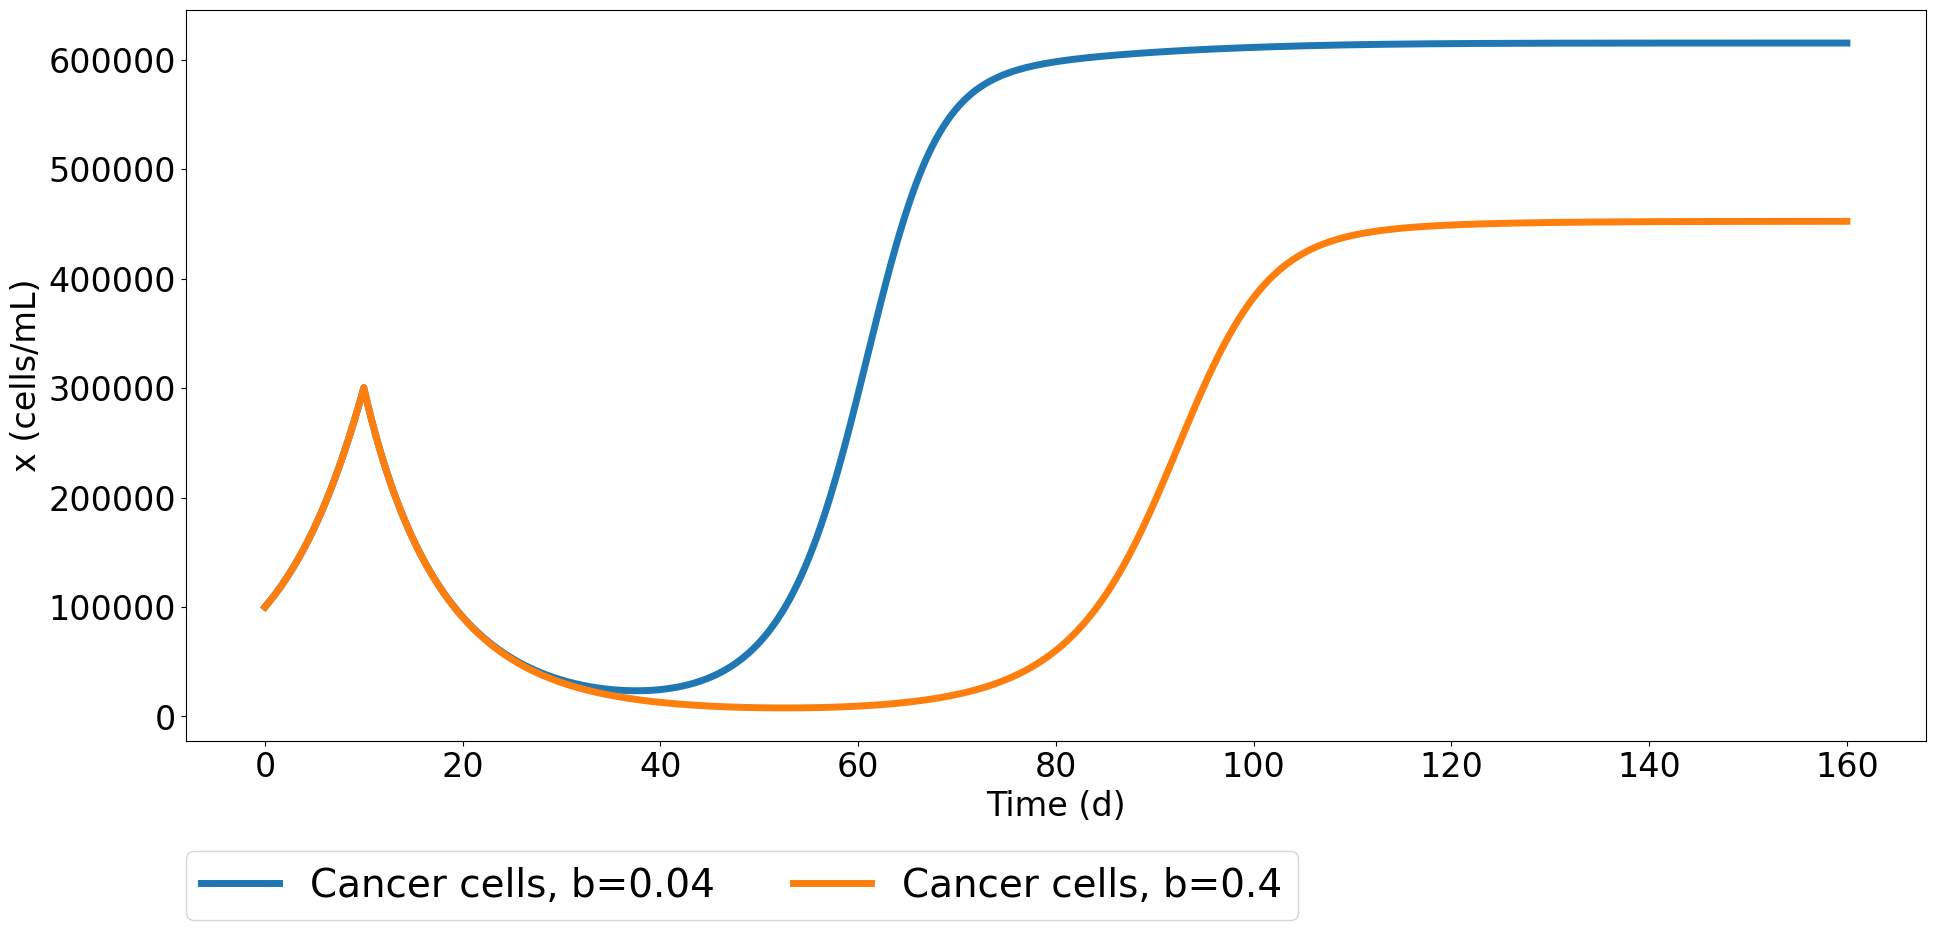

In [58]:
# Defining list of b-values
b_list = [0.04, 0.4]

plt.figure(figsize=(20, 10))
for b in b_list:
  # Setting probability for resistance for the drug (we use quizartinib) to a lower value to let resistance develop quickly
  p = 1e-3

  # Defining new list of parameters for simulation
  parameters_highP = [K, x0, r, n, y0, nImmune_upper, g, c, m, d, s, mu_Q, mu_C, mu_A, mu_V, a, b, b_C, b_A, b_V, p, p_C, p_A, p_V, tau, h]

  # Define treatment phases 
  # Each tuple contains 
  # ('name of drug', duration of drug, death rate of drug, maximal death rate of immune cells due to drug, halflife of drug applied before cell recovery, 
  # first letter of drug, whether or not treatment is currently applied (True if no treatment, False if not))
  treatment_phases = [
      ('Drug', 150, mu_Q, d_max_Q, 0, 'Q', False)
  ]

  t, t_after_treatment, density, immune, sensitive, resistant_A, resistant_V, resistant_Q, resistant_C, t_values = simulate_treatment(treatment_phases, daysBeforeTreatment, parameters_highP, gI)

  plt.plot(t, density, label=f'Cancer cells, b={b}', linewidth=5.0)

plt.rcParams.update({'font.size': 28})
plt.xlabel('Time (d)')
plt.ylabel('x (cells/mL)')
plt.legend(loc='upper left', bbox_to_anchor=(0, -0.15), ncol=4, borderaxespad=0)
plt.tight_layout()
plt.savefig('bVals.pdf', format='pdf', bbox_inches='tight')
plt.show()

### Simulating cytarabine-quizartinib treatment for parameter estimation (Fig. 3.4.2)

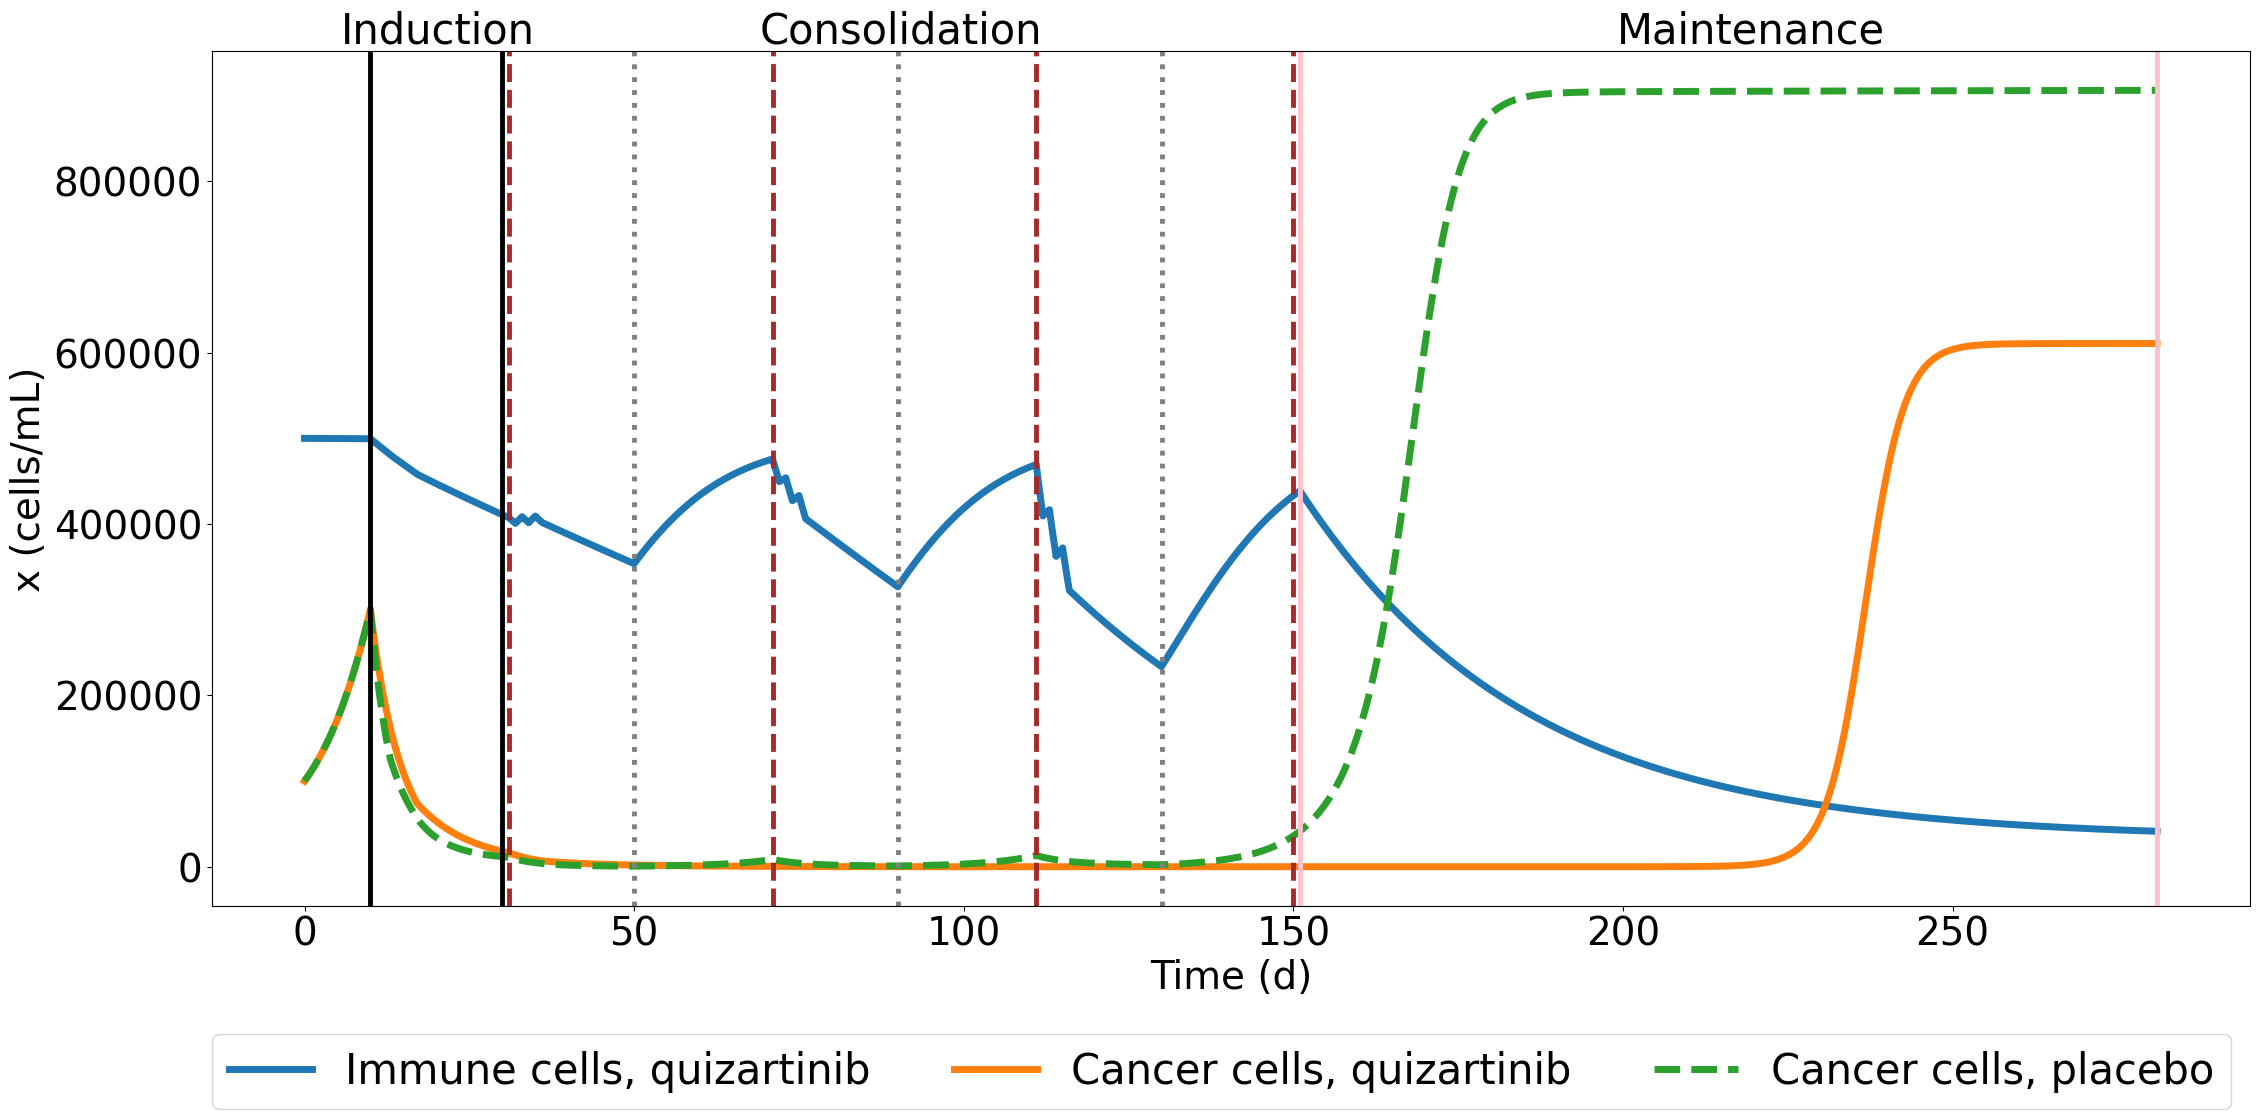

In [59]:
# Define treatment phases for cytarabine-quizartinib treatment
# Each tuple contains 
# ('name of drug', duration of drug, death rate of drug, maximal death rate of immune cells due to drug, halflife of drug applied before cell recovery, 
# first letter of drug, whether or not treatment is currently applied (True if no treatment, False if not))
treatment_phases = [
    #Induction phase
    ('Cytarabine + Anthracycline', 3, mu_CA, d_max_CA, 0, 'C', False),
    ('Cytarabine', 4, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),

    #Consolidation
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 21, mu_Q, d, 42, 'Q', True),

    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 21, mu_Q, d, 42, 'Q', True),

    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 21, mu_Q, d, 42, 'Q', True),

    #Maintenance
    ('Quizartinib', 130, mu_Q, d_max_Q, 0, 'Q', False),
]

# Collect list of populations for cytarabine-quizartinib treatment
t, t_after_treatment, density, immune, sensitive, resistant_A, resistant_V, resistant_Q, resistant_C, t_values = simulate_treatment(treatment_phases, daysBeforeTreatment, parameters, gI)

# Define treatment phases when placebo is given instead of quizartinib
treatment_phases_placebo = [
    #Induction phase
    ('Cytarabine + Anthracycline', 3, mu_CAQ, d_max_CA, 0, 'C', False),
    ('Cytarabine', 4, mu_C, d_max_C, 0, 'C', False),
    ('Placebo', 14, mu_C, d, 14, 'Q', True),

    #Consolidation
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Placebo', 14, mu_C, d, 14, 'C', True),
    ('Cell recovery', 21, mu_no_drug, d, 0, 'none', False),

    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Placebo', 14, mu_C, d, 14, 'C', True),
    ('Cell recovery', 21, mu_no_drug, d, 0, 'none', False),

    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Placebo', 14, mu_C, d, 14, 'C', True),
    ('Cell recovery', 21, mu_no_drug, d, 0, 'none', False),

    #Maintenance
    ('Placebo', 130, mu_no_drug, d, 0, 'none', False),
]

# Collect list of populations for cytarabine-placebo treatment
t_placebo, t_after_treatment_placebo, density_placebo, immune_placebo, sensitive_placebo, resistant_A_placebo, resistant_V_placebo, resistant_Q_placebo, resistant_C_placebo, t_values_placebo = simulate_treatment(treatment_phases_placebo, daysBeforeTreatment, parameters, gI)

# Plot results
plt.figure(figsize=(24.5, 12))
plt.plot(t, immune, label='Immune cells, quizartinib', linewidth=5.0)
plt.plot(t, density, label='Cancer cells, quizartinib', linewidth=5.0)
plt.plot(t_placebo, density_placebo, label='Cancer cells, placebo', linewidth=5.0, linestyle='dashed')

# Plotting headlines for each treatment phase
# Annotate treatment phases 
phase_labels = ['Induction', 'Consolidation', 'Maintenance']
phase_starts = [daysBeforeTreatment - 5.5,
                daysBeforeTreatment + 58,
                daysBeforeTreatment + 188]

# Set y-position slightly above max y-value
y_pos = max(max(density), max(density_placebo), max(immune)) * 1.05

# Add labels just after each phase starts
for label, xpos in zip(phase_labels, phase_starts):
    plt.text(xpos + 1, y_pos, label, ha='left', va='bottom', fontsize=30)

# Plotting lines for the start end end of each treatment phase
plt.axvline(daysBeforeTreatment, color='black', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 20, color='black', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 21, color = 'brown', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 40, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 61, color = 'brown', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 80, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 101, color = 'brown', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 120, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 140, color = 'brown', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 141, color = 'pink', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 271, color = 'pink', linewidth=3.5)

plt.rcParams.update({'font.size': 30})
plt.xlabel('Time (d)')
plt.ylabel('x (cells/mL)')
plt.legend(loc='upper left', bbox_to_anchor=(0, -0.15), ncol=3, borderaxespad=0, fontsize=30)
plt.tight_layout()
plt.savefig('QuFirst_param.pdf', format='pdf', bbox_inches='tight')
plt.show()

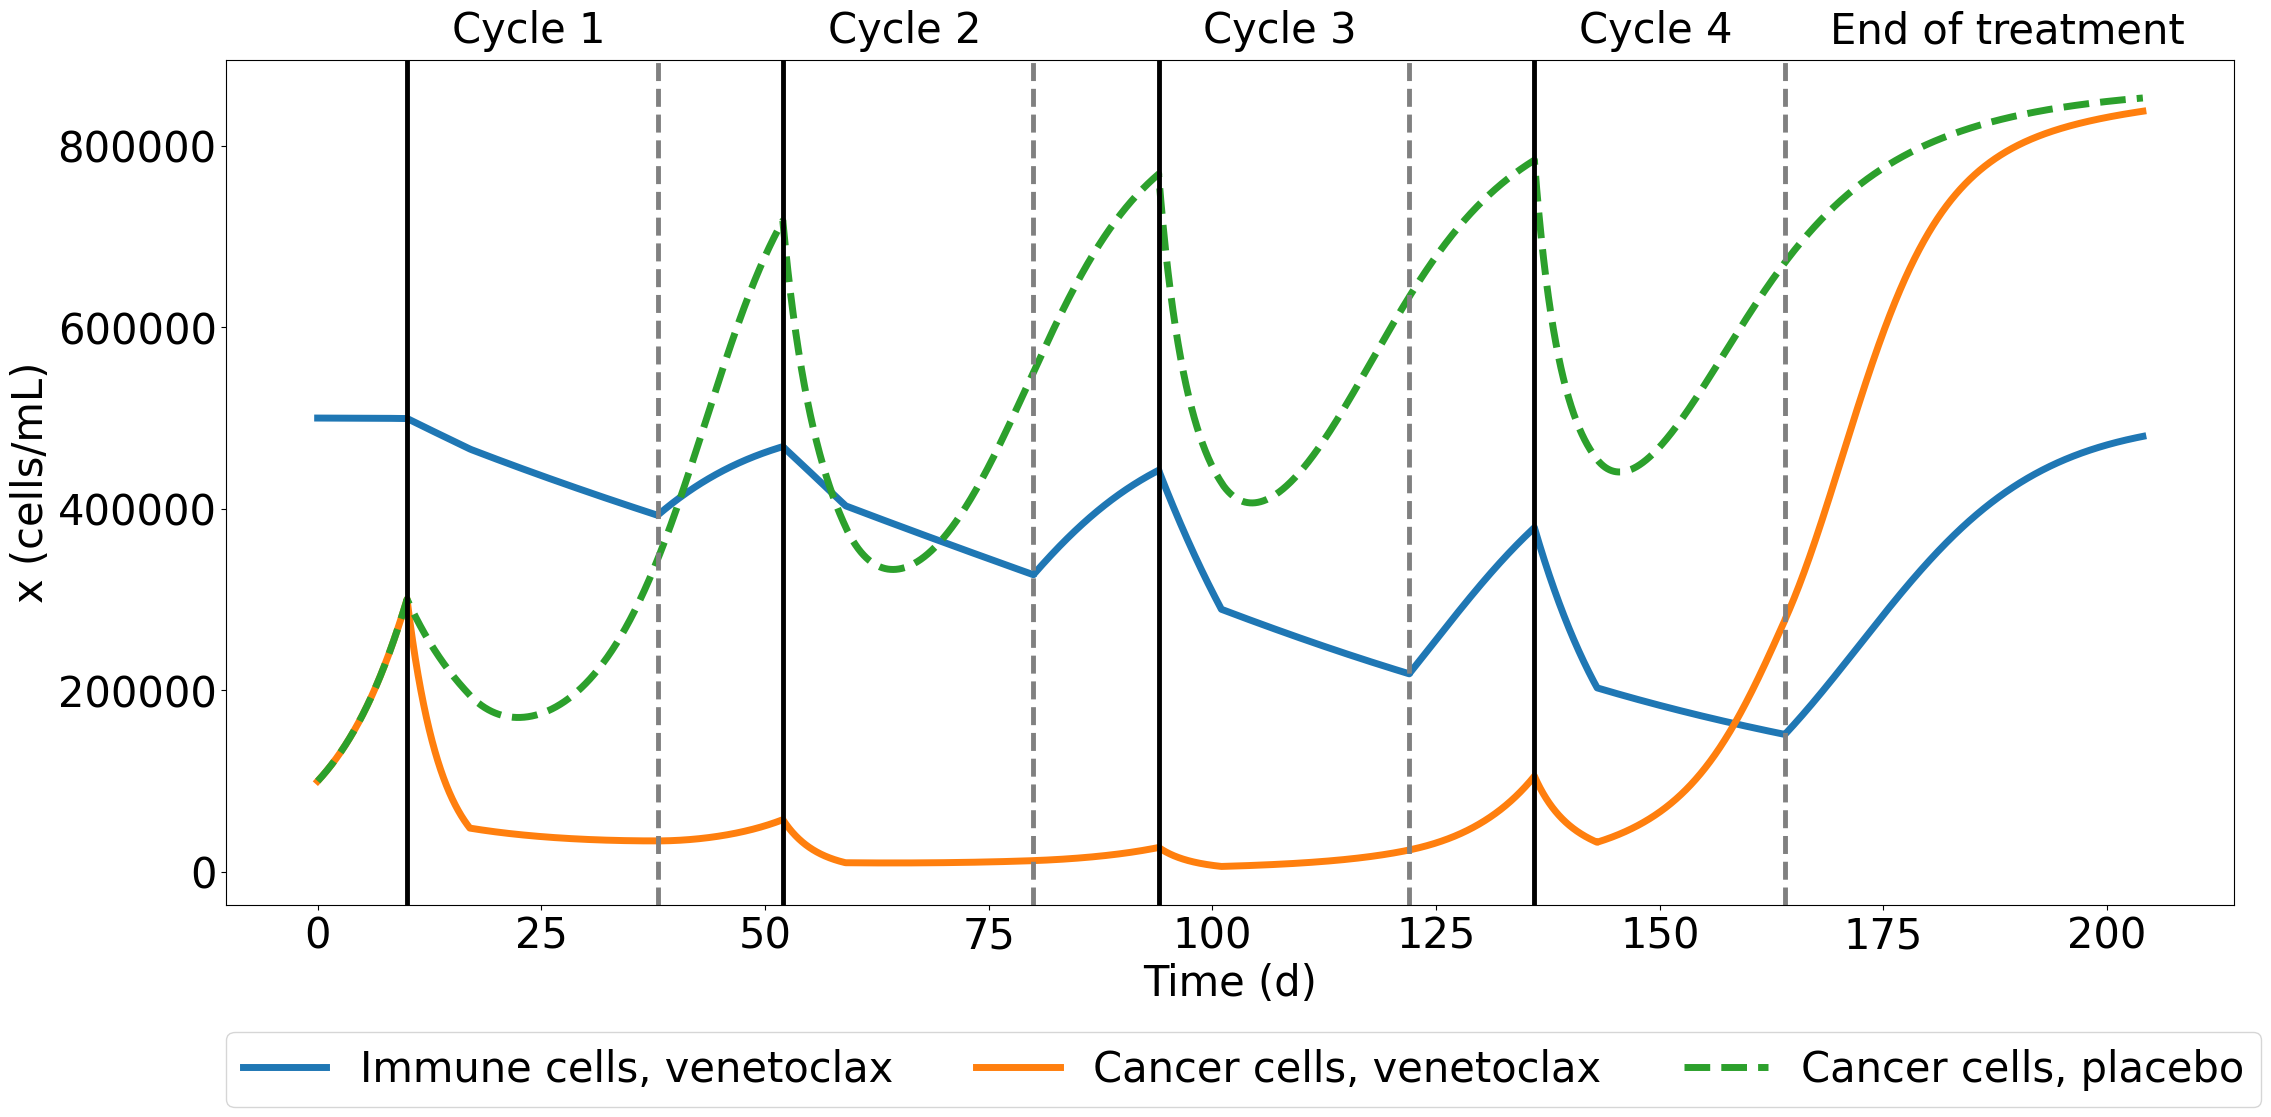

In [60]:
# Define treatment phases for azacitidine-venetoclax treatment
# Each tuple contains 
# ('name of drug', duration of drug, death rate of drug, maximal death rate of immune cells due to drug, halflife of drug applied before cell recovery, 
# first letter of drug, whether or not treatment is currently applied (True if no treatment, False if not))
treatment_phases = [
    ('Azacitidine + Venetoclax', 7, mu_AV, d_max_AV, 0, 'AV', False),
    ('Venetoclax', 21, mu_V, d_max_V, 0, 'V', False),
    ('Cell recovery', 14, mu_V, d, 10, 'V', True),

    ('Azacitidine + Venetoclax', 7, mu_AV, d_max_AV, 0, 'AV', False),
    ('Venetoclax', 21, mu_V, d_max_V, 0, 'V', False),
    ('Cell recovery', 14, mu_V, d, 10, 'V', True),

    ('Azacitidine + Venetoclax', 7, mu_AV, d_max_AV, 0, 'AV', False),
    ('Venetoclax', 21, mu_V, d_max_V, 0, 'V', False),
    ('Cell recovery', 14, mu_V, d, 10, 'V', True),

    ('Azacitidine + Venetoclax', 7, mu_AV, d_max_AV, 0, 'AV', False),
    ('Venetoclax', 21, mu_V, d_max_V, 0, 'V', False),
    ('Cell recovery', 40, mu_V, d, 10, 'V', True),
]

# Collect list of populations for azacitidine-venetoclax treatment
t, t_after_treatment, density, immune, sensitive, resistant_A, resistant_V, resistant_Q, resistant_C, t_values = simulate_treatment(treatment_phases, daysBeforeTreatment, parameters, gI)

# Define treatment phases when placebo is given instead of venetoclax
treatment_phases_placebo = [
    ('Azacitidine', 7, mu_A, d_max_A, 0, 'A', False),
    ('Placebo', 35, mu_A, d, 10, 'A', True),

    ('Azacitidine', 7, mu_A, d_max_A, 0, 'A', False),
    ('Placebo', 35, mu_A, d, 10, 'A', True),

    ('Azacitidine', 7, mu_A, d_max_A, 0, 'A', False),
    ('Placebo', 35, mu_A, d, 10, 'A', True),

    ('Azacitidine', 7, mu_A, d_max_A, 0, 'A', False),
    ('Placebo', 61, mu_A, d, 10, 'A', True),
]

# Collect list of populations for azacitidine-placebo treatment
t_placebo, t_after_treatment_placebo, density_placebo, immune_placebo, sensitive_placebo, resistant_A_placebo, resistant_V_placebo, resistant_Q_placebo, resistant_C_placebo, t_values_placebo = simulate_treatment(treatment_phases_placebo, daysBeforeTreatment, parameters, gI)

# Plot results
plt.figure(figsize=(24.5, 12))
plt.plot(t, immune, label='Immune cells, venetoclax', linewidth=5.0)
plt.plot(t, density, label='Cancer cells, venetoclax', linewidth=5.0)
plt.plot(t_placebo, density_placebo, label='Cancer cells, placebo', linewidth=5.0, linestyle='dashed')

# Plotting headlines for each treatment phase
# Annotate treatment cycles right after each begins
cycle_labels = ['Cycle 1', 'Cycle 2', 'Cycle 3', 'Cycle 4', 'End of treatment']
cycle_starts = [
    daysBeforeTreatment + 4,
    daysBeforeTreatment + 46,
    daysBeforeTreatment + 88,
    daysBeforeTreatment + 130,
    daysBeforeTreatment + 158
]

y_pos = max(max(density), max(density_placebo), max(immune)) * 1.06  # small offset above max y

for label, xpos in zip(cycle_labels, cycle_starts):
    plt.text(xpos + 1, y_pos, label, ha='left', va='bottom', fontsize=30)

# Plotting lines for the start end end of each treatment phase
plt.axvline(daysBeforeTreatment, color = 'black', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 28, color = 'gray', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 42, color = 'black', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 70, color = 'gray', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 84, color = 'black', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 112, color = 'gray', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 126, color = 'black', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 154, color = 'gray', linewidth=3.5, linestyle='dashed')


plt.xlabel('Time (d)')
plt.ylabel('x (cells/mL)')
plt.rcParams.update({'font.size': 30})
plt.legend(loc='upper left', bbox_to_anchor=(0, -0.15), ncol=3, borderaxespad=0, fontsize=30)
plt.tight_layout()
plt.savefig('AzacitidineVenetoclax_param.pdf', format='pdf', bbox_inches='tight')
plt.show()

### Validation of combining Tumour-Immune interactions and treatment toxicity (Fig 4.1.1)

In this simulation we do not look at resisatance or turning treatment on and off. dynamics_combination() and simulating_treatment() is therefore not used here.

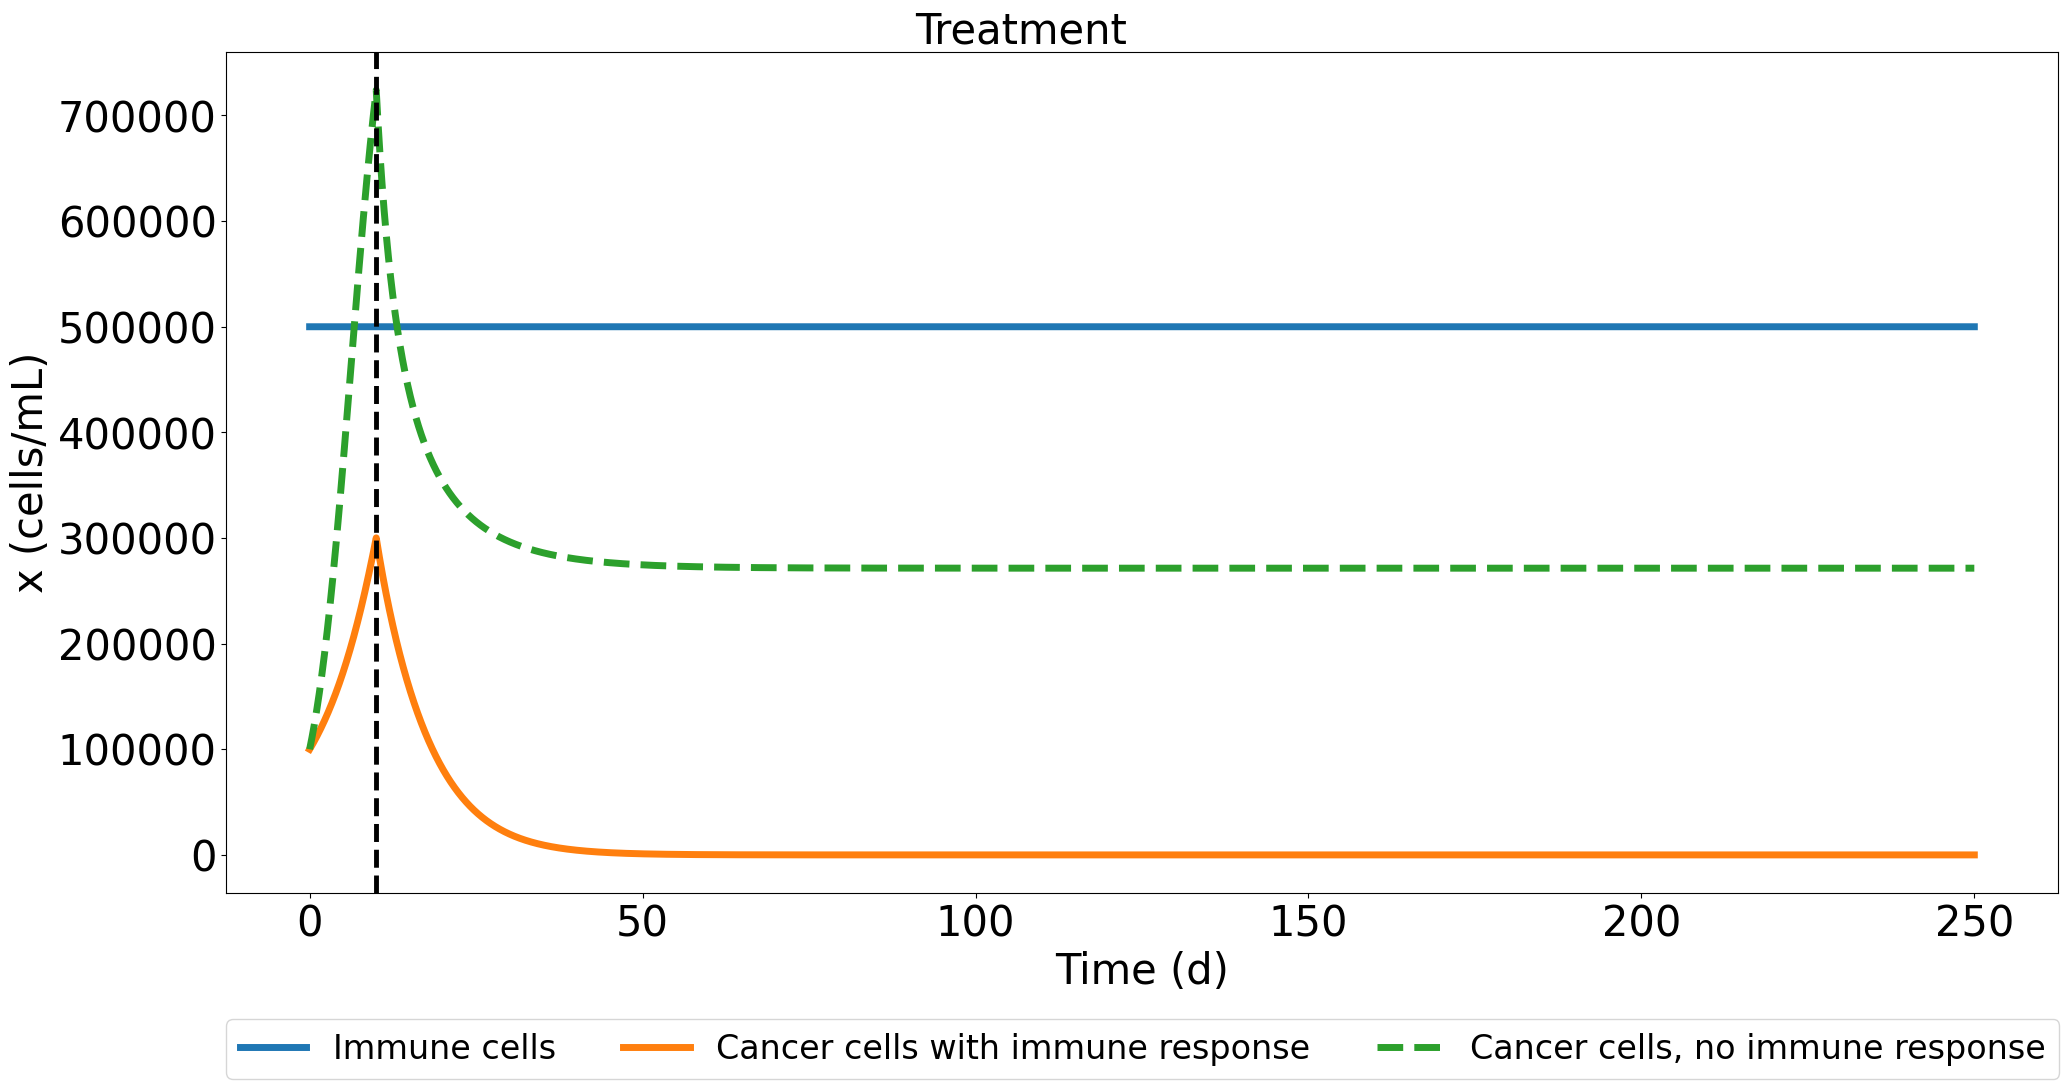

In [61]:
# Defining arrays of number of days before treatment and for treatment
totalDays = 250
t_no_treatment = np.arange(0, daysBeforeTreatment + dt, dt)
t_treatment = np.arange(daysBeforeTreatment, totalDays + dt, dt)

# Finding population density before treatment is applied when there is no immune response
popDensity_noImmune_no_treatment = odeint(growthRate, x0, t_no_treatment, args=(K, mu_no_drug, r)) 

# Finding population density before treatment is applied when there is an immune response
popDensity_immune_x_no_treatment = odeint(growthRate_immune_toxicity, [x0,y0], t_no_treatment, args =(K, r, mu_no_drug, h, tau, n, 0, 0, 0, 0, 0, 0))[:,0]
popDensity_immune_y_no_treatment = odeint(growthRate_immune_toxicity, [x0,y0], t_no_treatment, args =(K, r, mu_no_drug, h, tau, n, 0, 0, 0, 0, 0, 0))[:,1]

# Finding population density after the period without treatment 
x0_after = popDensity_immune_x_no_treatment[-1]
y0_after = popDensity_immune_y_no_treatment[-1]
x0_noimmune = popDensity_noImmune_no_treatment[-1]

# Finding population density when treatment is applied when there is no immune response
popDensity_noImmune = odeint(growthRate, x0_noimmune, t_treatment, args=(K, mu_Q, r))

# Finding population density when treatment is applied when there is an immune response
popDensity_immune_x = odeint(growthRate_immune_toxicity, [x0_after, y0_after], t_treatment, args =(K, r, mu_Q, h, tau, n, 0, 0, 0, 0, 0, 0))[:,0]
popDensity_immune_y = odeint(growthRate_immune_toxicity, [x0_after, y0_after], t_treatment, args =(K, r, mu_Q, h, tau, n, 0, 0, 0, 0, 0, 0))[:,1]

# Concatenating the lists
t = np.concatenate((t_no_treatment, t_treatment))
popDensity_immune_x = np.concatenate((popDensity_immune_x_no_treatment, popDensity_immune_x))
popDensity_immune_y = np.concatenate((popDensity_immune_y_no_treatment, popDensity_immune_y))
popDensity_noImmune = np.concatenate((popDensity_noImmune_no_treatment, popDensity_noImmune))

# Plotting the results
plt.figure(figsize=(22, 11))
plt.plot(t, popDensity_immune_y, label = f'Immune cells', linewidth=5.0)
plt.plot(t, popDensity_immune_x, label = f'Cancer cells with immune response', linewidth=5.0)
plt.plot(t, popDensity_noImmune, label = f'Cancer cells, no immune response', linewidth=5.0, linestyle = 'dashed')
plt.rcParams.update({'font.size': 24})
plt.legend(loc='upper left', bbox_to_anchor=(0, -0.15), ncol=4, borderaxespad=0, fontsize=24)
plt.tight_layout()
plt.xlabel('Time (d)')
plt.ylabel('x (cells/mL)')

# Plotting headlines for each treatment phase
# Annotate treatment phases 
phase_labels = ['Treatment']
phase_starts = [daysBeforeTreatment + 80]

# Set y-position slightly above max y-value
y_pos = max(max(popDensity_immune_x), max(popDensity_noImmune_no_treatment), max(popDensity_immune_x_no_treatment)) * 1.05

# Add labels just after each phase starts
for label, xpos in zip(phase_labels, phase_starts):
    plt.text(xpos + 1, y_pos, label, ha='left', va='bottom', fontsize=30)

# Plotting line for the start of a treatment phase
plt.axvline(daysBeforeTreatment, color='black', linestyle='dashed', linewidth=3.5)

plt.savefig('NoTreatment_ITT.pdf', format='pdf', bbox_inches='tight')
plt.show()

### Validating toxicity (Fig 4.1.2)

In these simulations we do not look at resistance or turning treatment on and off. dynamics_combination() and simulating_treatment() is therefore not used here.

#### Fig 4.1.2a

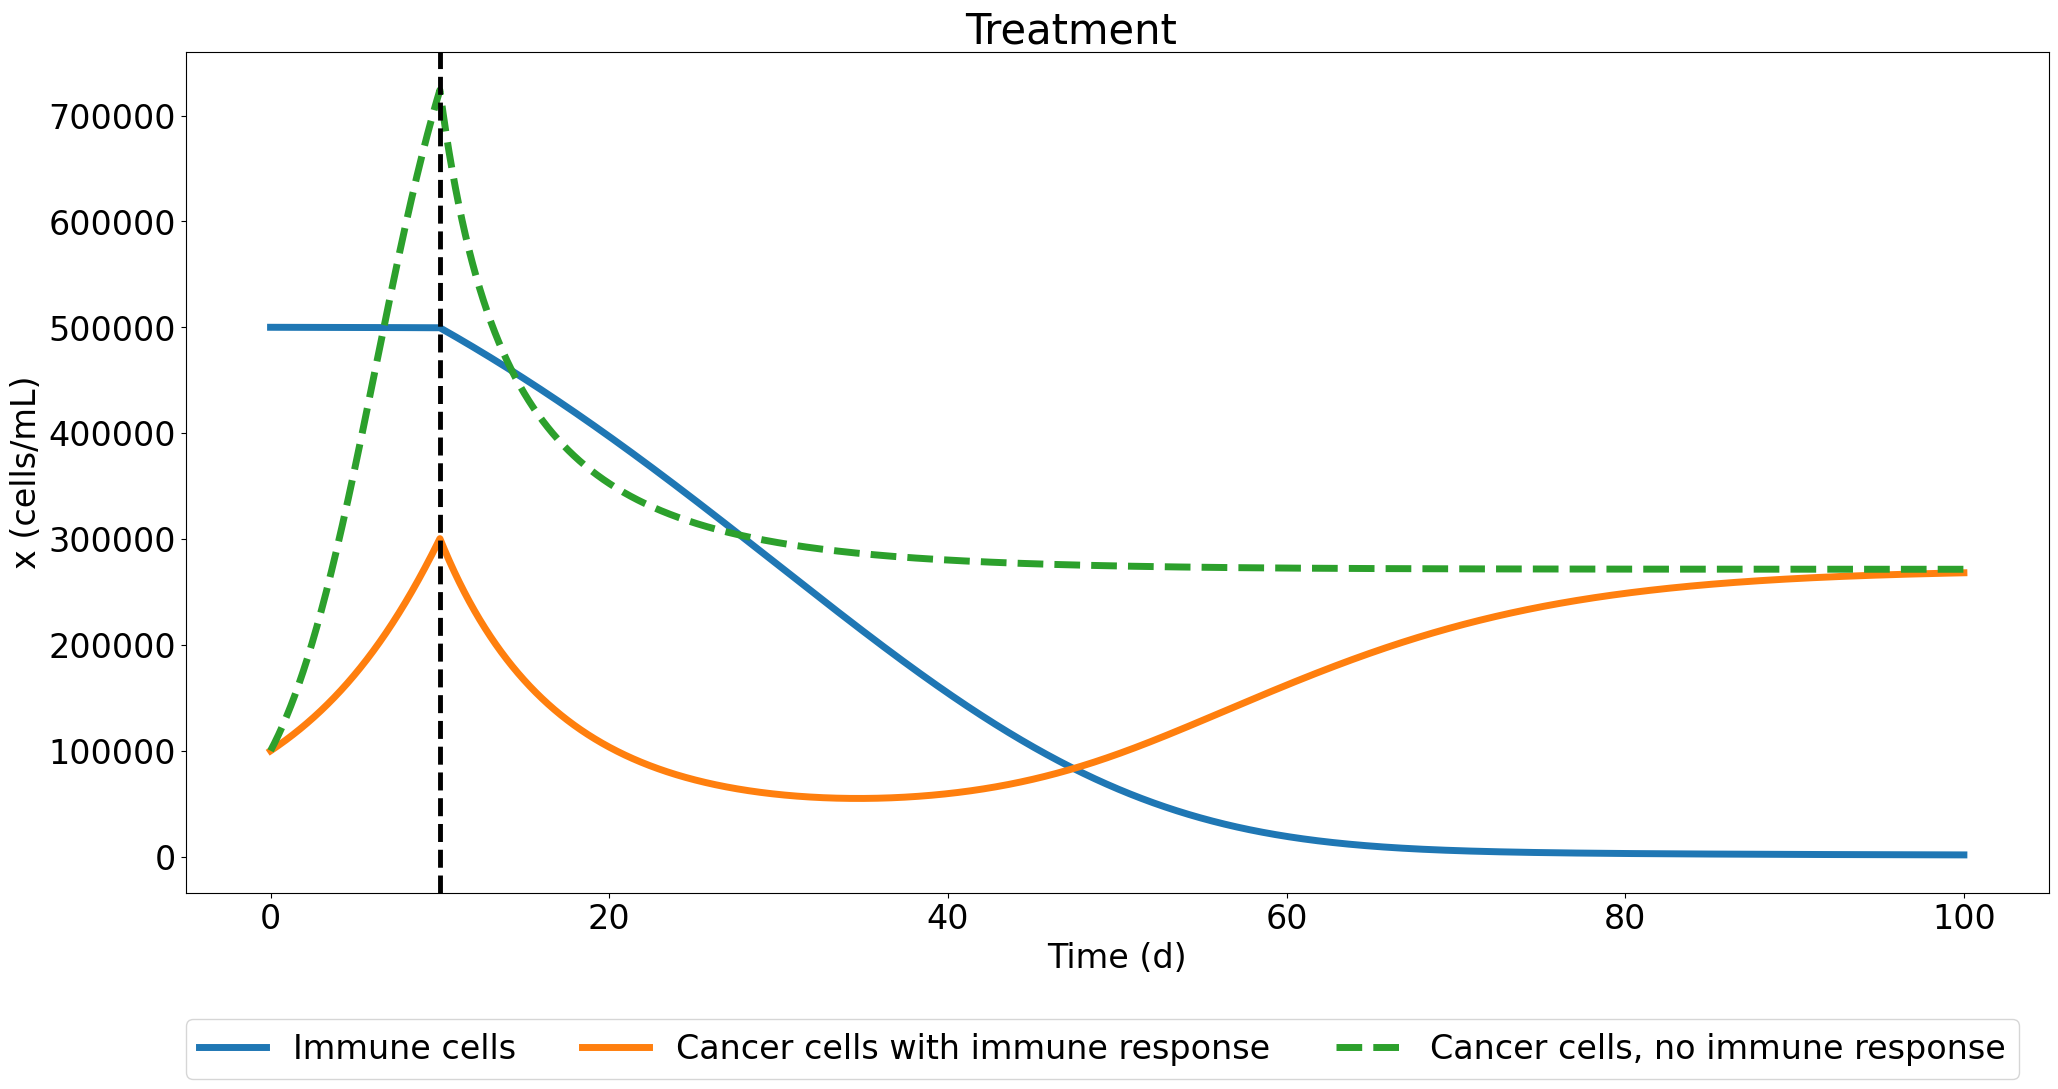

In [62]:
# Defining arrays of number of days before treatment and for treatment
totalDays = 100
t_no_treatment = np.arange(0, daysBeforeTreatment + dt, dt)
t_treatment = np.arange(daysBeforeTreatment, totalDays+dt, dt)

#Setting value for d_max for this test
d_max_1 = 1

# Finding population density before treatment is applied when there is no immune response
popDensity_noImmune_no_treatment = odeint(growthRate, x0, t_no_treatment, args=(K, mu_no_drug, r)) #solving the equation

# Finding population density before treatment is applied when there is an immune response
popDensity_immune_x_no_treatment = odeint(growthRate_immune_toxicity, [x0,y0], t_no_treatment, args =(K, r, mu_no_drug, h, tau, n, c, g, m, d, d, s))[:,0]
popDensity_immune_y_no_treatment = odeint(growthRate_immune_toxicity, [x0,y0], t_no_treatment, args =(K, r, mu_no_drug, h, tau, n, c, g, m, d, d, s))[:,1]

# Finding population density after the period without treatment 
x0_after = popDensity_immune_x_no_treatment[-1]
y0_after = popDensity_immune_y_no_treatment[-1]
x0_noimmune = popDensity_noImmune_no_treatment[-1]

# Finding population density when treatment is applied when there is no immune response
popDensity_noImmune = odeint(growthRate, x0_noimmune, t_treatment, args=(K, mu_Q, r))

# Finding population density when treatment is applied when there is an immune response
popDensity_immune_x = odeint(growthRate_immune_toxicity, [x0_after, y0_after], t_treatment, args =(K, r, mu_Q, h, tau, n, c, g, m, d, d_max_1, s))[:,0]
popDensity_immune_y = odeint(growthRate_immune_toxicity, [x0_after, y0_after], t_treatment, args =(K, r, mu_Q, h, tau, n, c, g, m, d, d_max_1, s))[:,1]

# Concatenating the lists
t = np.concatenate((t_no_treatment, t_treatment))
popDensity_immune_x = np.concatenate((popDensity_immune_x_no_treatment, popDensity_immune_x))
popDensity_immune_y = np.concatenate((popDensity_immune_y_no_treatment, popDensity_immune_y))
popDensity_noImmune = np.concatenate((popDensity_noImmune_no_treatment, popDensity_noImmune))

# Plotting the results
plt.figure(figsize=(22, 11))
plt.plot(t, popDensity_immune_y, label = f'Immune cells', linewidth=5.0)
plt.plot(t, popDensity_immune_x, label = f'Cancer cells with immune response', linewidth=5.0)
plt.plot(t, popDensity_noImmune, label = f'Cancer cells, no immune response', linewidth=5.0, linestyle='dashed')
plt.rcParams.update({'font.size': 24})
plt.legend(loc='upper left', bbox_to_anchor=(0, -0.15), ncol=4, borderaxespad=0, fontsize=24)
plt.tight_layout()
plt.xlabel('Time (d)')
plt.ylabel('x (cells/mL)')

# Plotting headlines for each treatment phase
# Annotate treatment phases 
phase_labels = ['Treatment']
phase_starts = [daysBeforeTreatment + 30]

# Set y-position slightly above max y-value
y_pos = max(max(popDensity_immune_x), max(popDensity_noImmune_no_treatment), max(popDensity_immune_x_no_treatment)) * 1.05

# Add labels just after each phase starts
for label, xpos in zip(phase_labels, phase_starts):
    plt.text(xpos + 1, y_pos, label, ha='left', va='bottom', fontsize=30)

# Plotting line for the start of a treatment phase
plt.axvline(daysBeforeTreatment, color='black', linestyle='dashed', linewidth=3.5)

plt.savefig('Toxicity_ITT_1.pdf', format='pdf', bbox_inches='tight')
plt.show()

#### Fig 4.1.2 b

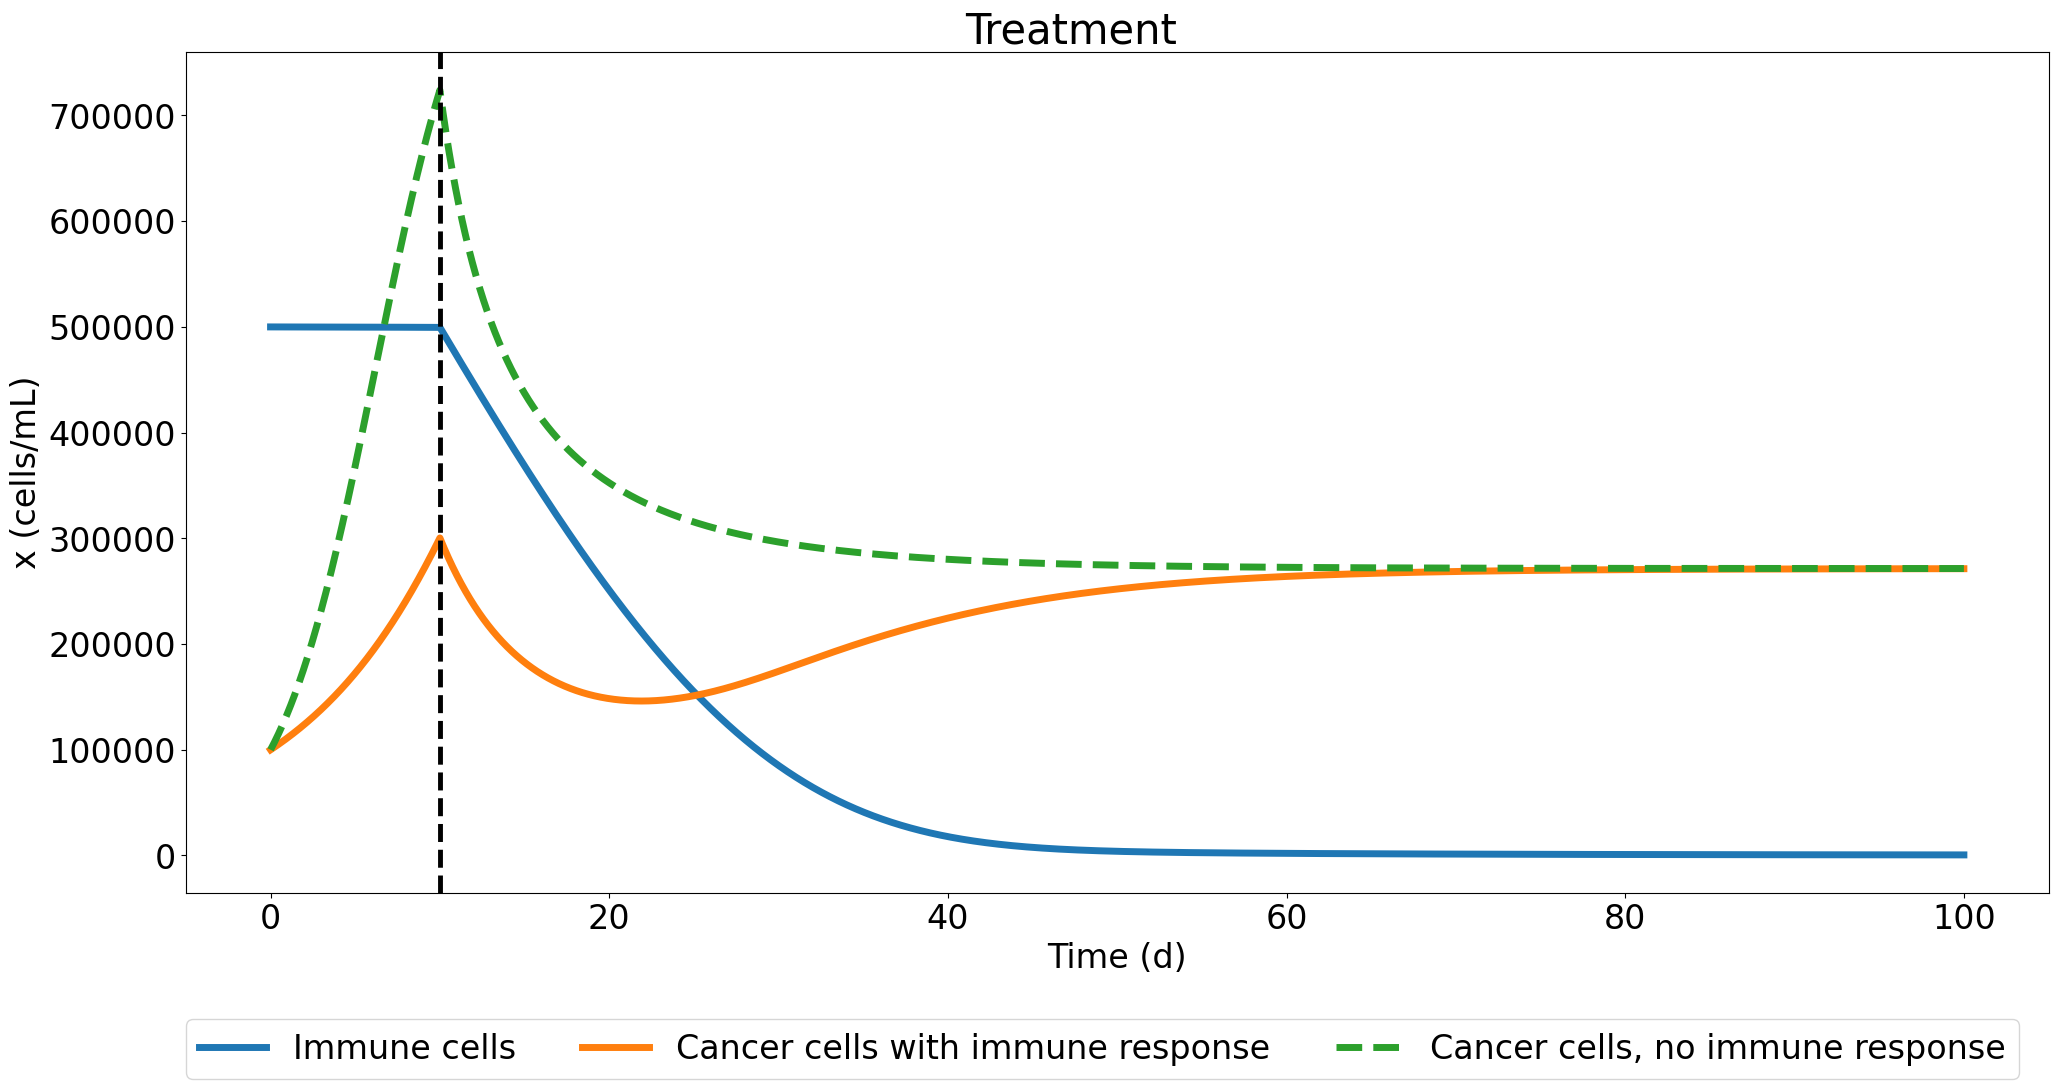

In [63]:
# Defining arrays of number of days before treatment and for treatment
totalDays = 100
t_no_treatment = np.arange(0, daysBeforeTreatment + dt, dt)
t_treatment = np.arange(daysBeforeTreatment, totalDays+dt, dt)

#Setting value for d_max for this test
d_max_1 = 3

# Finding population density before treatment is applied when there is no immune response
popDensity_noImmune_no_treatment = odeint(growthRate, x0, t_no_treatment, args=(K, mu_no_drug, r)) 

# Finding population density before treatment is applied when there is an immune response
popDensity_immune_x_no_treatment = odeint(growthRate_immune_toxicity, [x0,y0], t_no_treatment, args =(K, r, mu_no_drug, h, tau, n, c, g, m, d, d, s))[:,0]
popDensity_immune_y_no_treatment = odeint(growthRate_immune_toxicity, [x0,y0], t_no_treatment, args =(K, r, mu_no_drug, h, tau, n, c, g, m, d, d, s))[:,1]

# Finding population density after the period without treatment 
x0_after = popDensity_immune_x_no_treatment[-1]
y0_after = popDensity_immune_y_no_treatment[-1]
x0_noimmune = popDensity_noImmune_no_treatment[-1]

# Finding population density when treatment is applied when there is no immune response
popDensity_noImmune = odeint(growthRate, x0_noimmune, t_treatment, args=(K, mu_Q, r))

# Finding population density when treatment is applied when there is an immune response
popDensity_immune_x = odeint(growthRate_immune_toxicity, [x0_after, y0_after], t_treatment, args =(K, r, mu_Q, h, tau, n, c, g, m, d, d_max_1, s))[:,0]
popDensity_immune_y = odeint(growthRate_immune_toxicity, [x0_after, y0_after], t_treatment, args =(K, r, mu_Q, h, tau, n, c, g, m, d, d_max_1, s))[:,1]

# Concatenating the lists
t = np.concatenate((t_no_treatment, t_treatment))
popDensity_immune_x = np.concatenate((popDensity_immune_x_no_treatment, popDensity_immune_x))
popDensity_immune_y = np.concatenate((popDensity_immune_y_no_treatment, popDensity_immune_y))
popDensity_noImmune = np.concatenate((popDensity_noImmune_no_treatment, popDensity_noImmune))

# Plotting the results
plt.figure(figsize=(22, 11))
plt.plot(t, popDensity_immune_y, label = f'Immune cells', linewidth=5.0)
plt.plot(t, popDensity_immune_x, label = f'Cancer cells with immune response', linewidth=5.0)
plt.plot(t, popDensity_noImmune, label = f'Cancer cells, no immune response', linewidth=5.0, linestyle='dashed')
plt.rcParams.update({'font.size': 24})
plt.legend(loc='upper left', bbox_to_anchor=(0, -0.15), ncol=4, borderaxespad=0, fontsize=24)
plt.tight_layout()
plt.xlabel('Time (d)')
plt.ylabel('x (cells/mL)')

# Plotting headlines for each treatment phase
# Annotate treatment phases 
phase_labels = ['Treatment']
phase_starts = [daysBeforeTreatment + 30]

# Set y-position slightly above max y-value
y_pos = max(max(popDensity_immune_x), max(popDensity_noImmune_no_treatment), max(popDensity_immune_x_no_treatment)) * 1.05

# Add labels just after each phase starts
for label, xpos in zip(phase_labels, phase_starts):
    plt.text(xpos + 1, y_pos, label, ha='left', va='bottom', fontsize=30)

# Plotting line for the start of a treatment phase
plt.axvline(daysBeforeTreatment, color='black', linestyle='dashed', linewidth=3.5)

plt.savefig('Toxicity_ITT_2.pdf', format='pdf', bbox_inches='tight')
plt.show()

### Validating incorporation of resistance (Fig 4.1.3)

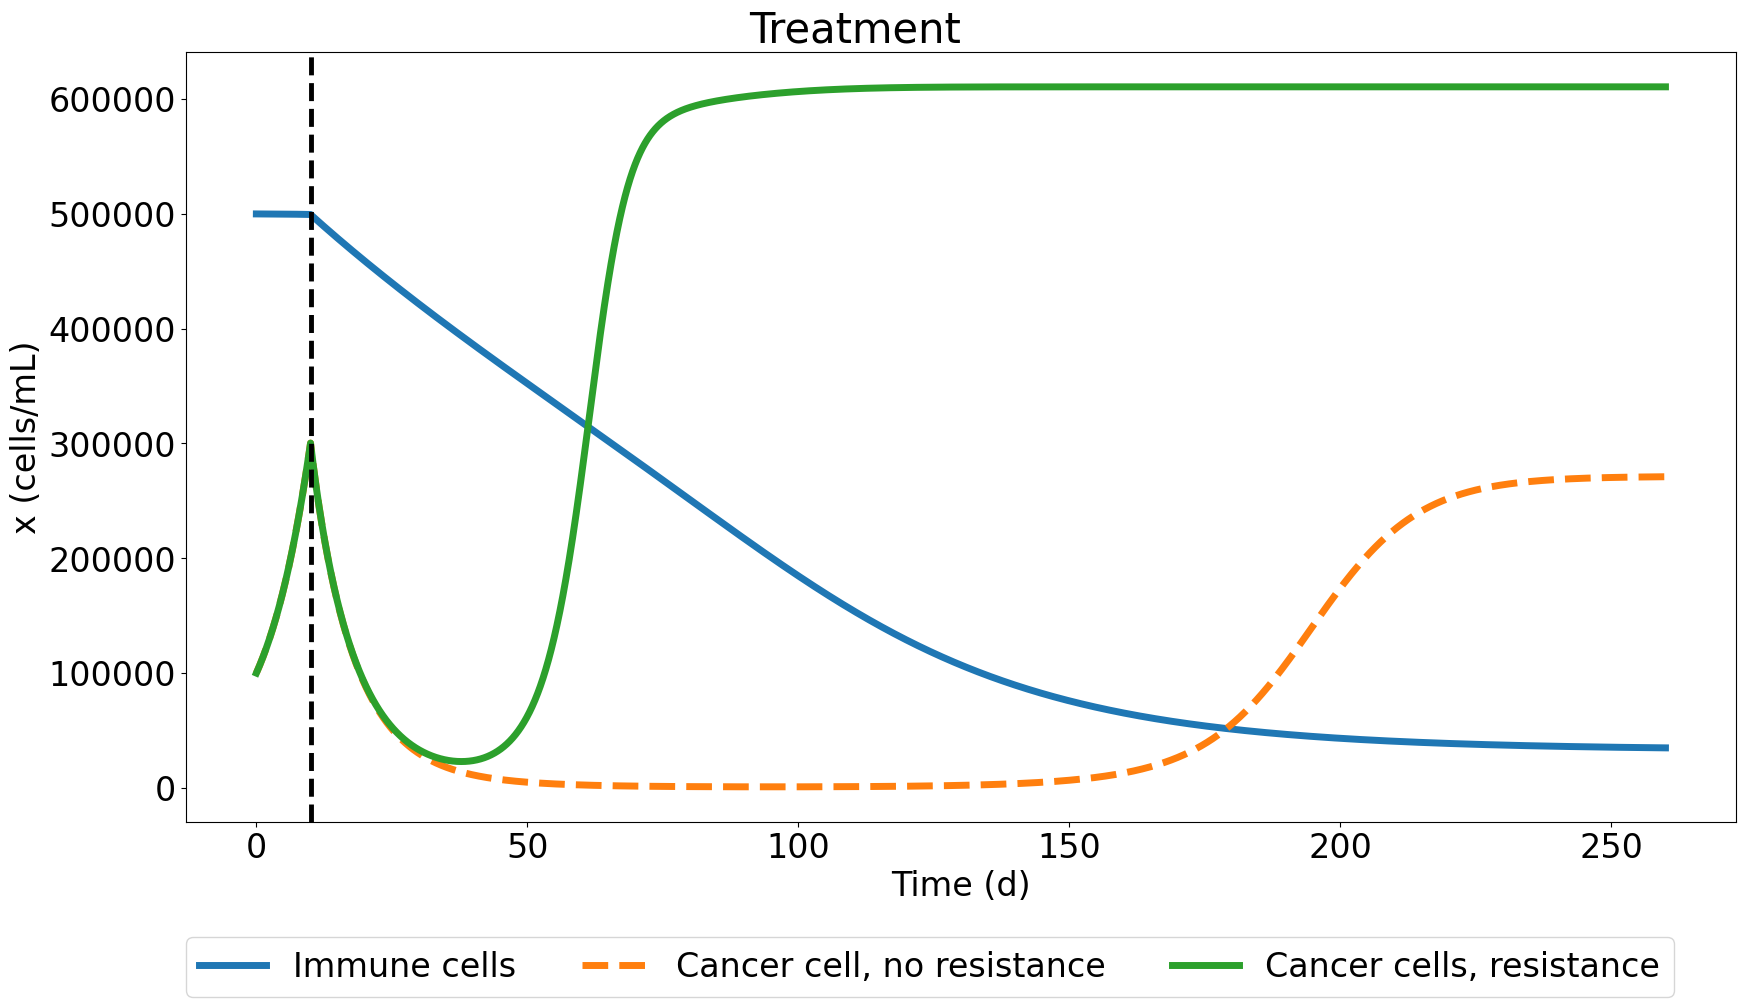

In [64]:
# Setting probability for resistance for the drug (we use quizartinib) to a lower value to let resistance develop quickly
p = 1e-3

# Defining new list of parameters with a higher value for p for simulation 
parameters_highP = [K, x0, r, n, y0, nImmune_upper, g, c, m, d, s, mu_Q, mu_C, mu_A, mu_V, a, b_Q, b_C, b_A, b_V, p, p_C, p_A, p_V, tau, h]
# Defining new list of parameters without resistance
parameters_noRes = [K, x0, r, n, y0, nImmune_upper, g, c, m, d, s, mu_Q, mu_C, mu_A, mu_V, a, 0, b_C, b_A, b_V, 0, p_C, p_A, p_V, tau, h]

# Define treatment phases 
# Each tuple contains 
# ('name of drug', duration of drug, death rate of drug, maximal death rate of immune cells due to drug, halflife of drug applied before cell recovery, 
# first letter of drug, whether or not treatment is currently applied (True if no treatment, False if not))
treatment_phases = [
    ('Drug', 250, mu_Q, d_max_Q, 0, 'Q', False)
]

# Collect list of populations for azacitidine-placebo treatment
t, t_after_treatment, density, immune, sensitive, resistant_A, resistant_V, resistant_Q, resistant_C, t_values = simulate_treatment(treatment_phases, daysBeforeTreatment, parameters_highP, gI)
t_noRes, t_after_treatment, density_noRes, immune, sensitive, resistant_A, resistant_V, resistant_Q, resistant_C, t_values = simulate_treatment(treatment_phases, daysBeforeTreatment, parameters_noRes, gI)

# Plotting the results
plt.figure(figsize=(20, 10))
plt.plot(t, immune, label = f'Immune cells', linewidth=5.0)
plt.plot(t, density_noRes, label = f'Cancer cell, no resistance', linewidth=5.0, linestyle='dashed')
plt.plot(t, density, label = f'Cancer cells, resistance', linewidth=5.0)
plt.xlabel('Time (d)')
plt.ylabel('x (cells/mL)')
plt.rcParams.update({'font.size': 24})
plt.legend(loc='upper left', bbox_to_anchor=(0, -0.15), ncol=3, borderaxespad=0, fontsize=24)

# Plotting headlines for each treatment phase
# Annotate treatment phases 
phase_labels = ['Treatment']
phase_starts = [daysBeforeTreatment + 80]

# Set y-position slightly above max y-value
y_pos = max(max(density), max(density_noRes), max(immune)) * 1.05

# Add labels just after each phase starts
for label, xpos in zip(phase_labels, phase_starts):
    plt.text(xpos + 1, y_pos, label, ha='left', va='bottom', fontsize=30)


# Plotting line for the start of a treatment phase
plt.axvline(daysBeforeTreatment, color='black', linestyle='dashed', linewidth=3.5)


plt.savefig('RITT.pdf', format='pdf', bbox_inches='tight')
plt.show()

### Validating implementation of treatment dynamics (Fig 4.1.4)

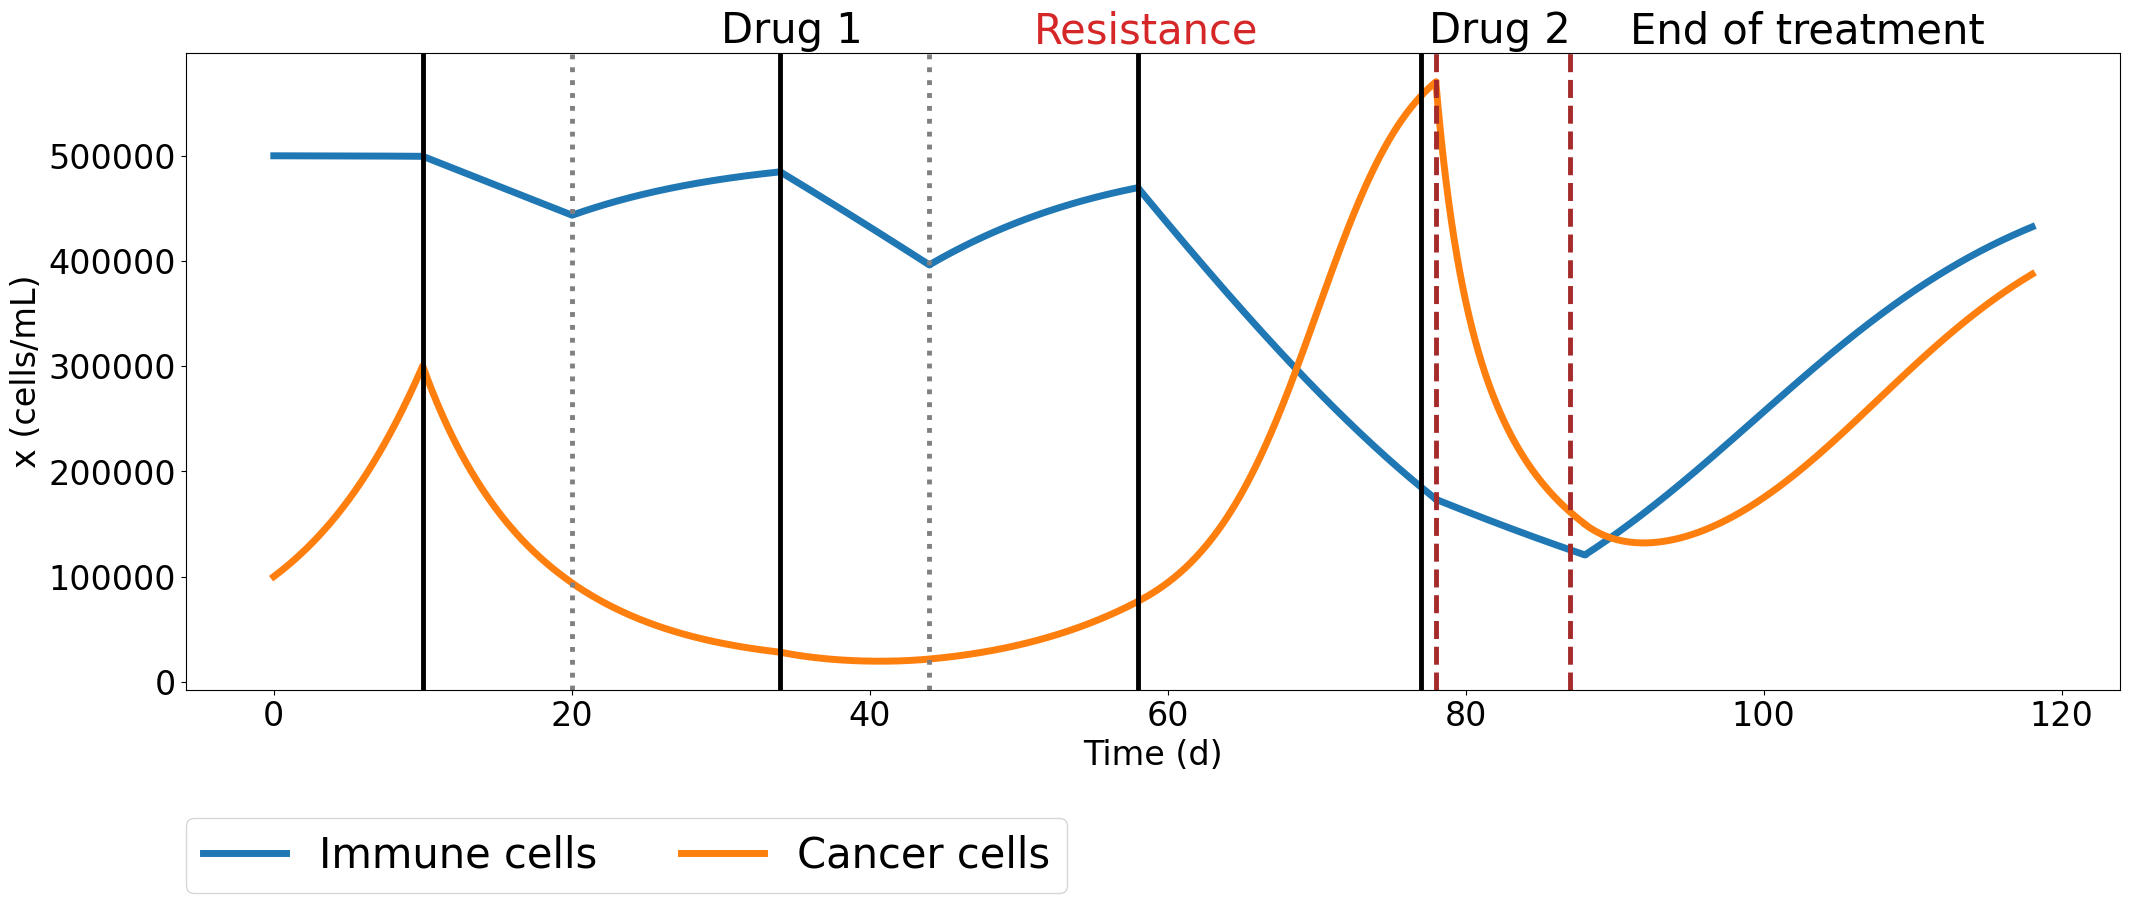

In [65]:
# Define treatment phases 
# Each tuple contains 
# ('name of drug', duration of drug, death rate of drug, maximal death rate of immune cells due to drug, halflife of drug applied before cell recovery, 
# first letter of drug, whether or not treatment is currently applied (True if no treatment, False if not))
treatment_phases = [
    #Induction phase
    ('Quizartinib', 10, mu_Q, d_max_C, 0, 'Q', False),
    ('Cell recovery', 14, mu_Q, d, 42, 'Q', True),
    ('Quizartinib', 10, mu_Q, d_max_C, 0, 'Q', False),
    ('Cell recovery', 14, mu_Q, d, 42, 'Q', True),

    #Maintenance
    ('Quizartinib Maintenance', 20, mu_Q, d_max_C, 0, 'Q', False),
    ('Cytarabine', 10, mu_C, d_max_A, 0, 'C', False),
    ('Cell recovery', 30, mu_C, d, 10, 'C', True),
]

# Collect list of populations for azacitidine-placebo treatment, use the same value for high probability as above
t, t_after_treatment, density, immune, sensitive, resistant_A, resistant_V, resistant_Q, resistant_C, t_values = simulate_treatment(treatment_phases, daysBeforeTreatment, parameters_highP, gI)

# Plot results
plt.figure(figsize=(22, 10))
plt.plot(t, immune, label='Immune cells', linewidth=5.0)
plt.plot(t, density, label='Cancer cells', linewidth=5.0)

# Plotting headlines for each treatment phase
# Annotate treatment phases 
phase_labels = ['Drug 1',  'Drug 2', 'End of treatment']
phase_starts = [daysBeforeTreatment + 19,
                daysBeforeTreatment + 66.5,
                daysBeforeTreatment + 80]

# Marking the spot around where resistance develops
res_label = ['Resistance']
res_pos = [daysBeforeTreatment + 40]

# Set y-position slightly above max y-value
y_pos = max(max(density), max(immune)) * 1.05

# Add labels just after each phase starts
for label, xpos in zip(phase_labels, phase_starts):
    plt.text(xpos + 1, y_pos, label, ha='left', va='bottom', fontsize=30)

for label, xpos in zip(res_label, res_pos):
    plt.text(xpos + 1, y_pos, label, ha='left', va='bottom', fontsize=30, color='tab:red')


# Plotting line for the start and end of a treatment phase
plt.axvline(daysBeforeTreatment, color='black', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 10, color='gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 24, color='black', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 34, color='gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 48, color='black', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 67, color='black', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 68, color='brown', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 77, color='brown', linewidth=3.5, linestyle='dashed')

plt.xlabel('Time (d)')
plt.ylabel('x (cells/mL)')
plt.rcParams.update({'font.size': 30})
plt.legend(loc='upper left', bbox_to_anchor=(0, -0.2), ncol=2, borderaxespad=0, fontsize=30)
plt.tight_layout()
plt.savefig('ValidationTreatment.pdf', format='pdf', bbox_inches='tight')
plt.show()

### Impact of immune cells on cancer growth in the absence of treatment

Simulating the impact of cancer cells in the absence of treatment. We start by looking when the inital population of cancer cells is very high or very low. In this simulation we do not look at resistance or turning treatment on and off. dynamics_combination() and simulating_treatment() is therefore not used here.

#### Impact of immune cells, low initial population density (Fig 4.2.1a)

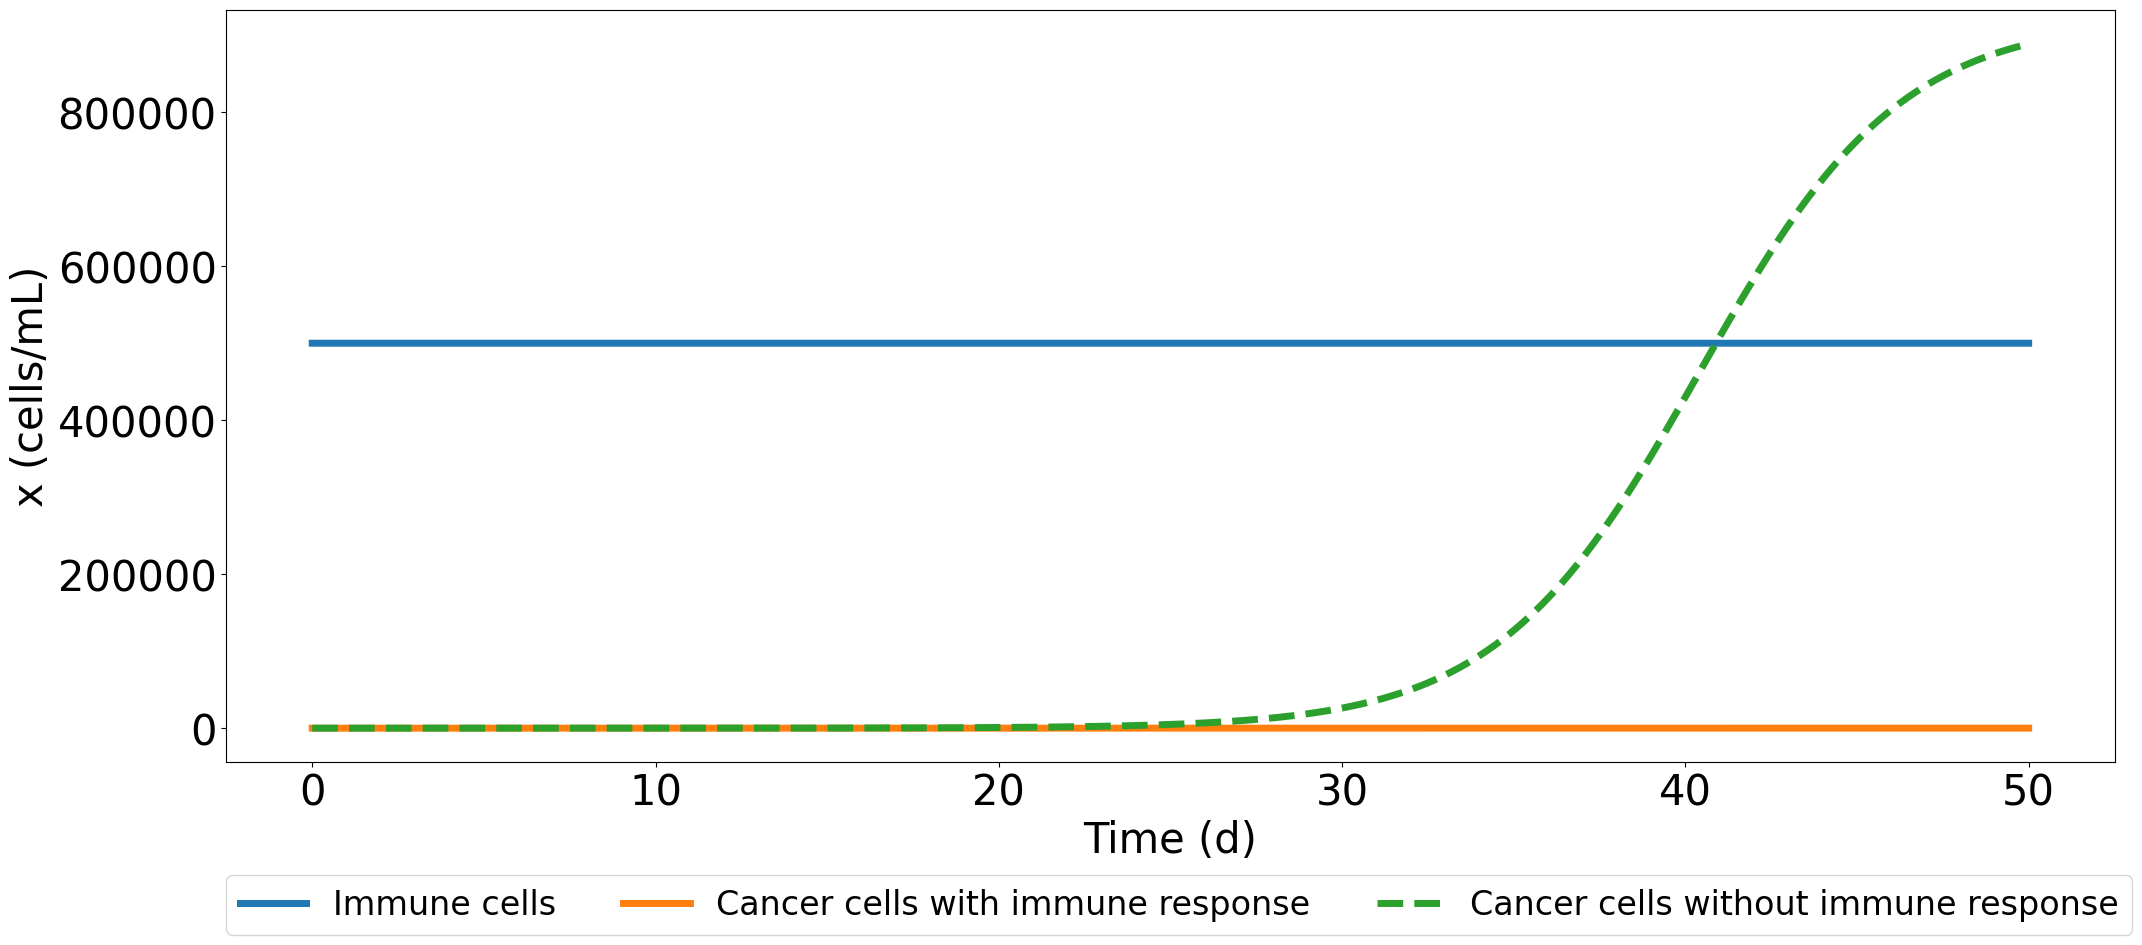

In [66]:
# Setting the initial population density of cancer cells equal to 1
x0_test = 1
# Create an array containing the number of days we run the simulation for
t_show_no_treatment = np.arange(0, 50 + dt, dt)

# Finding population density before when there is an immune response
popDensity_immune_x_no_treatment = odeint(growthRate_immune_toxicity, [x0_test, y0], t_show_no_treatment, args =(K, r, mu_no_drug, h, tau, n, c, g, m, d, d, s))[:,0]
popDensity_immune_y_no_treatment = odeint(growthRate_immune_toxicity, [x0_test, y0], t_show_no_treatment, args =(K, r, mu_no_drug, h, tau, n, c, g, m, d, d, s))[:,1]

# Finding population density before when there is no immune response
popDensity_x_no_treatment = odeint(growthRate, x0_test, t_show_no_treatment, args=(K, mu_no_drug, r))


plt.figure(figsize=(23, 10))
plt.plot(t_show_no_treatment, popDensity_immune_y_no_treatment, label = 'Immune cells', linewidth=5.0)
plt.plot(t_show_no_treatment, popDensity_immune_x_no_treatment, label='Cancer cells with immune response', linewidth=5.0)
plt.plot(t_show_no_treatment, popDensity_x_no_treatment, label='Cancer cells without immune response', linewidth=5.0, linestyle='dashed')

plt.xlabel('Time (d)')
plt.ylabel('x (cells/mL)')
plt.rcParams.update({'font.size': 24})
plt.legend(loc='upper left', bbox_to_anchor=(0, -0.15), ncol=4, borderaxespad=0, fontsize=24)
plt.tight_layout()
plt.savefig('NoTreatment_immuneResponse_lowPop.pdf', format='pdf', bbox_inches='tight')
plt.show()

#### Impact of immune cells, high initial population density (Fig 4.2.1b)

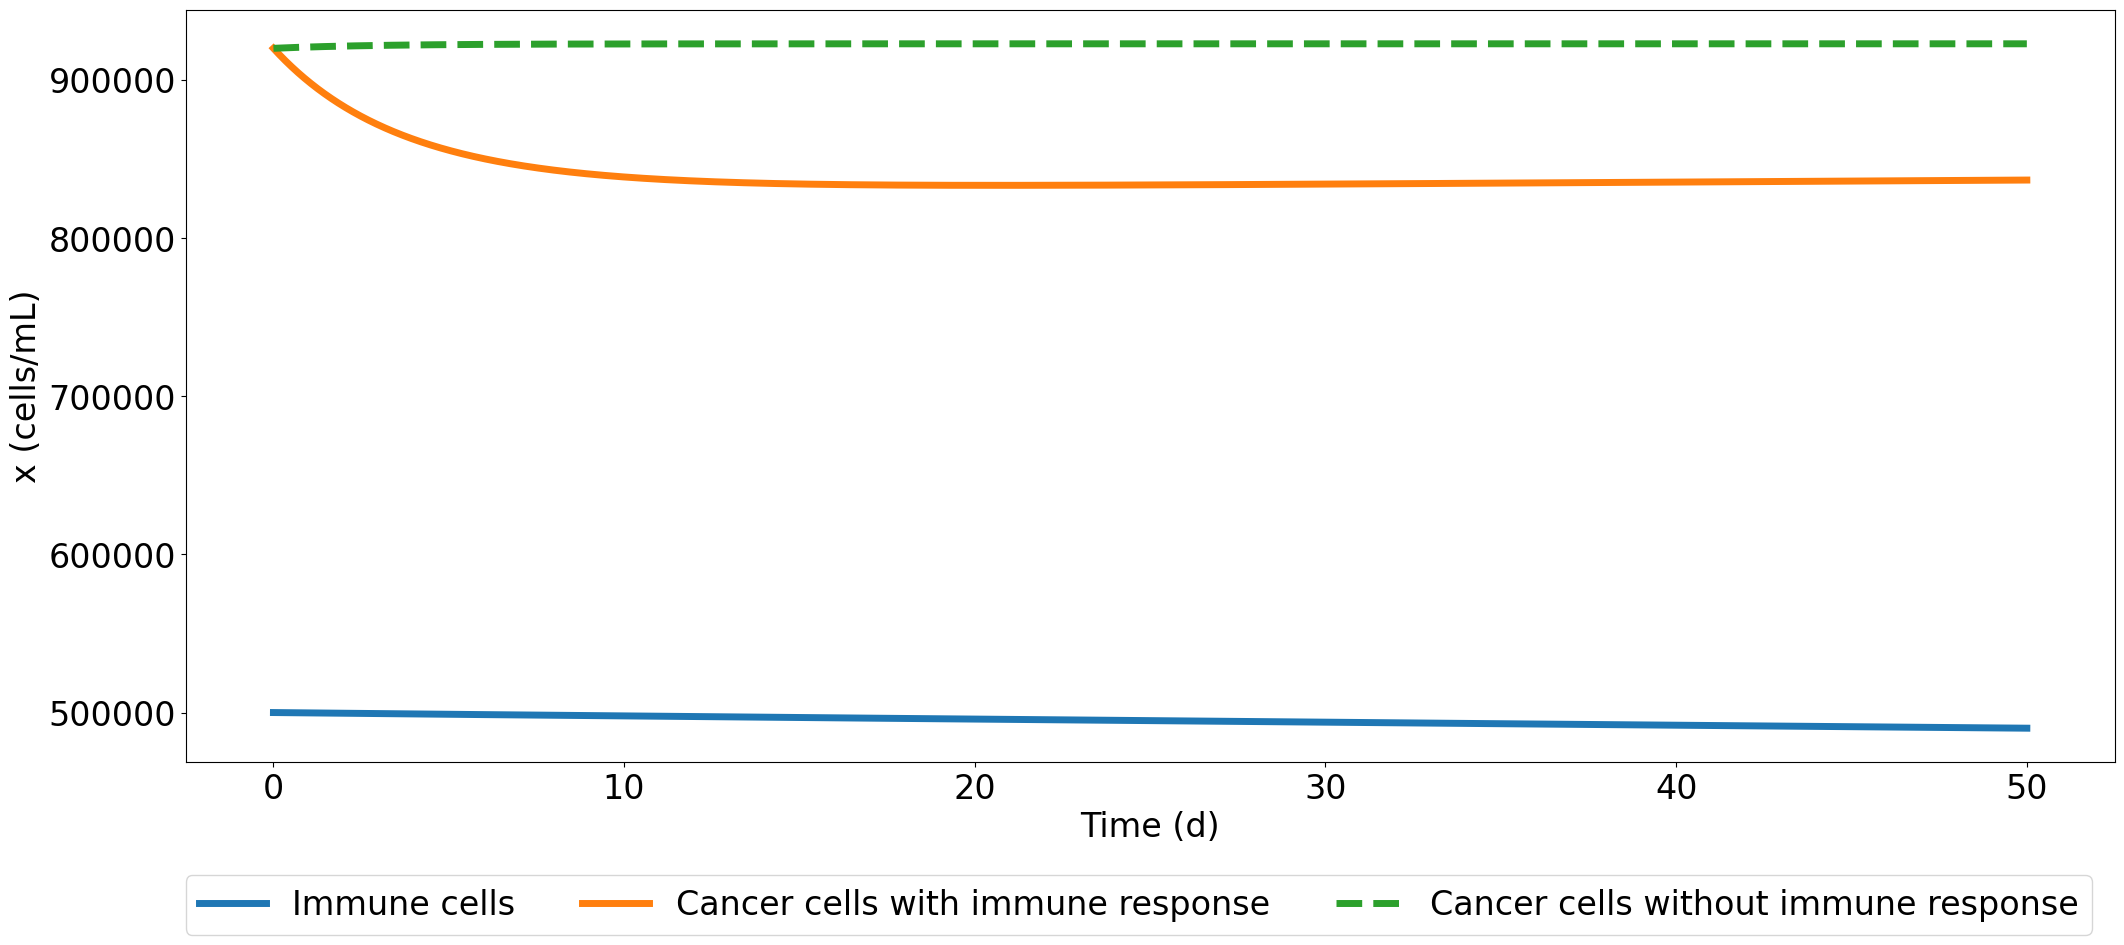

In [67]:
# Setting the initial population density of cancer cells to a high value
x0_test = 0.92e6
# Create an array containing the number of days we run the simulation for
t_show_no_treatment = np.arange(0, 50 + dt, dt)

# Finding population density before when there is an immune response
popDensity_immune_x_no_treatment = odeint(growthRate_immune_toxicity, [x0_test, y0], t_show_no_treatment, args =(K, r, mu_no_drug, h, tau, n, c, g, m, d, d, s))[:,0]
popDensity_immune_y_no_treatment = odeint(growthRate_immune_toxicity, [x0_test, y0], t_show_no_treatment, args =(K, r, mu_no_drug, h, tau, n, c, g, m, d, d, s))[:,1]

# Finding population density before when there is no immune response
popDensity_x_no_treatment = odeint(growthRate, x0_test, t_show_no_treatment, args=(K, mu_no_drug, r))

# Plot results
plt.figure(figsize=(23, 10))
plt.plot(t_show_no_treatment, popDensity_immune_y_no_treatment, label = 'Immune cells', linewidth=5.0)
plt.plot(t_show_no_treatment, popDensity_immune_x_no_treatment, label='Cancer cells with immune response', linewidth=5.0)
plt.plot(t_show_no_treatment, popDensity_x_no_treatment, label='Cancer cells without immune response', linewidth=5.0, linestyle='dashed')

plt.xlabel('Time (d)')
plt.ylabel('x (cells/mL)')
plt.rcParams.update({'font.size': 24})
plt.legend(loc='upper left', bbox_to_anchor=(0, -0.15), ncol=4, borderaxespad=0, fontsize=24)
plt.tight_layout()
plt.savefig('NoTreatment_immuneResponse_highPop.pdf', format='pdf', bbox_inches='tight')
plt.show()

#### Impact of immune cells, default initial population density (Fig 4.2.2)

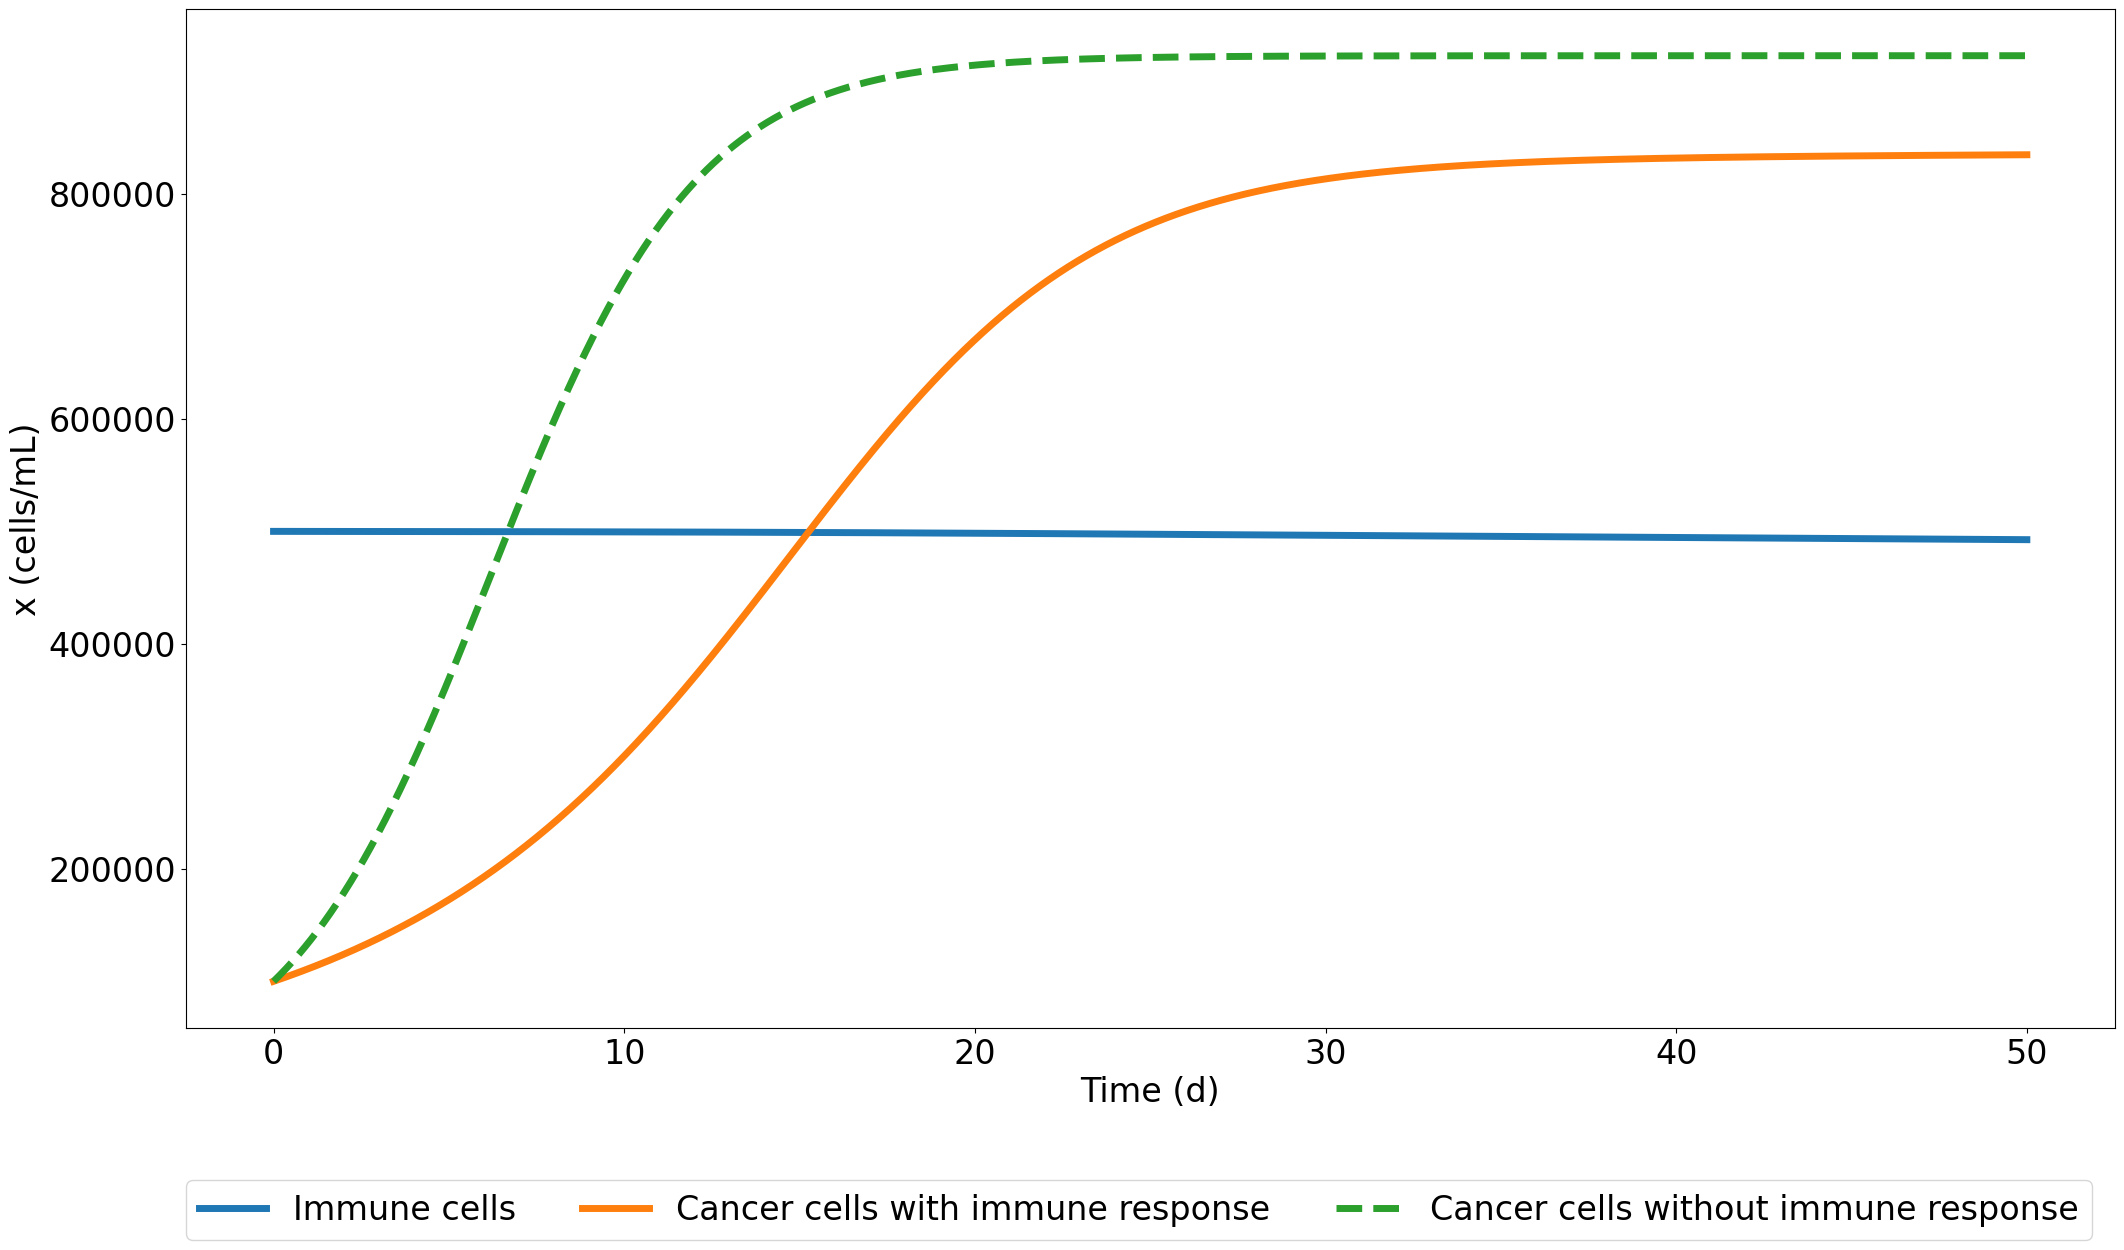

In [68]:
# Create an array containing the number of days we run the simulation for
t_show_no_treatment = np.arange(0, 50 + dt, dt)

# Finding population density before when there is an immune response
popDensity_immune_x_no_treatment = odeint(growthRate_immune_toxicity, [x0,y0], t_show_no_treatment, args =(K, r, mu_no_drug, h, tau, n, c, g, m, d, d, s))[:,0]
popDensity_immune_y_no_treatment = odeint(growthRate_immune_toxicity, [x0,y0], t_show_no_treatment, args =(K, r, mu_no_drug, h, tau, n, c, g, m, d, d, s))[:,1]

# Finding population density before when there is no immune response
popDensity_x_no_treatment = odeint(growthRate, x0, t_show_no_treatment, args=(K, mu_no_drug, r))

# Plot results
plt.figure(figsize=(23, 13))
plt.plot(t_show_no_treatment, popDensity_immune_y_no_treatment, label = 'Immune cells', linewidth=5.0)
plt.plot(t_show_no_treatment, popDensity_immune_x_no_treatment, label='Cancer cells with immune response', linewidth=5.0)
plt.plot(t_show_no_treatment, popDensity_x_no_treatment, label='Cancer cells without immune response', linewidth=5.0, linestyle='dashed')

plt.xlabel('Time (d)')
plt.ylabel('x (cells/mL)')
plt.rcParams.update({'font.size': 24})
plt.legend(loc='upper left', bbox_to_anchor=(0, -0.15), ncol=4, borderaxespad=0, fontsize=24)
plt.tight_layout()
plt.savefig('NoTreatment_immuneResponse_normal.pdf', format='pdf', bbox_inches='tight')
plt.show()

### Impact of immune cells on cancer growth in treatment strategies

In [69]:
# Defining a ist of parameters when looking at no immune response
parameters_noImmune = [K, x0, r, n, 1, 0, 0, 0, 0, 0, 0, mu_Q, mu_C, mu_A, mu_V, a, b_Q, b_C, b_A, b_V, p_Q, p_C, p_A, p_V, tau, h]

#### Impact of immune resposne in azacitidine-venetoclax regimen (Fig 4.2.3)

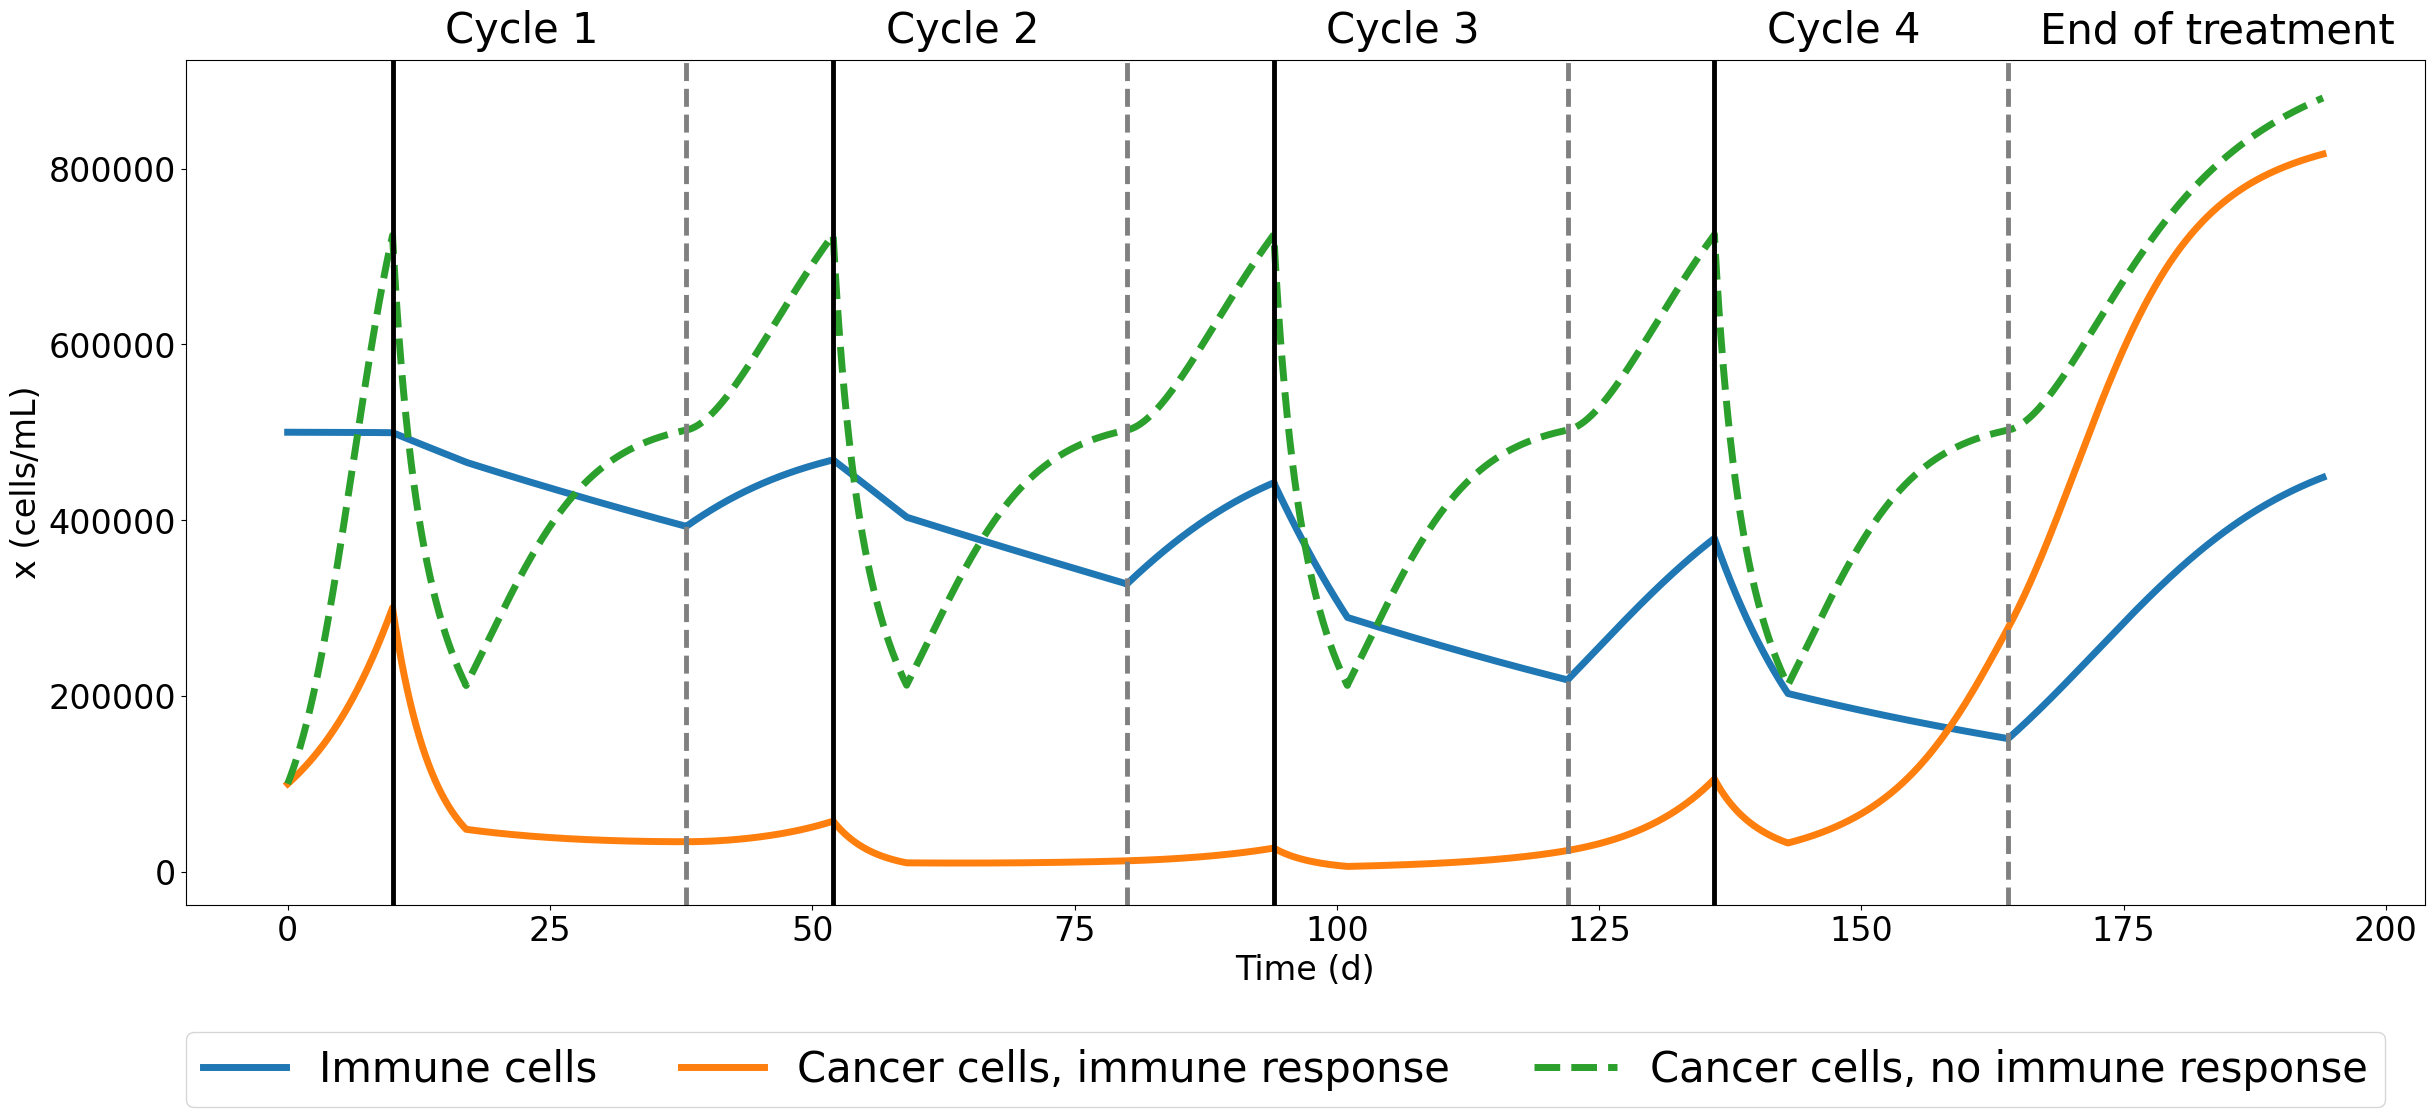

In [70]:
# Define treatment phases 
# Each tuple contains 
# ('name of drug', duration of drug, death rate of drug, maximal death rate of immune cells due to drug, halflife of drug applied before cell recovery, 
# first letter of drug, whether or not treatment is currently applied (True if no treatment, False if not))
treatment_phases = [
    ('Azacitidine + Venetoclax', 7, mu_AV, d_max_AV, 0, 'AV', False),
    ('Venetoclax', 21, mu_V, d_max_V, 0, 'V', False),
    ('Cell recovery', 14, mu_V, d, 10, 'V', True),

    ('Azacitidine + Venetoclax', 7, mu_AV, d_max_AV, 0, 'AV', False),
    ('Venetoclax', 21, mu_V, d_max_V, 0, 'V', False),
    ('Cell recovery', 14, mu_V, d, 10, 'V', True),

    ('Azacitidine + Venetoclax', 7, mu_AV, d_max_AV, 0, 'AV', False),
    ('Venetoclax', 21, mu_V, d_max_V, 0, 'V', False),
    ('Cell recovery', 14, mu_V, d, 10, 'V', True),

    ('Azacitidine + Venetoclax', 7, mu_AV, d_max_AV, 0, 'AV', False),
    ('Venetoclax', 21, mu_V, d_max_V, 0, 'V', False),
    ('Cell recovery', 30, mu_V, d, 10, 'V', True),
]

# Collect list of populations for azacitidine-venetoclax treatment with immune response
t, t_after_treatment, density, immune, sensitive, resistant_A, resistant_V, resistant_Q, resistant_C, t_values = simulate_treatment(treatment_phases, daysBeforeTreatment, parameters, gI)

# Collect list of needed populations for azacitidine-venetoclax treatment without immune response
_, _, density_noImmune, _, _, _, _, _, _, _ = simulate_treatment(treatment_phases, daysBeforeTreatment, parameters_noImmune, gI)

# Plot results
plt.figure(figsize=(26.5, 12))
plt.plot(t, immune, label='Immune cells', linewidth=5.0)
plt.plot(t, density, label='Cancer cells, immune response', linewidth=5.0)
plt.plot(t, density_noImmune, label = 'Cancer cells, no immune response', linewidth=5.0, linestyle='dashed')

# Plotting headlines for each treatment phase
# Annotate treatment cycles right after each begins
cycle_labels = ['Cycle 1', 'Cycle 2', 'Cycle 3', 'Cycle 4', 'End of treatment']
cycle_starts = [
    daysBeforeTreatment + 4,
    daysBeforeTreatment + 46,
    daysBeforeTreatment + 88,
    daysBeforeTreatment + 130,
    daysBeforeTreatment + 156
]

y_pos = max(max(density), max(density_noImmune), max(immune)) * 1.06  # small offset above max y

for label, xpos in zip(cycle_labels, cycle_starts):
    plt.text(xpos + 1, y_pos, label, ha='left', va='bottom', fontsize=30)

# Plotting line for the start and end of a treatment phase
plt.axvline(daysBeforeTreatment, color = 'black', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 28, color = 'gray', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 42, color = 'black', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 70, color = 'gray', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 84, color = 'black', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 112, color = 'gray', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 126, color = 'black', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 154, color = 'gray', linewidth=3.5, linestyle='dashed')


plt.xlabel('Time (d)')
plt.ylabel('x (cells/mL)')
plt.rcParams.update({'font.size': 30})
plt.legend(loc='upper left', bbox_to_anchor=(0, -0.15), ncol=3, borderaxespad=0, fontsize=30)
plt.tight_layout()
plt.savefig('VIALEA.pdf', format='pdf', bbox_inches='tight')
plt.show()

#### Impact of immune resposne in cytarabine-quizartinib regimen (Fig 4.2.4)

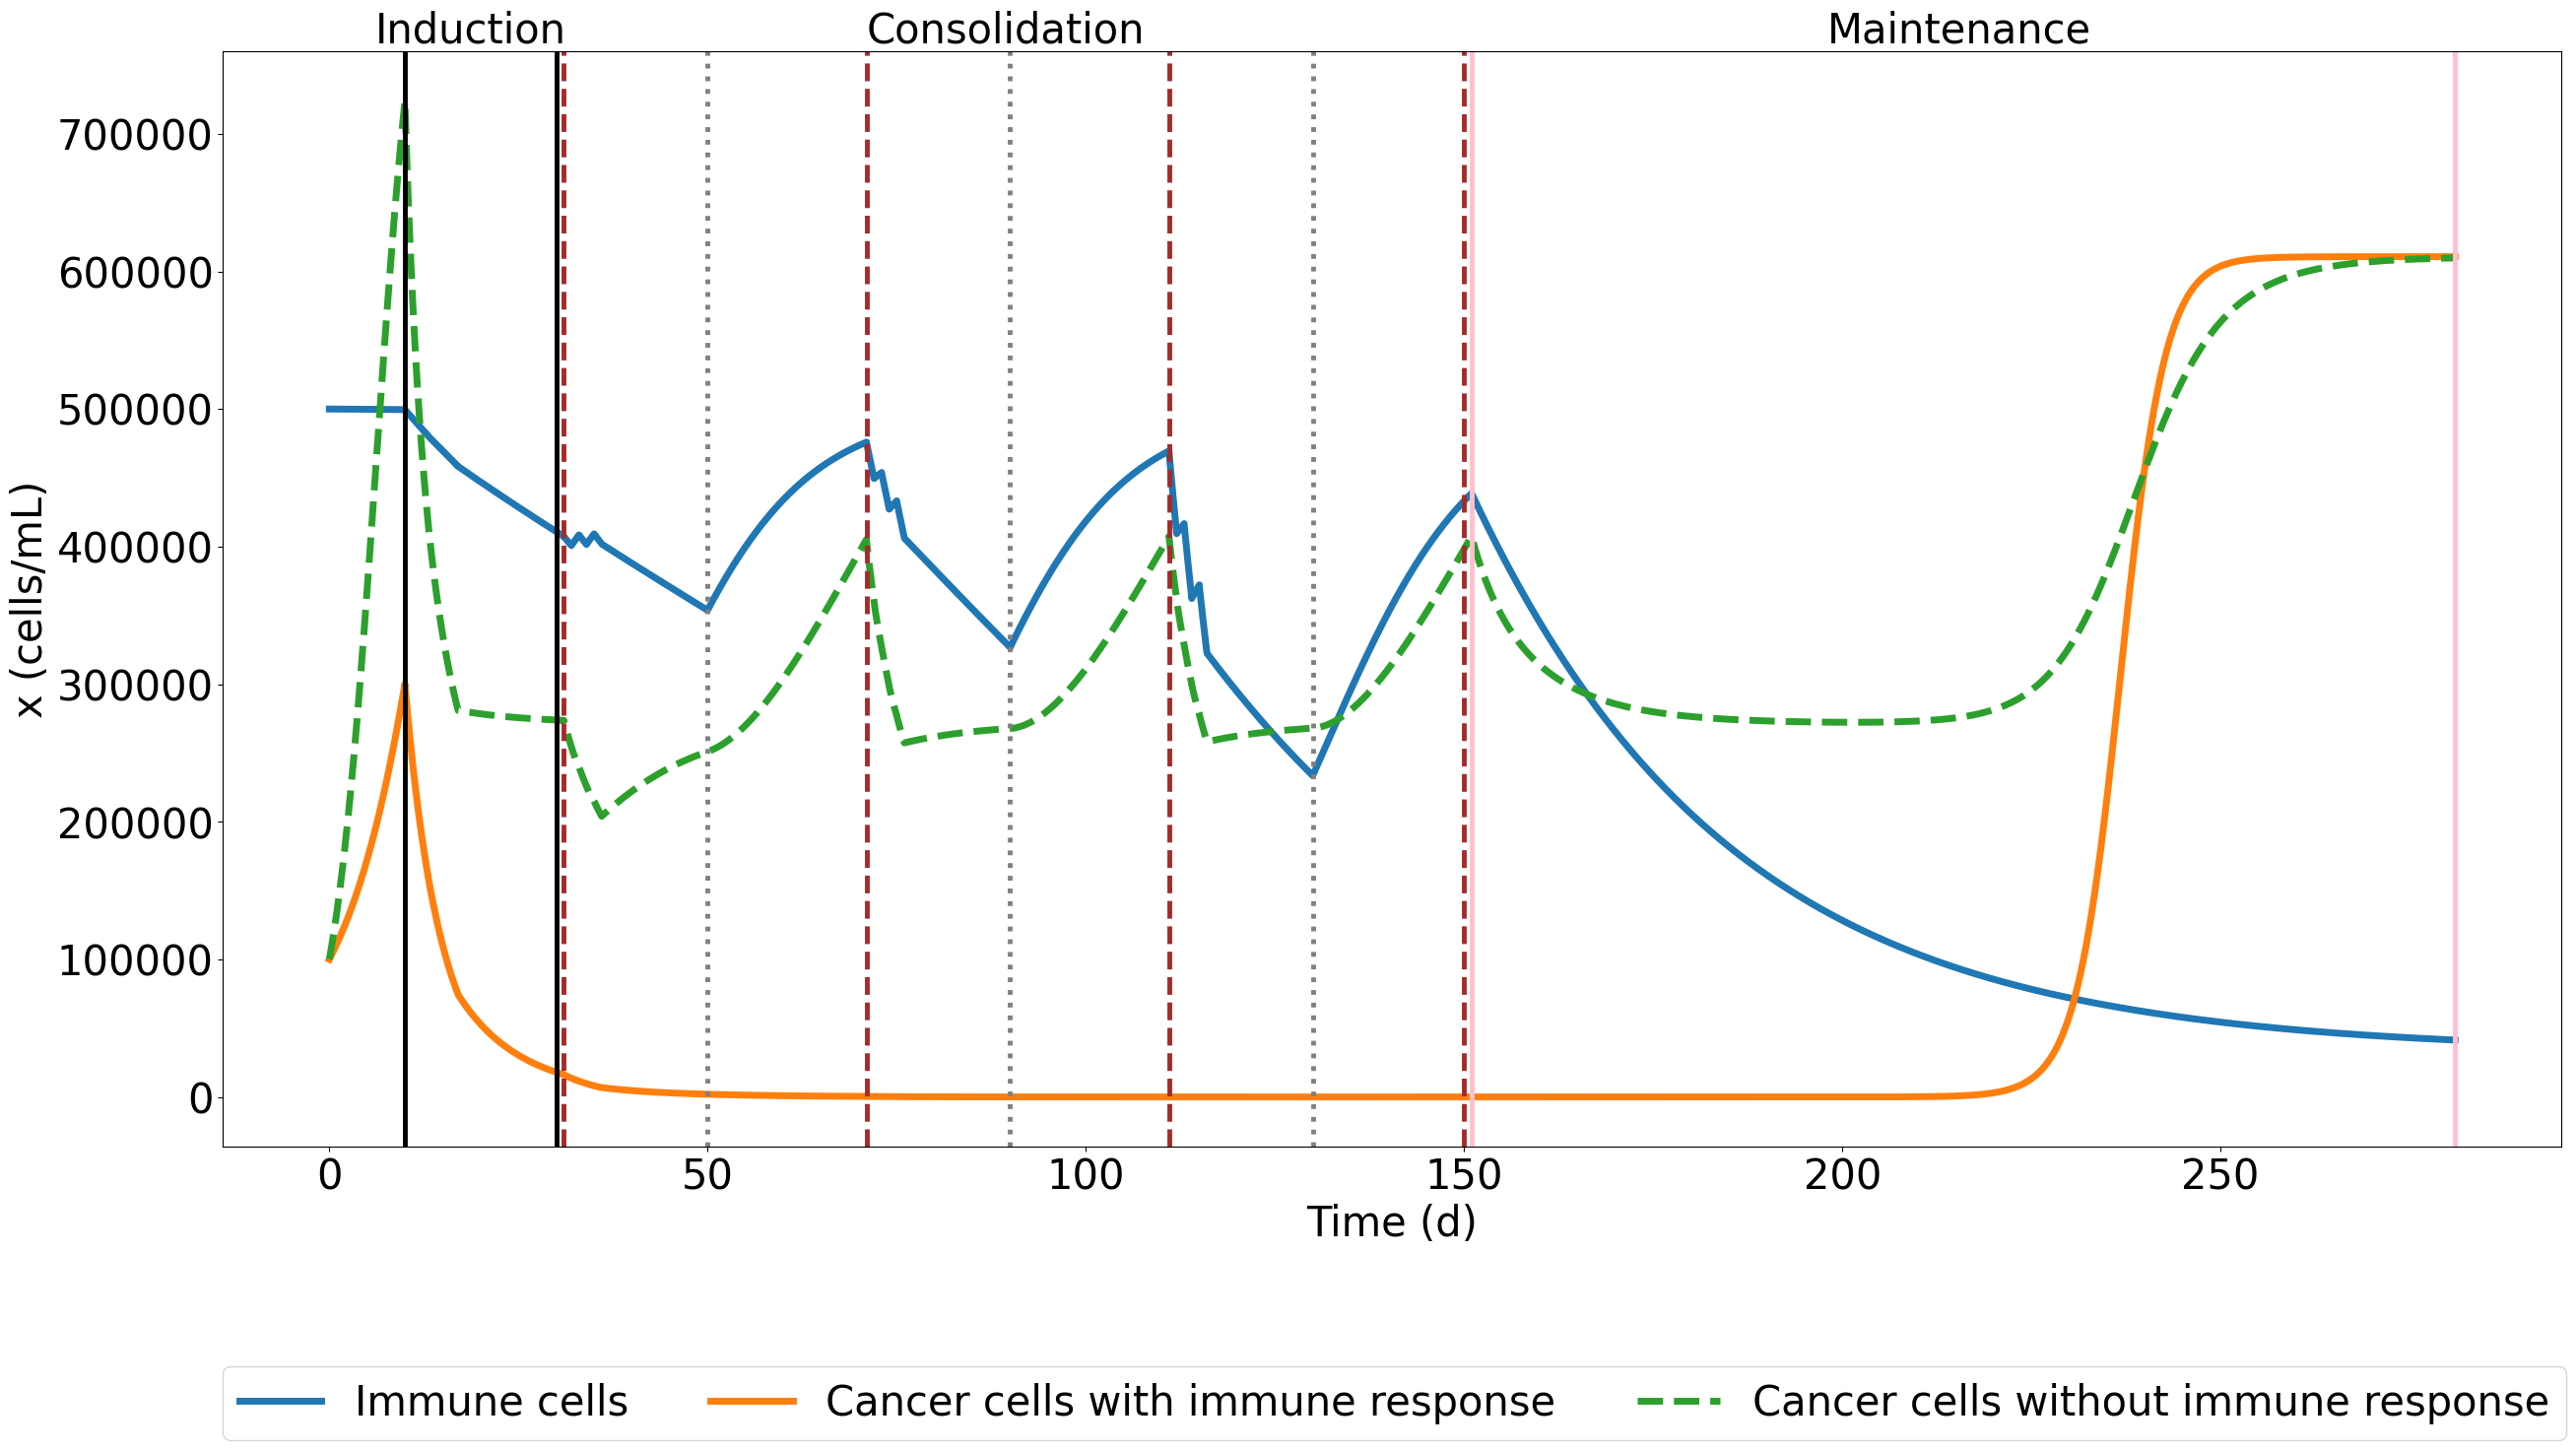

In [71]:
# Define treatment phases 
# Each tuple contains 
# ('name of drug', duration of drug, death rate of drug, maximal death rate of immune cells due to drug, halflife of drug applied before cell recovery, 
# first letter of drug, whether or not treatment is currently applied (True if no treatment, False if not))
treatment_phases = [
    #Induction phase
    ('Cytarabine + Anthracycline', 3, mu_CA, d_max_CA, 0, 'C', False),
    ('Cytarabine', 4, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),

    #Consolidation
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 21, mu_Q, d, 42, 'Q', True),

    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 21, mu_Q, d, 42, 'Q', True),

    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 21, mu_Q, d, 42, 'Q', True),

    #Maintenance
    ('Quizartinib', 130, mu_Q, d_max_Q, 0, 'Q', False),
]

# Collect list of populations for cytarabine-quizartinib treatment with immune response
t, t_after_treatment, density, immune, sensitive, resistant_A, resistant_V, resistant_Q, resistant_C, t_values = simulate_treatment(treatment_phases, daysBeforeTreatment, parameters, gI)

# Collect list of needed populations for cytarabine-quizartinib  treatment without immune response
_, _, density_noImmune, _, _, _, _, _, _, _ = simulate_treatment(treatment_phases, daysBeforeTreatment, parameters_noImmune, gI)

# Plot results
plt.figure(figsize=(28.5, 15.6))
plt.plot(t, immune, label='Immune cells', linewidth=5.0)
plt.plot(t, density, label='Cancer cells with immune response', linewidth=5.0)
plt.plot(t, density_noImmune, label = 'Cancer cells without immune response', linewidth=5.0, linestyle='dashed')

# Plotting headlines for each treatment phase
# Annotate treatment phases 
phase_labels = ['Induction', 'Consolidation', 'Maintenance']
phase_starts = [daysBeforeTreatment - 5,
                daysBeforeTreatment + 60,
                daysBeforeTreatment + 187]

# Set y-position slightly above max y-value
y_pos = max(max(density), max(density_noImmune), max(immune)) * 1.05

# Add labels just after each phase starts
for label, xpos in zip(phase_labels, phase_starts):
    plt.text(xpos + 1, y_pos, label, ha='left', va='bottom', fontsize=30)

# Plotting line for the start and end of a treatment phase
plt.axvline(daysBeforeTreatment, color='black', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 20, color='black', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 21, color = 'brown', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 40, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 61, color = 'brown', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 80, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 101, color = 'brown', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 120, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 140, color = 'brown', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 141, color = 'pink', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 271, color = 'pink', linewidth=3.5)

plt.xlabel('Time (d)')
plt.ylabel('x (cells/mL)')
plt.rcParams.update({'font.size': 30})
plt.legend(loc='upper left', bbox_to_anchor=(0, -0.2), ncol=3, borderaxespad=0, fontsize=30)
plt.tight_layout()
plt.savefig('QuANTUM-First_immuneandnot.pdf', format='pdf', bbox_inches='tight')
plt.show()

#### Plotting occurence of resistance in cytarabine-quizartinib regimen (Fig 4.2.5)

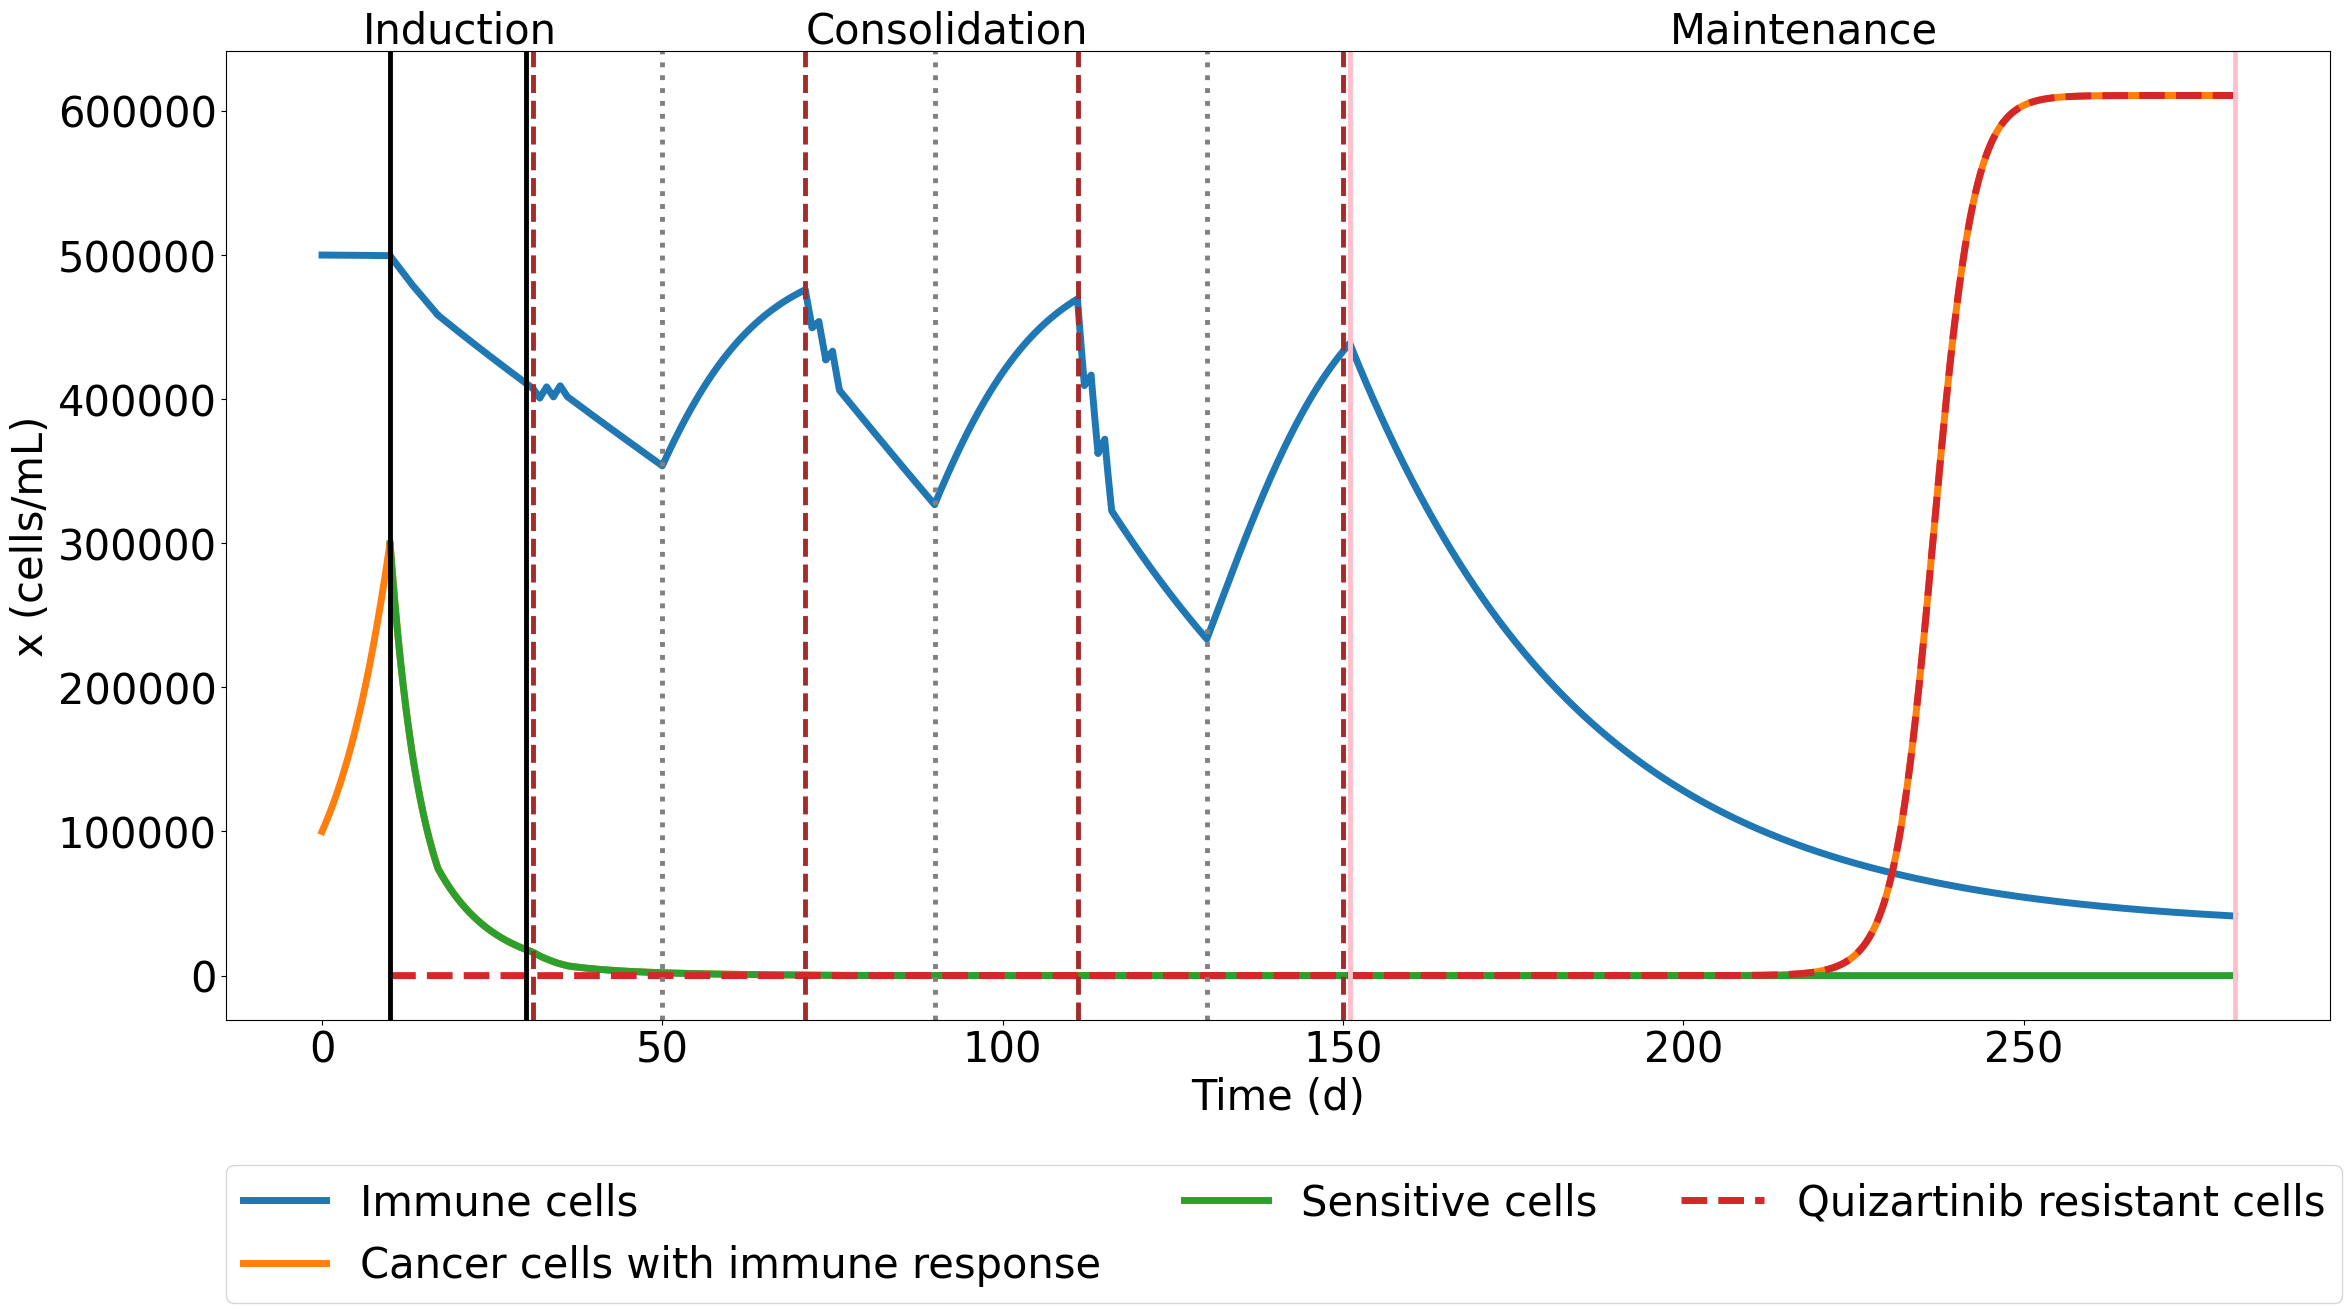

In [72]:
# Define treatment phases 
# Each tuple contains 
# ('name of drug', duration of drug, death rate of drug, maximal death rate of immune cells due to drug, halflife of drug applied before cell recovery, 
# first letter of drug, whether or not treatment is currently applied (True if no treatment, False if not))
treatment_phases = [
    #Induction phase
    ('Cytarabine + Anthracycline', 3, mu_CA, d_max_CA, 0, 'C', False),
    ('Cytarabine', 4, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),

    #Consolidation
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 21, mu_Q, d, 42, 'Q', True),

    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 21, mu_Q, d, 42, 'Q', True),

    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 21, mu_Q, d, 42, 'Q', True),

    #Maintenance
    ('Quizartinib', 130, mu_Q, d_max_Q, 0, 'Q', False),
]

# Collect list of populations for cytarabine-quizartinib treatment with immune response
t, t_after_treatment, density, immune, sensitive, resistant_A, resistant_V, resistant_Q, resistant_C, t_values = simulate_treatment(treatment_phases, daysBeforeTreatment, parameters, gI)

# Plot results
plt.figure(figsize=(25.5, 14))
plt.plot(t, immune, label='Immune cells', linewidth=5.0)
plt.plot(t, density, label='Cancer cells with immune response', linewidth=5.0)
plt.plot(t_after_treatment, sensitive, label = 'Sensitive cells', linewidth=5.0)
plt.plot(t_after_treatment, resistant_Q, label='Quizartinib resistant cells', linewidth=5.0, linestyle='dashed')

# Plotting headlines for each treatment phase
# Annotate treatment phases 
phase_labels = ['Induction', 'Consolidation', 'Maintenance']
phase_starts = [daysBeforeTreatment - 5,
                daysBeforeTreatment + 60,
                daysBeforeTreatment + 187]

# Set y-position slightly above max y-value
y_pos = max(max(density), max(resistant_Q), max(immune)) * 1.05

# Add labels just after each phase starts
for label, xpos in zip(phase_labels, phase_starts):
    plt.text(xpos + 1, y_pos, label, ha='left', va='bottom', fontsize=30)

# Plotting line for the start and end of a treatment phase
plt.axvline(daysBeforeTreatment, color='black', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 20, color='black', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 21, color = 'brown', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 40, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 61, color = 'brown', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 80, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 101, color = 'brown', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 120, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 140, color = 'brown', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 141, color = 'pink', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 271, color = 'pink', linewidth=3.5)

plt.xlabel('Time (d)')
plt.ylabel('x (cells/mL)')
plt.rcParams.update({'font.size': 30})
plt.legend(loc='upper left', bbox_to_anchor=(0, -0.15), ncol=3, borderaxespad=0, fontsize=30)
plt.tight_layout()
plt.savefig('QuANTUM-First_Res.pdf', format='pdf', bbox_inches='tight')
plt.show()

#### Simulating resistance development with default and lower toxicity (Fig 4.2.6)

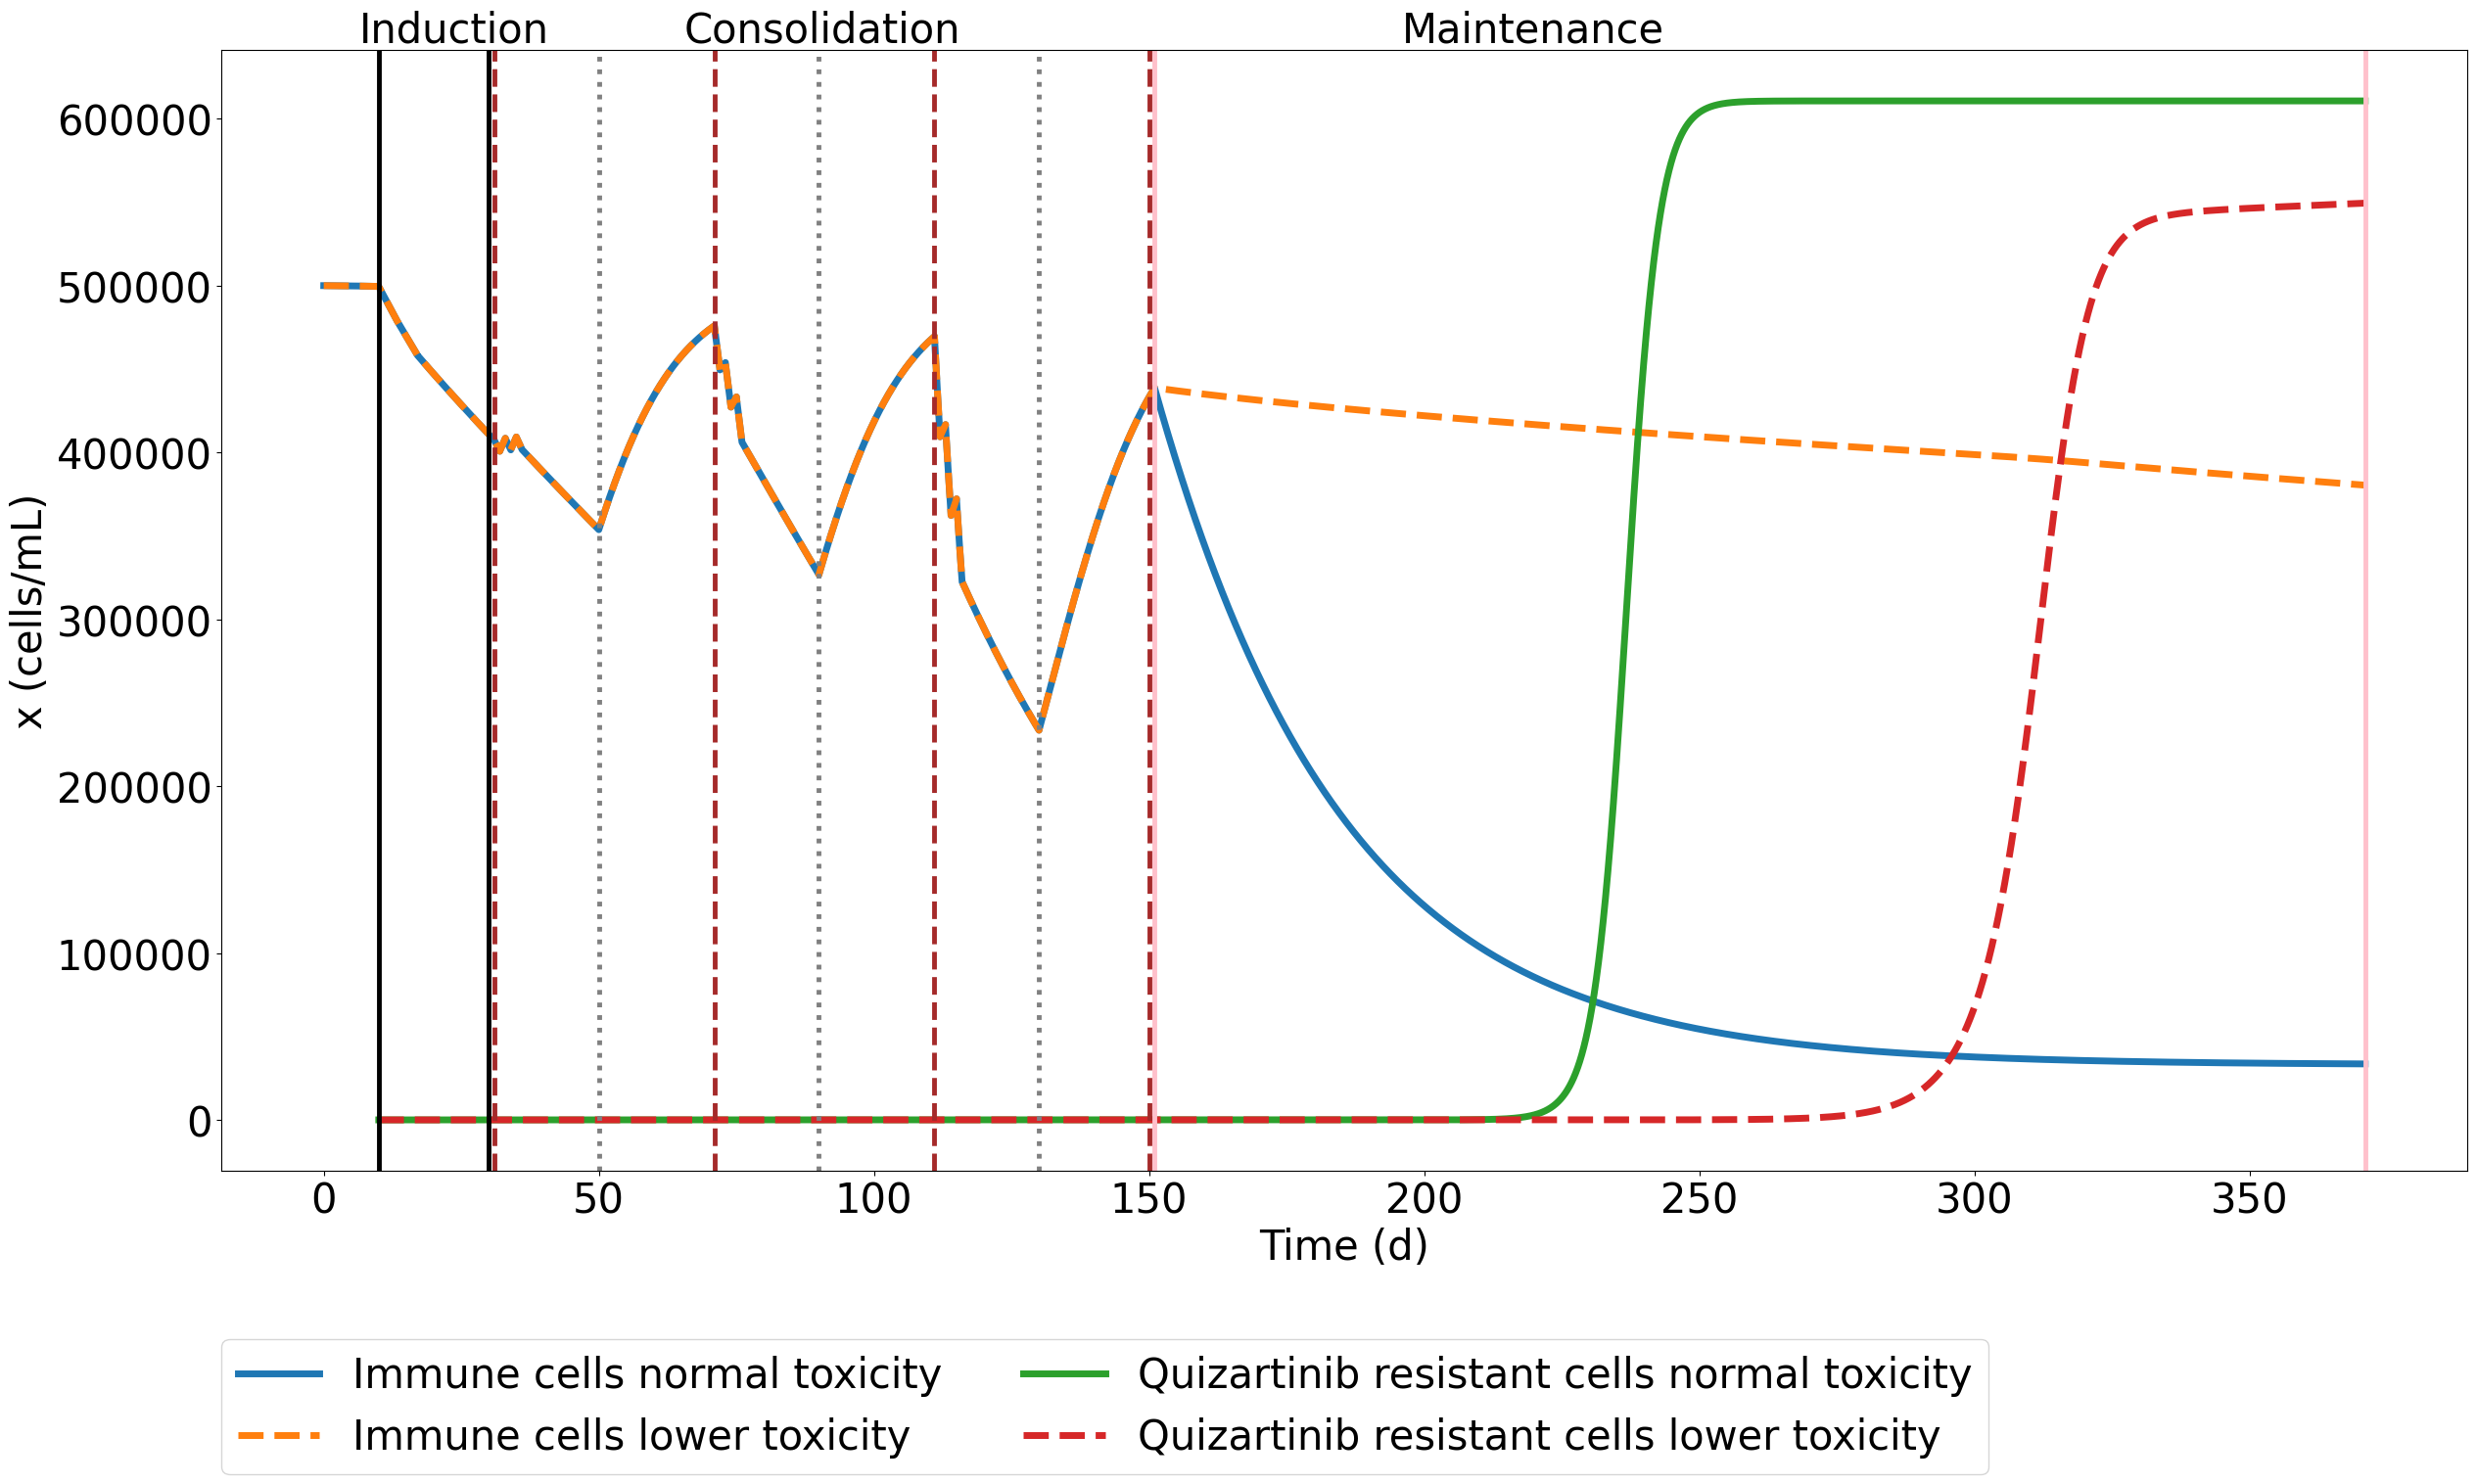

In [73]:
# Define treatment phases 
# Each tuple contains 
# ('name of drug', duration of drug, death rate of drug, maximal death rate of immune cells due to drug, halflife of drug applied before cell recovery, 
# first letter of drug, whether or not treatment is currently applied (True if no treatment, False if not))
treatment_phases = [
    #Induction phase
    ('Cytarabine + Anthracycline', 3, mu_CA, d_max_CA, 0, 'C', False),
    ('Cytarabine', 4, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),

    #Consolidation
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 21, mu_Q, d, 42, 'Q', True),

    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 21, mu_Q, d, 42, 'Q', True),

    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 21, mu_Q, d, 42, 'Q', True),

    #Maintenance
    ('Quizartinib', 220, mu_Q, d_max_Q, 0, 'Q', False),
]

# Defining treatment phases, setting the value for d_max in the maintenance phase to 1/10 of the value in the list defined above
treatment_phases_lowTox = [
    #Induction phase
    ('Cytarabine + Anthracycline', 3, mu_CA, d_max_CA, 0, 'C', False),
    ('Cytarabine', 4, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),

    #Consolidation
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 21, mu_Q, d, 42, 'Q', True),

    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 21, mu_Q, d, 42, 'Q', True),

    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 21, mu_Q, d, 42, 'Q', True),

    #Maintenance
    ('Quizartinib', 220, mu_Q, 1/10*d_max_Q, 0, 'Q', False),
]

# Collect list of populations for cytarabine-quizartinib treatment with normal toxicity
t, t_after_treatment, density, immune, sensitive, resistant_A, resistant_V, resistant_Q, resistant_C, t_values = simulate_treatment(treatment_phases, daysBeforeTreatment, parameters, gI)
# Collect list of populations for cytarabine-quizartinib treatment with lower toxicity in maintenance phase
_, _, _, immune_lowTox, _, _, _, resQ_lowTox, _, _, = simulate_treatment(treatment_phases_lowTox, daysBeforeTreatment, parameters, gI)

# Plot results
plt.figure(figsize=(26, 16))
plt.plot(t, immune, label='Immune cells normal toxicity', linewidth=5.0)
plt.plot(t, immune_lowTox, label='Immune cells lower toxicity', linewidth=5.0, linestyle='dashed')
plt.plot(t_after_treatment, resistant_Q, label='Quizartinib resistant cells normal toxicity', linewidth=5.0)
plt.plot(t_after_treatment, resQ_lowTox, label='Quizartinib resistant cells lower toxicity', linewidth=5.0, linestyle='dashed')

# Plotting headlines for each treatment phase
# Annotate treatment phases 
phase_labels = ['Induction', 'Consolidation', 'Maintenance']
phase_starts = [daysBeforeTreatment - 4.5,
                daysBeforeTreatment + 54.5,
                daysBeforeTreatment + 185]

# Set y-position slightly above max y-value
y_pos = max(max(density), max(immune_lowTox), max(immune)) * 1.05

# Add labels just after each phase starts
for label, xpos in zip(phase_labels, phase_starts):
    plt.text(xpos + 1, y_pos, label, ha='left', va='bottom', fontsize=30)

# Plotting line for the start and end of a treatment phase
plt.axvline(daysBeforeTreatment, color='black', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 20, color='black', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 21, color = 'brown', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 40, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 61, color = 'brown', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 80, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 101, color = 'brown', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 120, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 140, color = 'brown', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 141, color = 'pink', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 361, color = 'pink', linewidth=3.5)

plt.xlabel('Time (d)')
plt.ylabel('x (cells/mL)')
plt.rcParams.update({'font.size': 30})
plt.legend(loc='upper left', bbox_to_anchor=(0, -0.15), ncol=2, borderaxespad=0, fontsize=30)
plt.tight_layout()
plt.savefig('QuANTUM-First_Res_lowTox.pdf', format='pdf', bbox_inches='tight')
plt.show()

### Simulating intermittent doing of quizartinib in maintenance phase

#### 14 day continous quizartinib before cell recovery (Fig 4.3.1a)

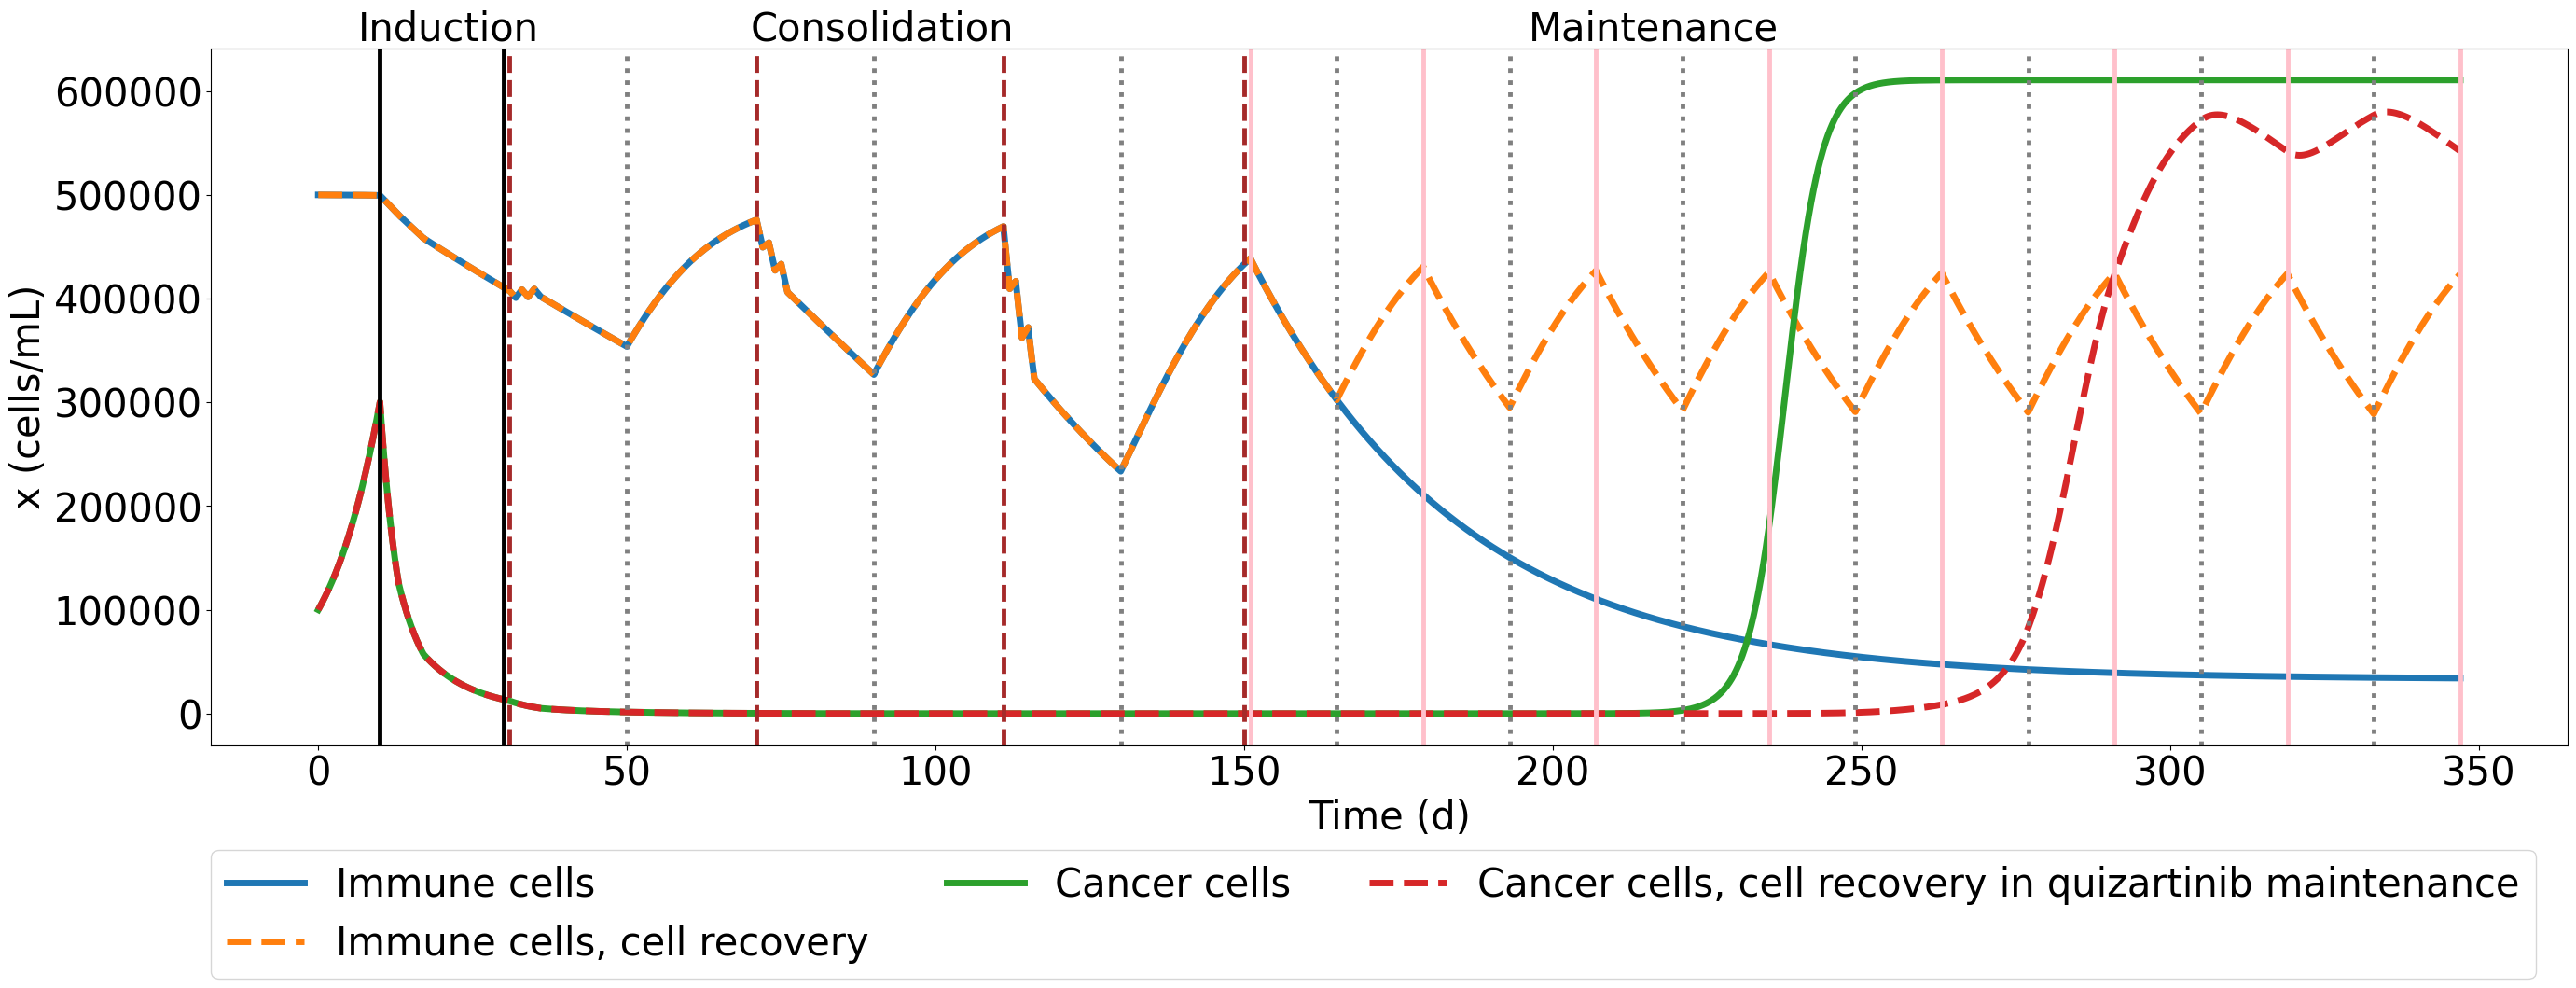

In [74]:
# Define treatment phases of normal cytarabine-quizartinib
# Each tuple contains 
# ('name of drug', duration of drug, death rate of drug, maximal death rate of immune cells due to drug, halflife of drug applied before cell recovery, 
# first letter of drug, whether or not treatment is currently applied (True if no treatment, False if not))
treatment_phases = [
    #Induction phase
    ('Cytarabine + Anthracycline', 3, mu_CAQ, d_max_CA, 0, 'C', False),
    ('Cytarabine', 4, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),

    #Consolidation
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 21, mu_Q, d, 42, 'Q', True),

    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 21, mu_Q, d, 42, 'Q', True),

    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 21, mu_Q, d, 42, 'Q', True),

    #Maintenance
    ('Quizartinib', 196, mu_Q, d_max_Q, 0, 'Q', False),
]

# Define treatment phases for cell recovery in between quizartinib administration
treatment_phases_cellRecovery = [
    #Induction phase
    ('Cytarabine + Anthracycline', 3, mu_CAQ, d_max_CA, 0, 'C', False),
    ('Cytarabine', 4, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),

    #Consolidation
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 21, mu_Q, d, 42, 'Q', True),

    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 21, mu_Q, d, 42, 'Q', True),

    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 21, mu_Q, d, 42, 'Q', True),

    #Maintenance
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 14, mu_Q, d, 42, 'Q', True),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 14, mu_Q, d, 42, 'Q', True),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 14, mu_Q, d, 42, 'Q', True),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 14, mu_Q, d, 42, 'Q', True),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 14, mu_Q, d, 42, 'Q', True),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 14, mu_Q, d, 42, 'Q', True),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 14, mu_Q, d, 42, 'Q', True),
]

# Collect list of populations for cytarabine-quizartinib treatment with continuous quizartinib administration in maintenance
t, t_after_treatment, density, immune, sensitive, resistant_A, resistant_V, resistant_Q, resistant_C, t_values = simulate_treatment(treatment_phases, daysBeforeTreatment, parameters, gI)
# Collect list of populations for cytarabine-quizartinib treatment with intermittent quizartinib administration in maintenance
t_q, _, popDensity_quizartinibChange, immune_q, _, _, _, _, _, _ = simulate_treatment(treatment_phases_cellRecovery, daysBeforeTreatment, parameters, gI)


# Plotting line for the start and end of a treatment phase
# Plot results
plt.figure(figsize=(30, 11.5))
plt.plot(t, immune, label='Immune cells', linewidth=5.0)
plt.plot(t_q, immune_q, label='Immune cells, cell recovery', linewidth=5.0, linestyle='dashed')
plt.plot(t, density, label='Cancer cells', linewidth=5.0)
plt.plot(t_q, popDensity_quizartinibChange, label='Cancer cells, cell recovery in quizartinib maintenance', linewidth=5.0, linestyle='dashed')

# Plotting headlines for each treatment phase
# Annotate treatment phases 
phase_labels = ['Induction', 'Consolidation', 'Maintenance']
phase_starts = [daysBeforeTreatment - 4.5,
                daysBeforeTreatment + 59,
                daysBeforeTreatment + 185]

# Set y-position slightly above max y-value
y_pos = max(max(density), max(immune_q), max(immune)) * 1.05

# Add labels just after each phase starts
for label, xpos in zip(phase_labels, phase_starts):
    plt.text(xpos + 1, y_pos, label, ha='left', va='bottom', fontsize=30)

# Plotting line for the start and end of a treatment phase
plt.axvline(daysBeforeTreatment, color='black', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 20, color='black', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 21, color = 'brown', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 40, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 61, color = 'brown', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 80, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 101, color = 'brown', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 120, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 140, color = 'brown', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 141, color = 'pink', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 155, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 169, color = 'pink', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 183, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 197, color = 'pink', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 211, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 225, color = 'pink', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 239, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 253, color = 'pink', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 267, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 281, color = 'pink', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 295, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 309, color = 'pink', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 323, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 337, color = 'pink', linewidth=3.5)

plt.xlabel('Time (d)')
plt.ylabel('x (cells/mL)')
plt.rcParams.update({'font.size': 30})
plt.legend(loc='upper left', bbox_to_anchor=(0, -0.15), ncol=3, borderaxespad=0, fontsize=30)
plt.tight_layout()
plt.savefig('QuzRecovery_14.pdf', format='pdf', bbox_inches='tight')
plt.show()

#### 7 day continous quizartinib before cell recovery (Fig 4.3.1b)

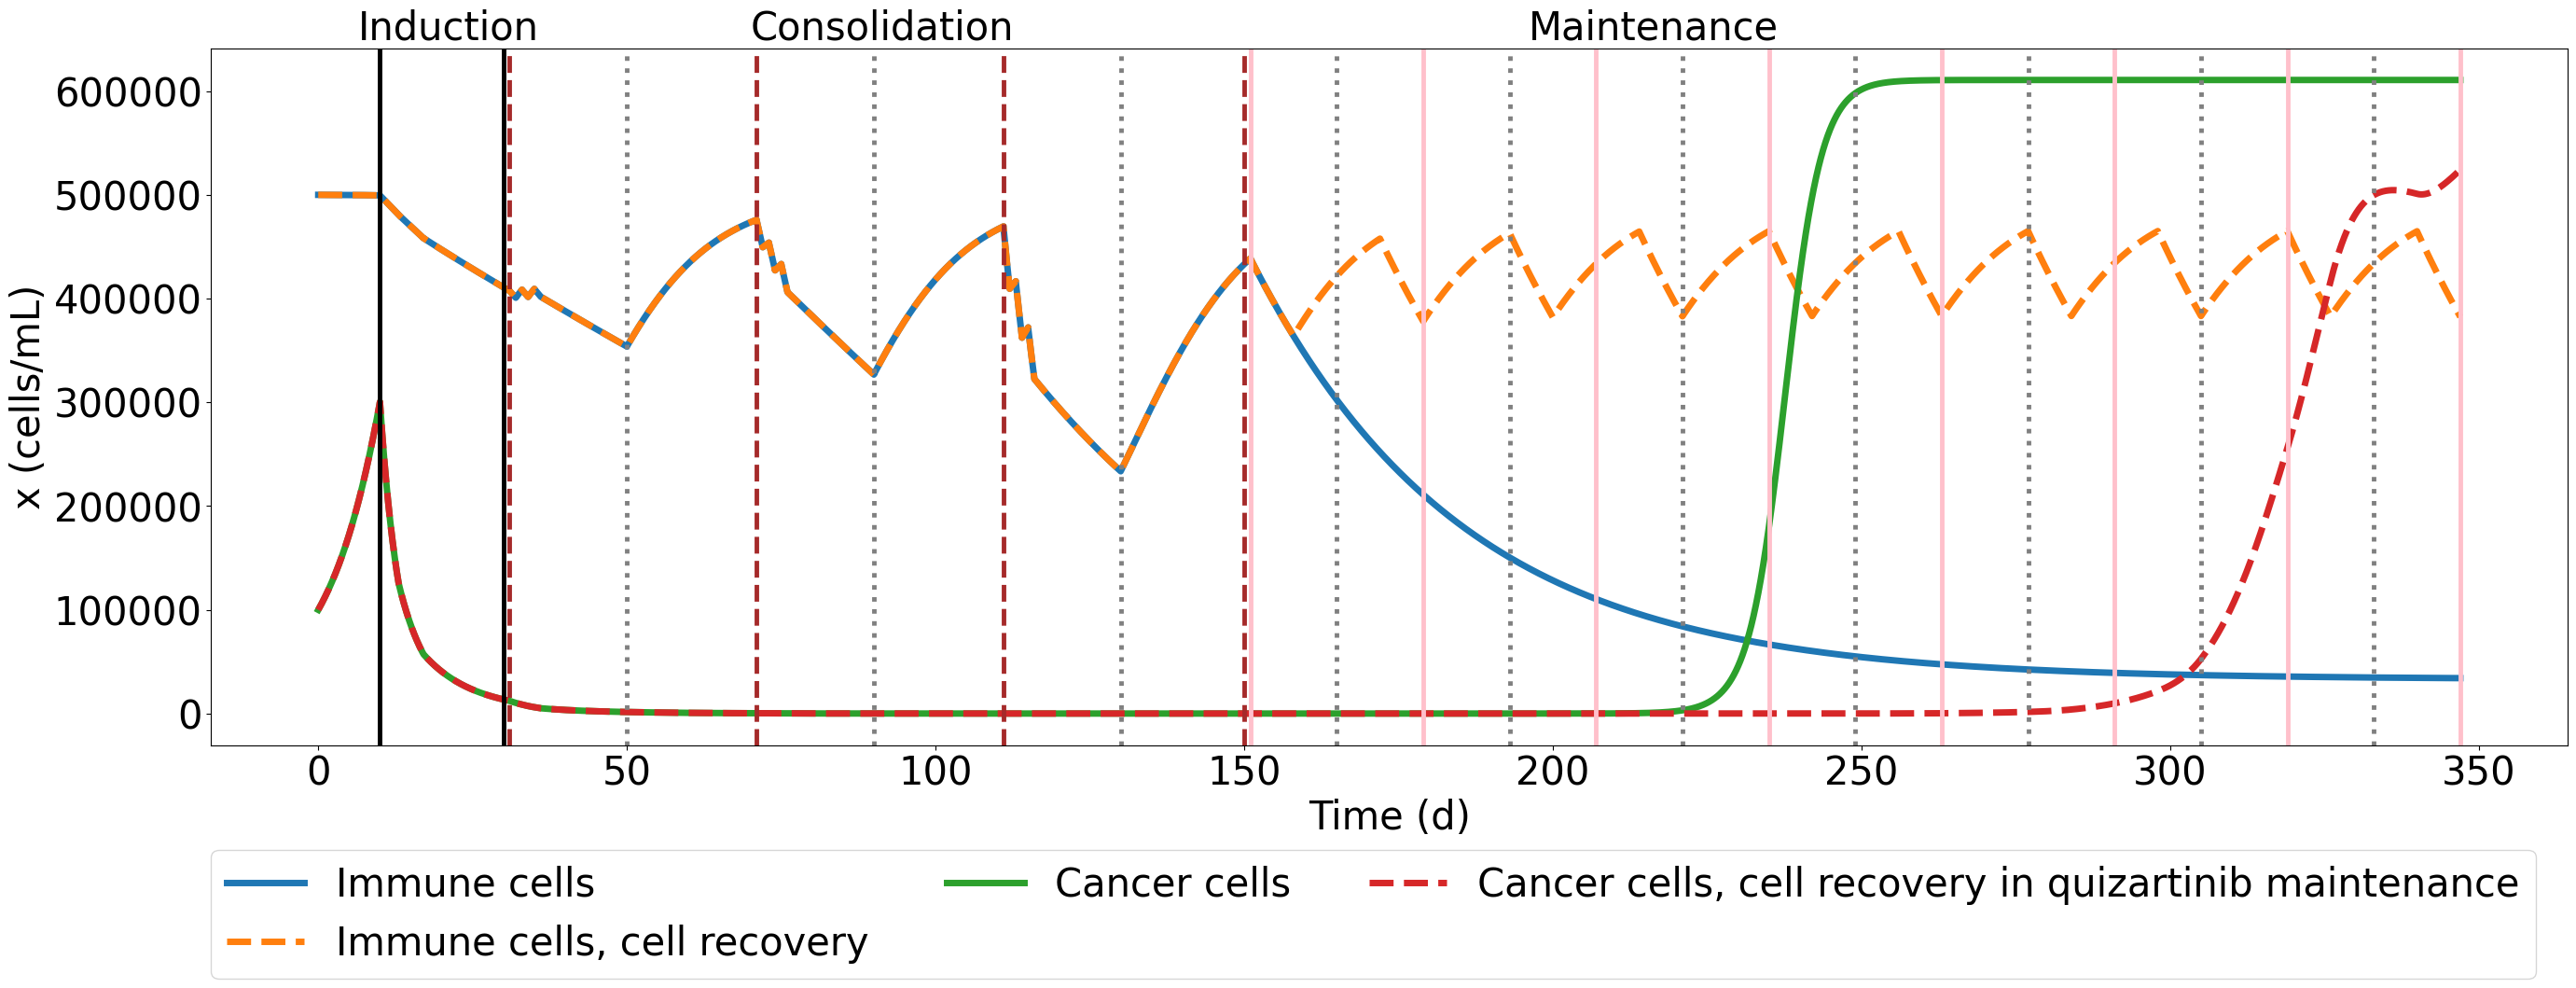

In [75]:
# Define treatment phases of normal cytarabine-quizartinib
# Each tuple contains 
# ('name of drug', duration of drug, death rate of drug, maximal death rate of immune cells due to drug, halflife of drug applied before cell recovery, 
# first letter of drug, whether or not treatment is currently applied (True if no treatment, False if not))
treatment_phases = [
    #Induction phase
    ('Cytarabine + Anthracycline', 3, mu_CAQ, d_max_CA, 0, 'C', False),
    ('Cytarabine', 4, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),

    #Consolidation
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 21, mu_Q, d, 42, 'Q', True),

    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 21, mu_Q, d, 42, 'Q', True),

    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 21, mu_Q, d, 42, 'Q', True),

    #Maintenance
    ('Quizartinib', 196, mu_Q, d_max_Q, 0, 'Q', False),
]

# Define treatment phases for cell recovery in between quizartinib administration
treatment_phases_cellRecovery = [
    #Induction phase
    ('Cytarabine + Anthracycline', 3, mu_CAQ, d_max_CA, 0, 'C', False),
    ('Cytarabine', 4, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),

    #Consolidation
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 21, mu_Q, d, 42, 'Q', True),

    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 21, mu_Q, d, 42, 'Q', True),

    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 21, mu_Q, d, 42, 'Q', True),

    #Maintenance
    ('Quizartinib', 7, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 14, mu_Q, d, 42, 'Q', True),
    ('Quizartinib', 7, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 14, mu_Q, d, 42, 'Q', True),
    ('Quizartinib', 7, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 14, mu_Q, d, 42, 'Q', True),
    ('Quizartinib', 7, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 14, mu_Q, d, 42, 'Q', True),
    ('Quizartinib', 7, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 14, mu_Q, d, 42, 'Q', True),
    ('Quizartinib', 7, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 14, mu_Q, d, 42, 'Q', True),
    ('Quizartinib', 7, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 14, mu_Q, d, 42, 'Q', True),
    ('Quizartinib', 7, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 14, mu_Q, d, 42, 'Q', True),
    ('Quizartinib', 7, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 14, mu_Q, d, 42, 'Q', True),
    ('Quizartinib', 7, mu_Q, d_max_Q, 0, 'Q', False),
]

# Collect list of populations for cytarabine-quizartinib treatment with continuous quizartinib administration in maintenance
t, t_after_treatment, density, immune, sensitive, resistant_A, resistant_V, resistant_Q, resistant_C, t_values = simulate_treatment(treatment_phases, daysBeforeTreatment, parameters, gI)
# Collect list of populations for cytarabine-quizartinib treatment with intermittent quizartinib administration in maintenance
t_q, _, popDensity_quizartinibChange, immune_q, _, _, _, _, _, _ = simulate_treatment(treatment_phases_cellRecovery, daysBeforeTreatment, parameters, gI)


# Plotting line for the start and end of a treatment phase
# Plot results
plt.figure(figsize=(30, 11.5))
plt.plot(t, immune, label='Immune cells', linewidth=5.0)
plt.plot(t_q, immune_q, label='Immune cells, cell recovery', linewidth=5.0, linestyle='dashed')
plt.plot(t, density, label='Cancer cells', linewidth=5.0)
plt.plot(t_q, popDensity_quizartinibChange, label='Cancer cells, cell recovery in quizartinib maintenance', linewidth=5.0, linestyle='dashed')

# Plotting headlines for each treatment phase
# Annotate treatment phases 
phase_labels = ['Induction', 'Consolidation', 'Maintenance']
phase_starts = [daysBeforeTreatment - 4.5,
                daysBeforeTreatment + 59,
                daysBeforeTreatment + 185]

# Set y-position slightly above max y-value
y_pos = max(max(density), max(immune_q), max(immune)) * 1.05

# Add labels just after each phase starts
for label, xpos in zip(phase_labels, phase_starts):
    plt.text(xpos + 1, y_pos, label, ha='left', va='bottom', fontsize=30)

# Plotting line for the start and end of a treatment phase
plt.axvline(daysBeforeTreatment, color='black', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 20, color='black', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 21, color = 'brown', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 40, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 61, color = 'brown', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 80, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 101, color = 'brown', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 120, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 140, color = 'brown', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 141, color = 'pink', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 155, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 169, color = 'pink', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 183, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 197, color = 'pink', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 211, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 225, color = 'pink', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 239, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 253, color = 'pink', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 267, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 281, color = 'pink', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 295, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 309, color = 'pink', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 323, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 337, color = 'pink', linewidth=3.5)

plt.xlabel('Time (d)')
plt.ylabel('x (cells/mL)')
plt.rcParams.update({'font.size': 30})
plt.legend(loc='upper left', bbox_to_anchor=(0, -0.15), ncol=3, borderaxespad=0, fontsize=30)
plt.tight_layout()
plt.savefig('QuzRecovery_7.pdf', format='pdf', bbox_inches='tight')
plt.show()

#### 14 day continous quizartinib before cell recovery lower value of $g_I$ and $\tau_{\mu}$ (Fig 4.3.2a)

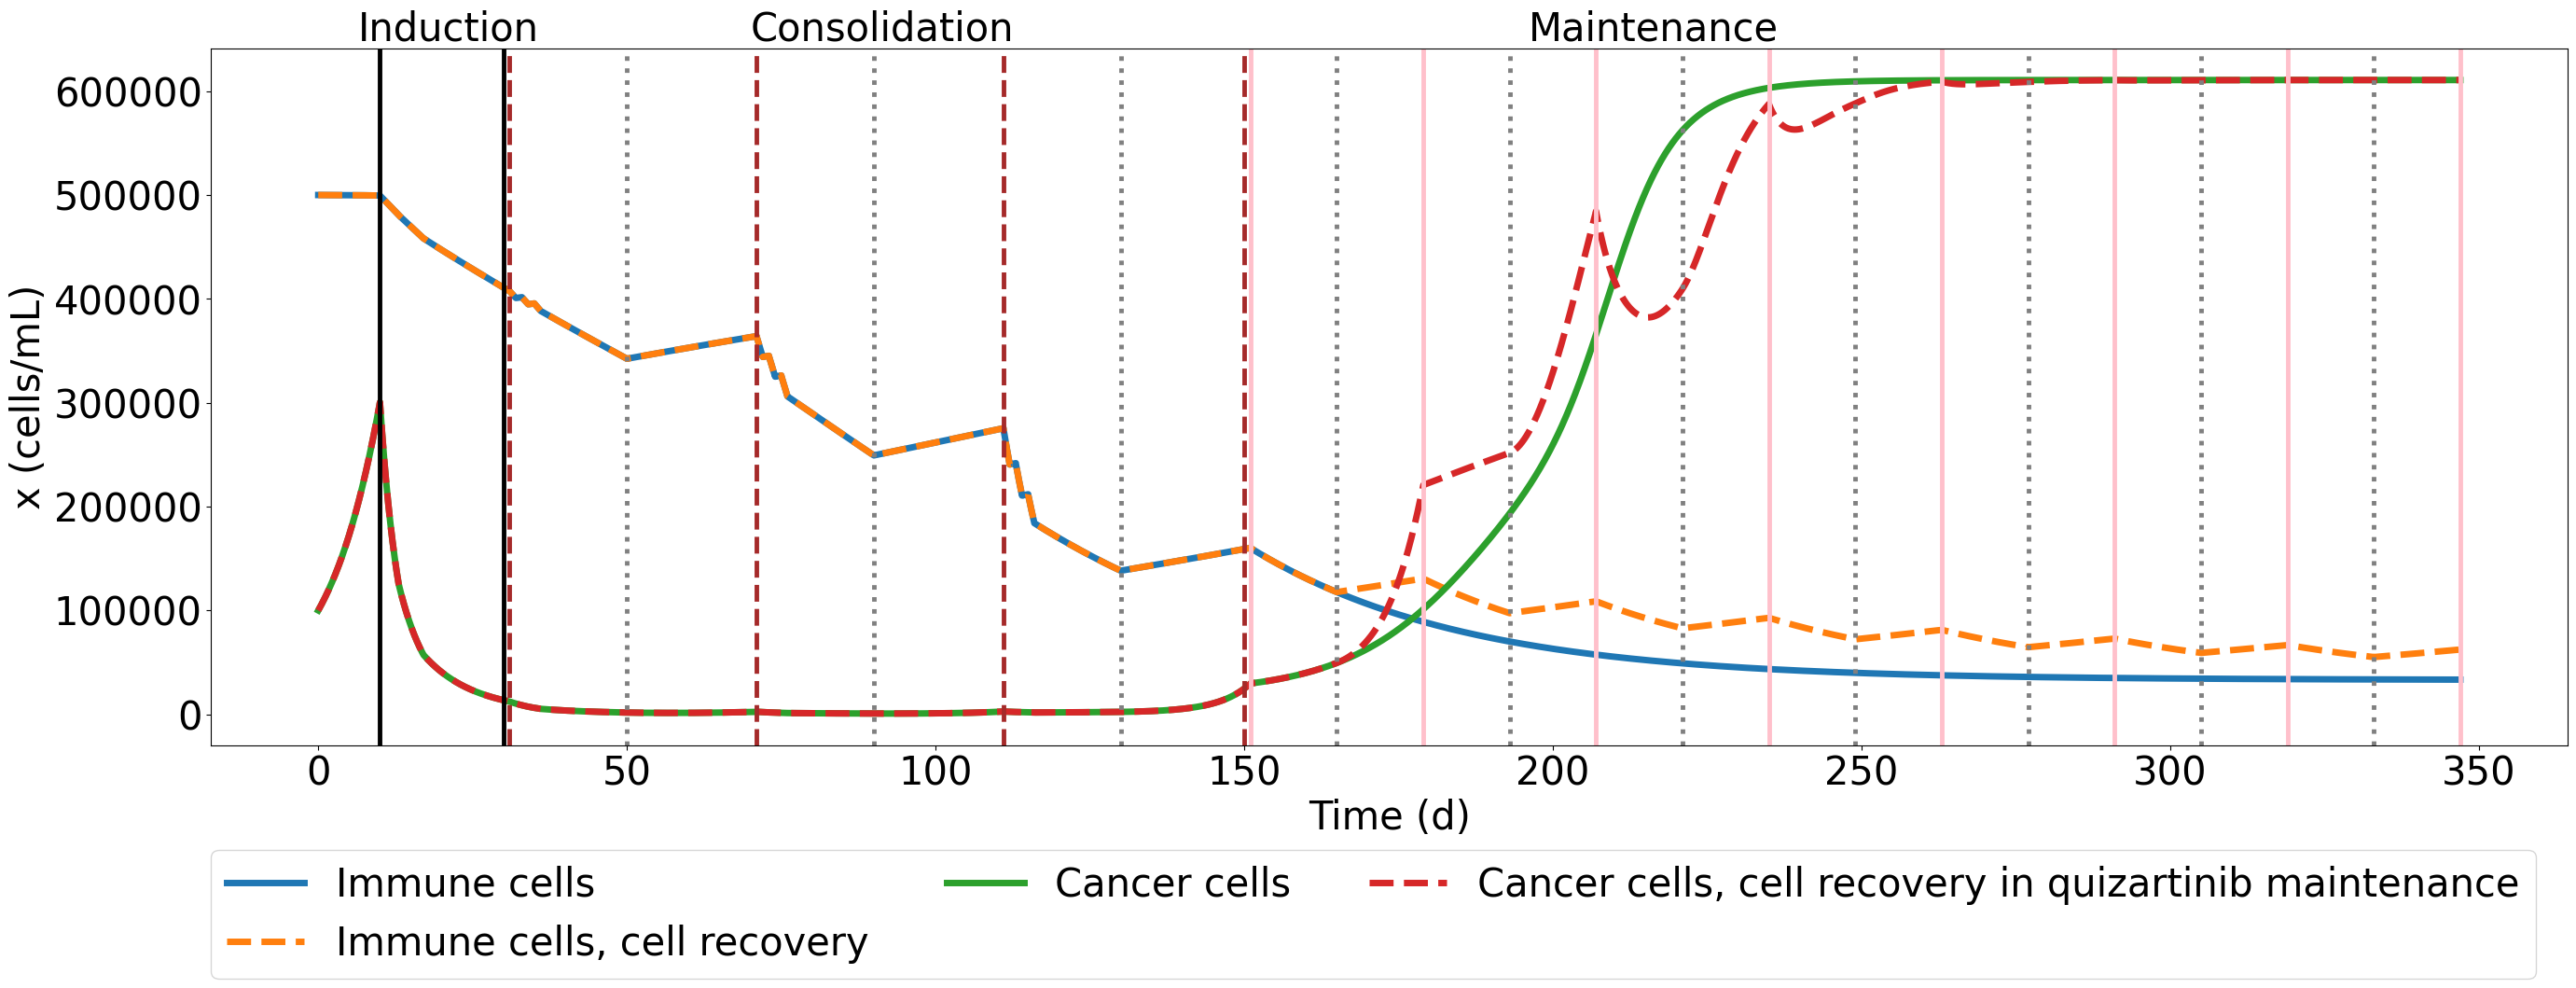

In [76]:
# Defining low value for gI
gI_low = 0.01

# Define treatment phases of normal cytarabine-quizartinib
# Each tuple contains 
# ('name of drug', duration of drug, death rate of drug, maximal death rate of immune cells due to drug, halflife of drug applied before cell recovery, 
# first letter of drug, whether or not treatment is currently applied (True if no treatment, False if not))
treatment_phases = [
    #Induction phase
    ('Cytarabine + Anthracycline', 3, mu_CAQ, d_max_CA, 0, 'C', False),
    ('Cytarabine', 4, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),

    #Consolidation
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 21, mu_Q, d, 14, 'Q', True),

    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 21, mu_Q, d, 14, 'Q', True),

    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 21, mu_Q, d, 14, 'Q', True),

    #Maintenance
    ('Quizartinib', 196, mu_Q, d_max_Q, 0, 'Q', False),
]

# Define treatment phases for cell recovery in between quizartinib administration
treatment_phases_cellRecovery = [
    #Induction phase
    ('Cytarabine + Anthracycline', 3, mu_CAQ, d_max_CA, 0, 'C', False),
    ('Cytarabine', 4, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),

    #Consolidation
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 21, mu_Q, d, 14, 'Q', True),

    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 21, mu_Q, d, 14, 'Q', True),

    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 21, mu_Q, d, 14, 'Q', True),

    #Maintenance
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 14, mu_Q, d, 14, 'Q', True),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 14, mu_Q, d, 14, 'Q', True),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 14, mu_Q, d, 14, 'Q', True),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 14, mu_Q, d, 14, 'Q', True),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 14, mu_Q, d, 14, 'Q', True),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 14, mu_Q, d, 14, 'Q', True),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 14, mu_Q, d, 14, 'Q', True),
]

# Collect list of populations for cytarabine-quizartinib treatment with continuous quizartinib administration in maintenance
t, t_after_treatment, density, immune, sensitive, resistant_A, resistant_V, resistant_Q, resistant_C, t_values = simulate_treatment(treatment_phases, daysBeforeTreatment, parameters, gI_low)
# Collect list of populations for cytarabine-quizartinib treatment with intermittent quizartinib administration in maintenance
t_q, _, popDensity_quizartinibChange, immune_q, _, _, _, _, _, _ = simulate_treatment(treatment_phases_cellRecovery, daysBeforeTreatment, parameters, gI_low)


# Plotting line for the start and end of a treatment phase
# Plot results
plt.figure(figsize=(30, 11.5))
plt.plot(t, immune, label='Immune cells', linewidth=5.0)
plt.plot(t_q, immune_q, label='Immune cells, cell recovery', linewidth=5.0, linestyle='dashed')
plt.plot(t, density, label='Cancer cells', linewidth=5.0)
plt.plot(t_q, popDensity_quizartinibChange, label='Cancer cells, cell recovery in quizartinib maintenance', linewidth=5.0, linestyle='dashed')

# Plotting headlines for each treatment phase
# Annotate treatment phases 
phase_labels = ['Induction', 'Consolidation', 'Maintenance']
phase_starts = [daysBeforeTreatment - 4.5,
                daysBeforeTreatment + 59,
                daysBeforeTreatment + 185]

# Set y-position slightly above max y-value
y_pos = max(max(density), max(immune_q), max(immune)) * 1.05

# Add labels just after each phase starts
for label, xpos in zip(phase_labels, phase_starts):
    plt.text(xpos + 1, y_pos, label, ha='left', va='bottom', fontsize=30)

# Plotting line for the start and end of a treatment phase
plt.axvline(daysBeforeTreatment, color='black', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 20, color='black', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 21, color = 'brown', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 40, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 61, color = 'brown', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 80, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 101, color = 'brown', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 120, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 140, color = 'brown', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 141, color = 'pink', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 155, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 169, color = 'pink', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 183, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 197, color = 'pink', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 211, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 225, color = 'pink', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 239, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 253, color = 'pink', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 267, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 281, color = 'pink', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 295, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 309, color = 'pink', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 323, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 337, color = 'pink', linewidth=3.5)

plt.xlabel('Time (d)')
plt.ylabel('x (cells/mL)')
plt.rcParams.update({'font.size': 30})
plt.legend(loc='upper left', bbox_to_anchor=(0, -0.15), ncol=3, borderaxespad=0, fontsize=30)
plt.tight_layout()
plt.savefig('QuzRecovery_14_low.pdf', format='pdf', bbox_inches='tight')
plt.show()

#### 7 day continous quizartinib before cell recovery lower value of $g_I$ and $\tau_{\mu}$ (Fig 4.3.2b)

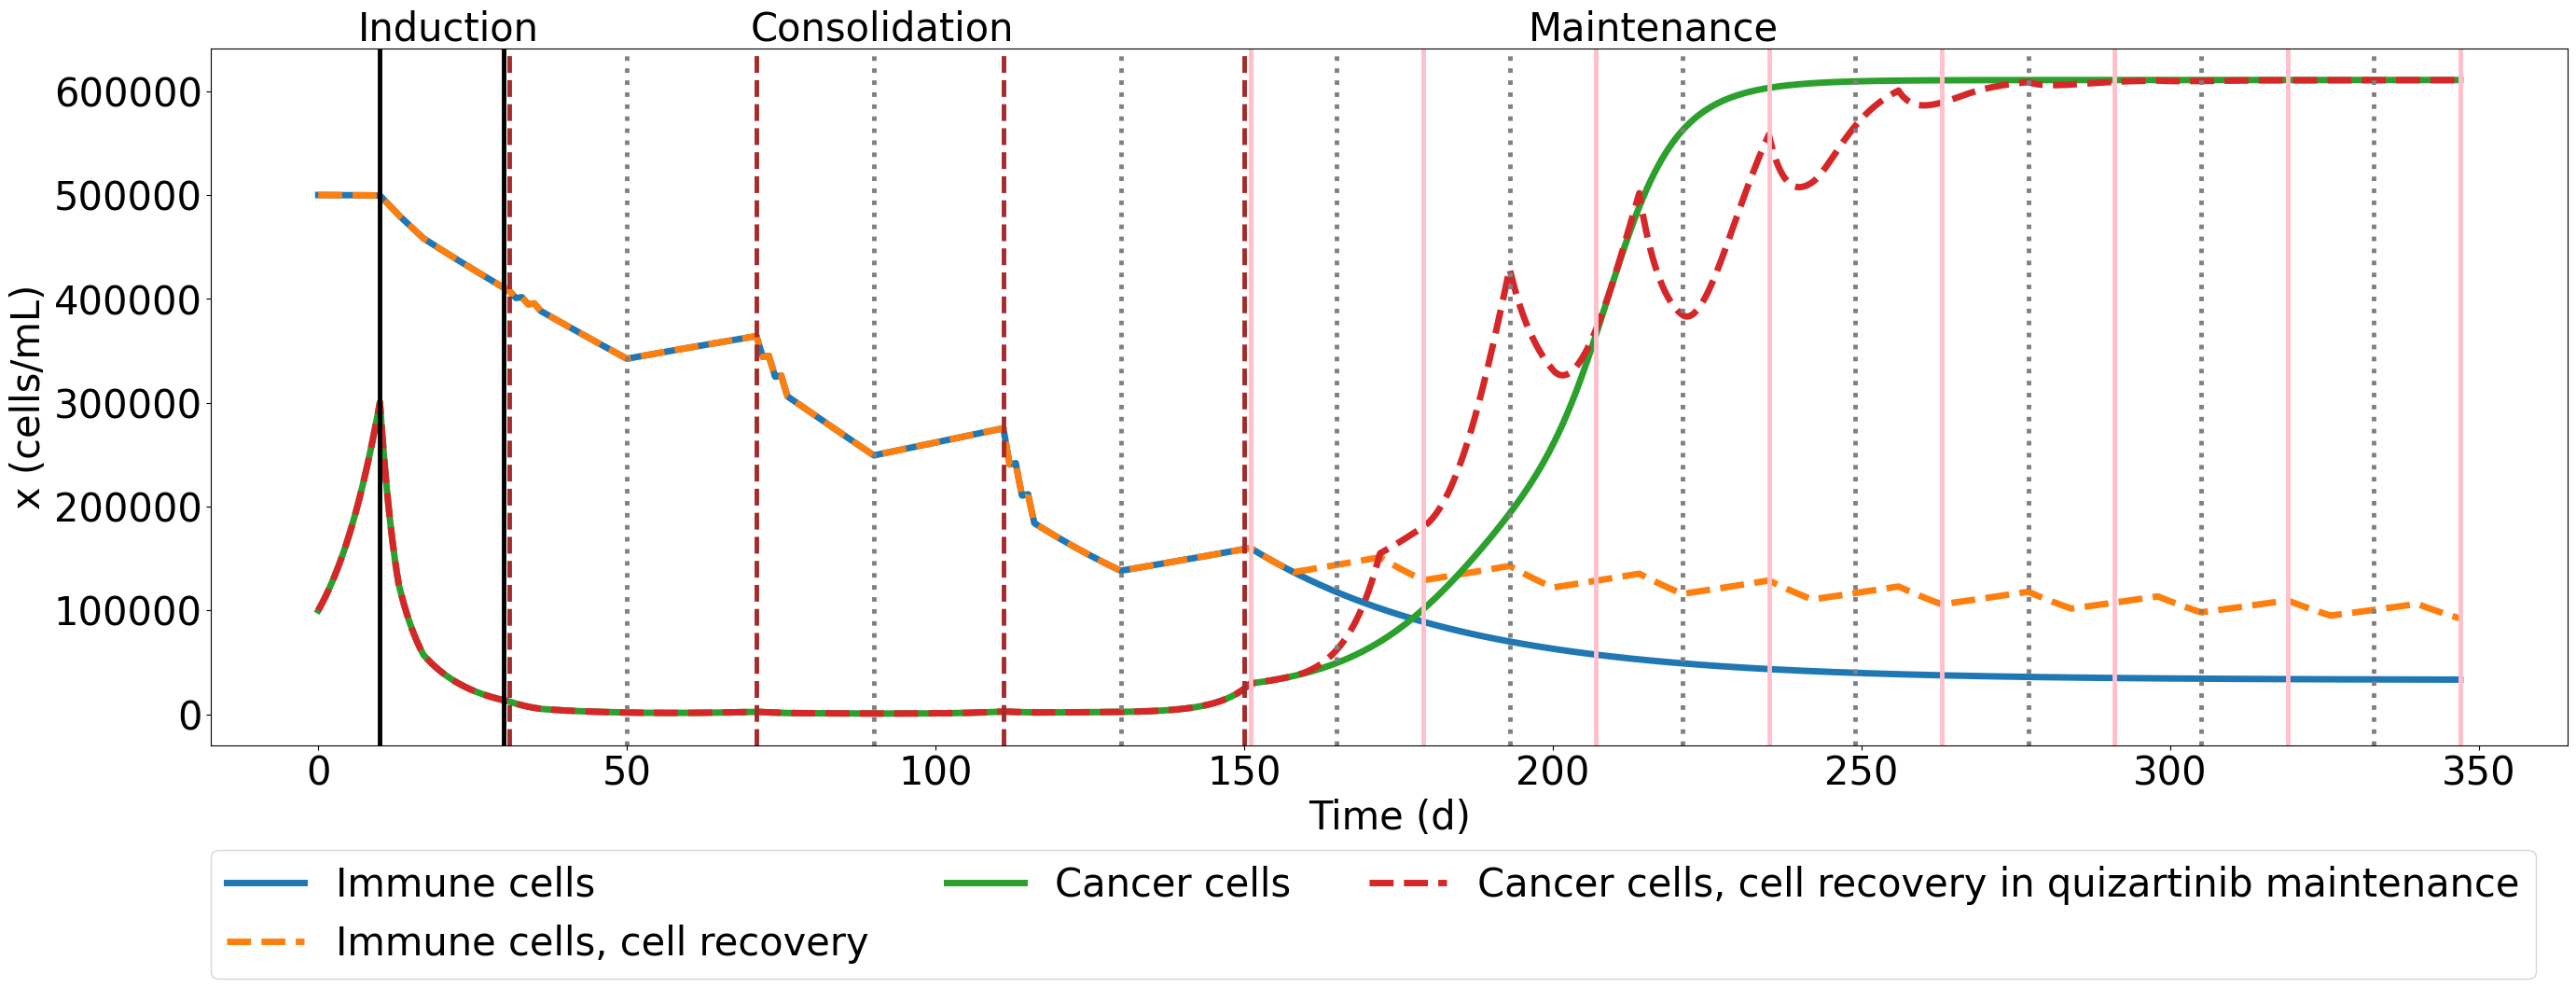

In [77]:
# Define treatment phases of normal cytarabine-quizartinib
# Each tuple contains 
# ('name of drug', duration of drug, death rate of drug, maximal death rate of immune cells due to drug, halflife of drug applied before cell recovery, 
# first letter of drug, whether or not treatment is currently applied (True if no treatment, False if not))
treatment_phases = [
    #Induction phase
    ('Cytarabine + Anthracycline', 3, mu_CAQ, d_max_CA, 0, 'C', False),
    ('Cytarabine', 4, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),

    #Consolidation
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 21, mu_Q, d, 14, 'Q', True),

    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 21, mu_Q, d, 14, 'Q', True),

    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 21, mu_Q, d, 14, 'Q', True),

    #Maintenance
    ('Quizartinib', 196, mu_Q, d_max_Q, 0, 'Q', False),
]

# Define treatment phases for cell recovery in between quizartinib administration
treatment_phases_cellRecovery = [
    #Induction phase
    ('Cytarabine + Anthracycline', 3, mu_CAQ, d_max_CA, 0, 'C', False),
    ('Cytarabine', 4, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),

    #Consolidation
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 21, mu_Q, d, 14, 'Q', True),

    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 21, mu_Q, d, 14, 'Q', True),

    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 21, mu_Q, d, 14, 'Q', True),

    #Maintenance
    ('Quizartinib', 7, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 14, mu_Q, d, 14, 'Q', True),
    ('Quizartinib', 7, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 14, mu_Q, d, 14, 'Q', True),
    ('Quizartinib', 7, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 14, mu_Q, d, 14, 'Q', True),
    ('Quizartinib', 7, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 14, mu_Q, d, 14, 'Q', True),
    ('Quizartinib', 7, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 14, mu_Q, d, 14, 'Q', True),
    ('Quizartinib', 7, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 14, mu_Q, d, 14, 'Q', True),
    ('Quizartinib', 7, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 14, mu_Q, d, 14, 'Q', True),
    ('Quizartinib', 7, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 14, mu_Q, d, 14, 'Q', True),
    ('Quizartinib', 7, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 14, mu_Q, d, 14, 'Q', True),
    ('Quizartinib', 7, mu_Q, d_max_Q, 0, 'Q', False),
]

# Collect list of populations for cytarabine-quizartinib treatment with continuous quizartinib administration in maintenance
t, t_after_treatment, density, immune, sensitive, resistant_A, resistant_V, resistant_Q, resistant_C, t_values = simulate_treatment(treatment_phases, daysBeforeTreatment, parameters, gI_low)
# Collect list of populations for cytarabine-quizartinib treatment with intermittent quizartinib administration in maintenance
t_q, _, popDensity_quizartinibChange, immune_q, _, _, _, _, _, _ = simulate_treatment(treatment_phases_cellRecovery, daysBeforeTreatment, parameters, gI_low)


# Plotting line for the start and end of a treatment phase
# Plot results
plt.figure(figsize=(30, 11.5))
plt.plot(t, immune, label='Immune cells', linewidth=5.0)
plt.plot(t_q, immune_q, label='Immune cells, cell recovery', linewidth=5.0, linestyle='dashed')
plt.plot(t, density, label='Cancer cells', linewidth=5.0)
plt.plot(t_q, popDensity_quizartinibChange, label='Cancer cells, cell recovery in quizartinib maintenance', linewidth=5.0, linestyle='dashed')

# Plotting headlines for each treatment phase
# Annotate treatment phases 
phase_labels = ['Induction', 'Consolidation', 'Maintenance']
phase_starts = [daysBeforeTreatment - 4.5,
                daysBeforeTreatment + 59,
                daysBeforeTreatment + 185]

# Set y-position slightly above max y-value
y_pos = max(max(density), max(immune_q), max(immune)) * 1.05

# Add labels just after each phase starts
for label, xpos in zip(phase_labels, phase_starts):
    plt.text(xpos + 1, y_pos, label, ha='left', va='bottom', fontsize=30)

# Plotting line for the start and end of a treatment phase
plt.axvline(daysBeforeTreatment, color='black', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 20, color='black', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 21, color = 'brown', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 40, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 61, color = 'brown', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 80, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 101, color = 'brown', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 120, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 140, color = 'brown', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 141, color = 'pink', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 155, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 169, color = 'pink', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 183, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 197, color = 'pink', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 211, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 225, color = 'pink', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 239, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 253, color = 'pink', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 267, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 281, color = 'pink', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 295, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 309, color = 'pink', linewidth=3.5)
plt.axvline(daysBeforeTreatment + 323, color = 'gray', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 337, color = 'pink', linewidth=3.5)

plt.xlabel('Time (d)')
plt.ylabel('x (cells/mL)')
plt.rcParams.update({'font.size': 30})
plt.legend(loc='upper left', bbox_to_anchor=(0, -0.15), ncol=3, borderaxespad=0, fontsize=30)
plt.tight_layout()
plt.savefig('QuzRecovery_7_low.pdf', format='pdf', bbox_inches='tight')
plt.show()

### Combining venetoclax with cytarabine and anthracycline (Fig 4.3.3)

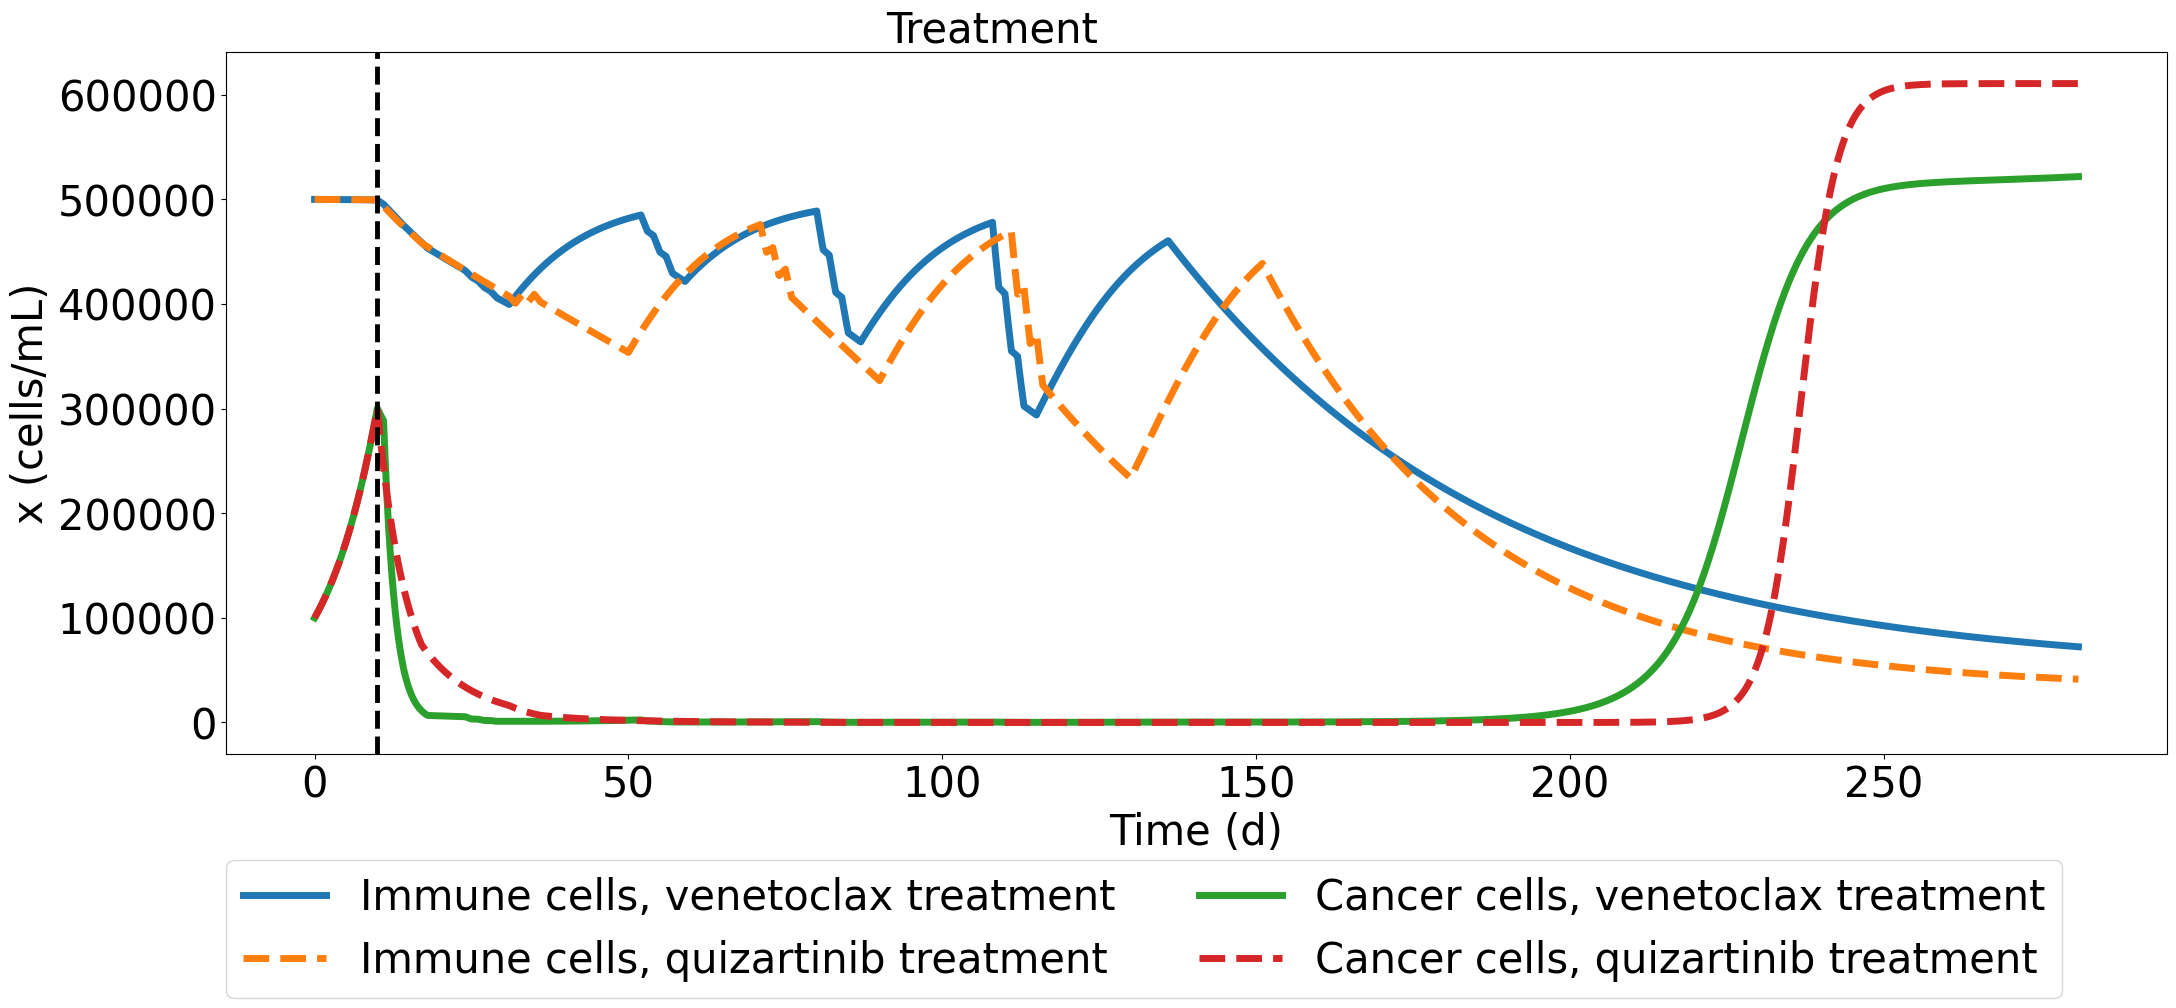

In [78]:
# Define death rates for cancer cells and maximal death rate for immune cells for the treatment combination
mu_CAV = 0.332
mu_CV = 0.327 
d_max_CAV = d_max_CA + 0.01
d_max_CV = d_max_C + 0.01

# Define treatment phases of cytarabine-venetoclax treatment
# Each tuple contains 
# ('name of drug', duration of drug, death rate of drug, maximal death rate of immune cells due to drug, halflife of drug applied before cell recovery, 
# first letter of drug, whether or not treatment is currently applied (True if no treatment, False if not))
treatment_phases = [
    #Induction phase
    ('Venetoclax', 1, mu_V, d_max_V, 0, 'V', False),
    ('Cytarabine + Anthracycline + Venetoclax', 3, mu_CAV, d_max_CAV, 0, 'CV', False),
    ('Cytarabine + Venetoclax', 4, mu_CV, d_max_CV, 0, 'CV', False),
    ('Venetoclax', 6, mu_V, d_max_V, 0, 'V', False),


    #Consolidation
    ('Cytarabine + Venetoclax', 1, mu_CV, d_max_CV, 0, 'CV', False),
    ('Venetoclax', 1, mu_V, d_max_V, 0, 'V', False),
    ('Cytarabine + Venetoclax', 1, mu_CV, d_max_CV, 0, 'CV', False),
    ('Venetoclax', 1, mu_V, d_max_V, 0, 'V', False),
    ('Cytarabine + Venetoclax', 1, mu_CV, d_max_CV, 0, 'CV', False),
    ('Venetoclax', 2, mu_V, d_max_V, 0, 'V', False),
    ('Cell recovery', 21, mu_V, d, 10, 'V', True),

    ('Cytarabine + Venetoclax', 1, mu_CV, d_max_CV, 0, 'CV', False),
    ('Venetoclax', 1, mu_V, d_max_V, 0, 'V', False),
    ('Cytarabine + Venetoclax', 1, mu_CV, d_max_CV, 0, 'CV', False),
    ('Venetoclax', 1, mu_V, d_max_V, 0, 'V', False),
    ('Cytarabine + Venetoclax', 1, mu_CV, d_max_CV, 0, 'CV', False),
    ('Venetoclax', 2, mu_V, d_max_V, 0, 'V', False),
    ('Cell recovery', 21, mu_V, d, 10, 'V', True),

    ('Cytarabine + Venetoclax', 1, mu_CV, d_max_CV, 0, 'CV', False),
    ('Venetoclax', 1, mu_V, d_max_V, 0, 'V', False),
    ('Cytarabine + Venetoclax', 1, mu_CV, d_max_CV, 0, 'CV', False),
    ('Venetoclax', 1, mu_V, d_max_V, 0, 'V', False),
    ('Cytarabine + Venetoclax', 1, mu_CV, d_max_CV, 0, 'CV', False),
    ('Venetoclax', 2, mu_V, d_max_V, 0, 'V', False),
    ('Cell recovery', 21, mu_V, d, 10, 'V', True),

    ('Cytarabine + Venetoclax', 1, mu_CV, d_max_CV, 0, 'CV', False),
    ('Venetoclax', 1, mu_V, d_max_V, 0, 'V', False),
    ('Cytarabine + Venetoclax', 1, mu_CV, d_max_CV, 0, 'CV', False),
    ('Venetoclax', 1, mu_V, d_max_V, 0, 'V', False),
    ('Cytarabine + Venetoclax', 1, mu_CV, d_max_CV, 0, 'CV', False),
    ('Venetoclax', 2, mu_V, d_max_V, 0, 'V', False),
    ('Cell recovery', 21, mu_V, d, 10, 'V', True),

    #Maintenance
    ('Venetoclax', 145, mu_V, d_max_V, 0, 'V', False),
]

# Define treatment phases for cytarabine-quizartinib treatment to compare to the venetoclax one
treatment_phases_quantum  = [
    #Induction phase
    ('Cytarabine + Anthracycline', 3, mu_CA, d_max_CA, 0, 'C', False),
    ('Cytarabine', 4, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),

    #Consolidation
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 21, mu_Q, d, 42, 'Q', True),

    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 21, mu_Q, d, 42, 'Q', True),

    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 1, mu_C, d, 14, 'C', True),
    ('Cytarabine', 1, mu_C, d_max_C, 0, 'C', False),
    ('Quizartinib', 14, mu_Q, d_max_Q, 0, 'Q', False),
    ('Cell recovery', 21, mu_Q, d, 42, 'Q', True),

    #Maintenance
    ('Quizartinib', 130, mu_Q, d_max_Q, 0, 'Q', False),
]

# Collect list of populations for cytarabine-venetoclax treatment 
t, t_after_treatment, density, immune, sensitive, resistant_A, resistant_V, resistant_Q, resistant_C, t_values = simulate_treatment(treatment_phases, daysBeforeTreatment, parameters, gI)
# Collect list of populations for cytarabine-quizartinib treatment
t_quantum, _, density_quantum, immune_quantum, _, _, _, _, _, _ = simulate_treatment(treatment_phases_quantum, daysBeforeTreatment, parameters, gI)

# Plot results
plt.figure(figsize=(23, 11))
plt.plot(t, immune, label='Immune cells, venetoclax treatment', linewidth=5.0)
plt.plot(t_quantum, immune_quantum, label = 'Immune cells, quizartinib treatment', linewidth=5.0, linestyle='dashed')
plt.plot(t, density, label='Cancer cells, venetoclax treatment', linewidth=5.0)
plt.plot(t_quantum, density_quantum, label='Cancer cells, quizartinib treatment', linewidth=5.0, linestyle='dashed')

# Plotting headlines for each treatment phase
# Annotate treatment phases 
phase_labels = [ 'Treatment']
phase_starts = [daysBeforeTreatment + 80]

# Set y-position slightly above max y-value
y_pos = max(density_quantum) * 1.05

# Add labels just after each phase starts
for label, xpos in zip(phase_labels, phase_starts):
    plt.text(xpos + 1, y_pos, label, ha='left', va='bottom', fontsize=30)

# Plotting line for the start of treatment. Since the protocols are different for the two regimens, we only mark the start of treatment.
plt.axvline(daysBeforeTreatment, color='black', linestyle='dashed', linewidth=3.5)

plt.xlabel('Time (d)')
plt.ylabel('x (cells/mL)')
plt.rcParams.update({'font.size': 30})
plt.legend(loc='upper left', bbox_to_anchor=(0, -0.15), ncol=2, borderaxespad=0, fontsize=30)
plt.tight_layout()
plt.savefig('Venetoclax7+3.pdf', format='pdf', bbox_inches='tight')
plt.show()

### Simulating chemotherapy regimens with reduced toxicity 

#### Continuous dosing of azacitidine with reduced toxicity (Fig 4.3.4a)

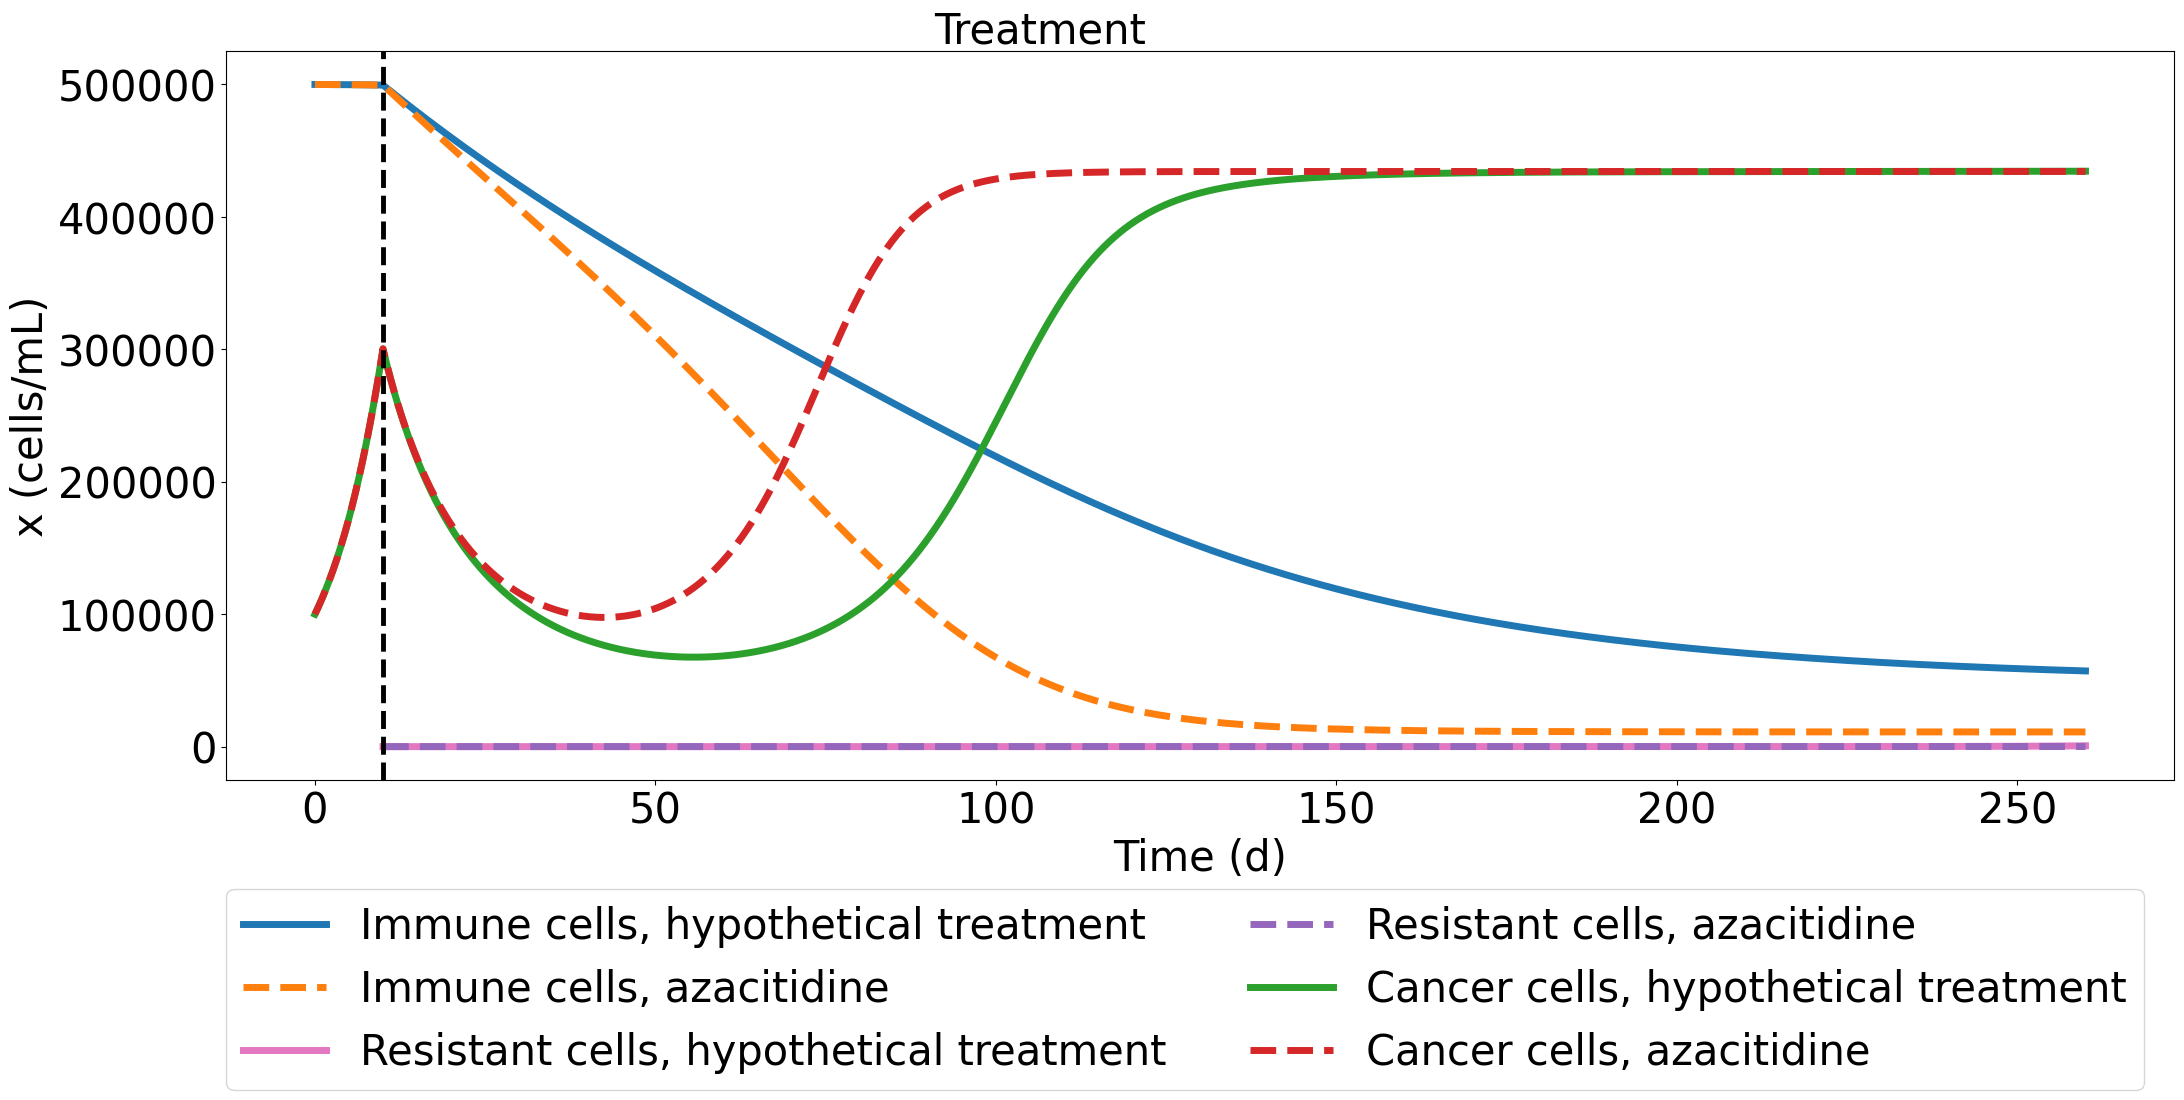

In [79]:
# Define treatment phases of azacitidine treatment with reduced toxicity
# Each tuple contains 
# ('name of drug', duration of drug, death rate of drug, maximal death rate of immune cells due to drug, halflife of drug applied before cell recovery, 
# first letter of drug, whether or not treatment is currently applied (True if no treatment, False if not))
treatment_phases_opt = [
    ('Drug', 250, mu_A, d_max_V, 0, 'A', False),
]
# Define treatment phases of azacitidine treatment with normal toxicity
treatment_phases = [
    ('Drug', 250, mu_A, d_max_A, 0, 'A', False),
]

# Collect list of populations for azacitidine treatment with reduced toxicity
t, t_after_treatment, density, immune, sensitive, resistant_A, resistant_V, resistant_Q, resistant_C, t_values = simulate_treatment(treatment_phases_opt, daysBeforeTreatment, parameters, gI)
# Collect list of populations for azacitidine treatment with normal toxicity
t_real, t_after_real, density_real, immune_real, _, res_A_real, _, _, _, _ = simulate_treatment(treatment_phases, daysBeforeTreatment, parameters, gI)

# Plot results
plt.figure(figsize=(23.5, 12))
plt.plot(t, immune, label='Immune cells, hypothetical treatment', linewidth=5.0)
plt.plot(t_real, immune_real, label='Immune cells, azacitidine', linewidth=5.0, linestyle='dashed')
plt.plot(t_after_treatment, resistant_A, label='Resistant cells, hypothetical treatment', linewidth=5.0, color='tab:pink')
plt.plot(t_after_real, res_A_real, label='Resistant cells, azacitidine', linewidth=5.0, linestyle='dashed', color='tab:purple')
plt.plot(t, density, label='Cancer cells, hypothetical treatment', linewidth=5.0, color='tab:green')
plt.plot(t_real, density_real, label='Cancer cells, azacitidine', linewidth=5.0, linestyle='dashed', color='tab:red')

# Plotting headlines for each treatment phase
# Annotate treatment phases 
phase_labels = ['Treatment']
phase_starts = [daysBeforeTreatment + 80]

# Set y-position slightly above max y-value
y_pos = max(immune) * 1.05

# Add labels just after each phase starts
for label, xpos in zip(phase_labels, phase_starts):
    plt.text(xpos + 1, y_pos, label, ha='left', va='bottom', fontsize=30)

# Plotting vertical line for the start of treatment
plt.axvline(daysBeforeTreatment, color='black', linestyle='dashed', linewidth=3.5)

plt.xlabel('Time (d)')
plt.ylabel('x (cells/mL)')
plt.rcParams.update({'font.size': 30})
plt.legend(loc='upper left', bbox_to_anchor=(0, -0.15), ncol=2, borderaxespad=0, fontsize=30)
plt.tight_layout()
plt.savefig('AzacitidineVenetoclax_noRecovery.pdf', format='pdf', bbox_inches='tight')
plt.show()

#### Continuous dosing of cytarabine with reduced toxicity (Fig 4.3.4b)

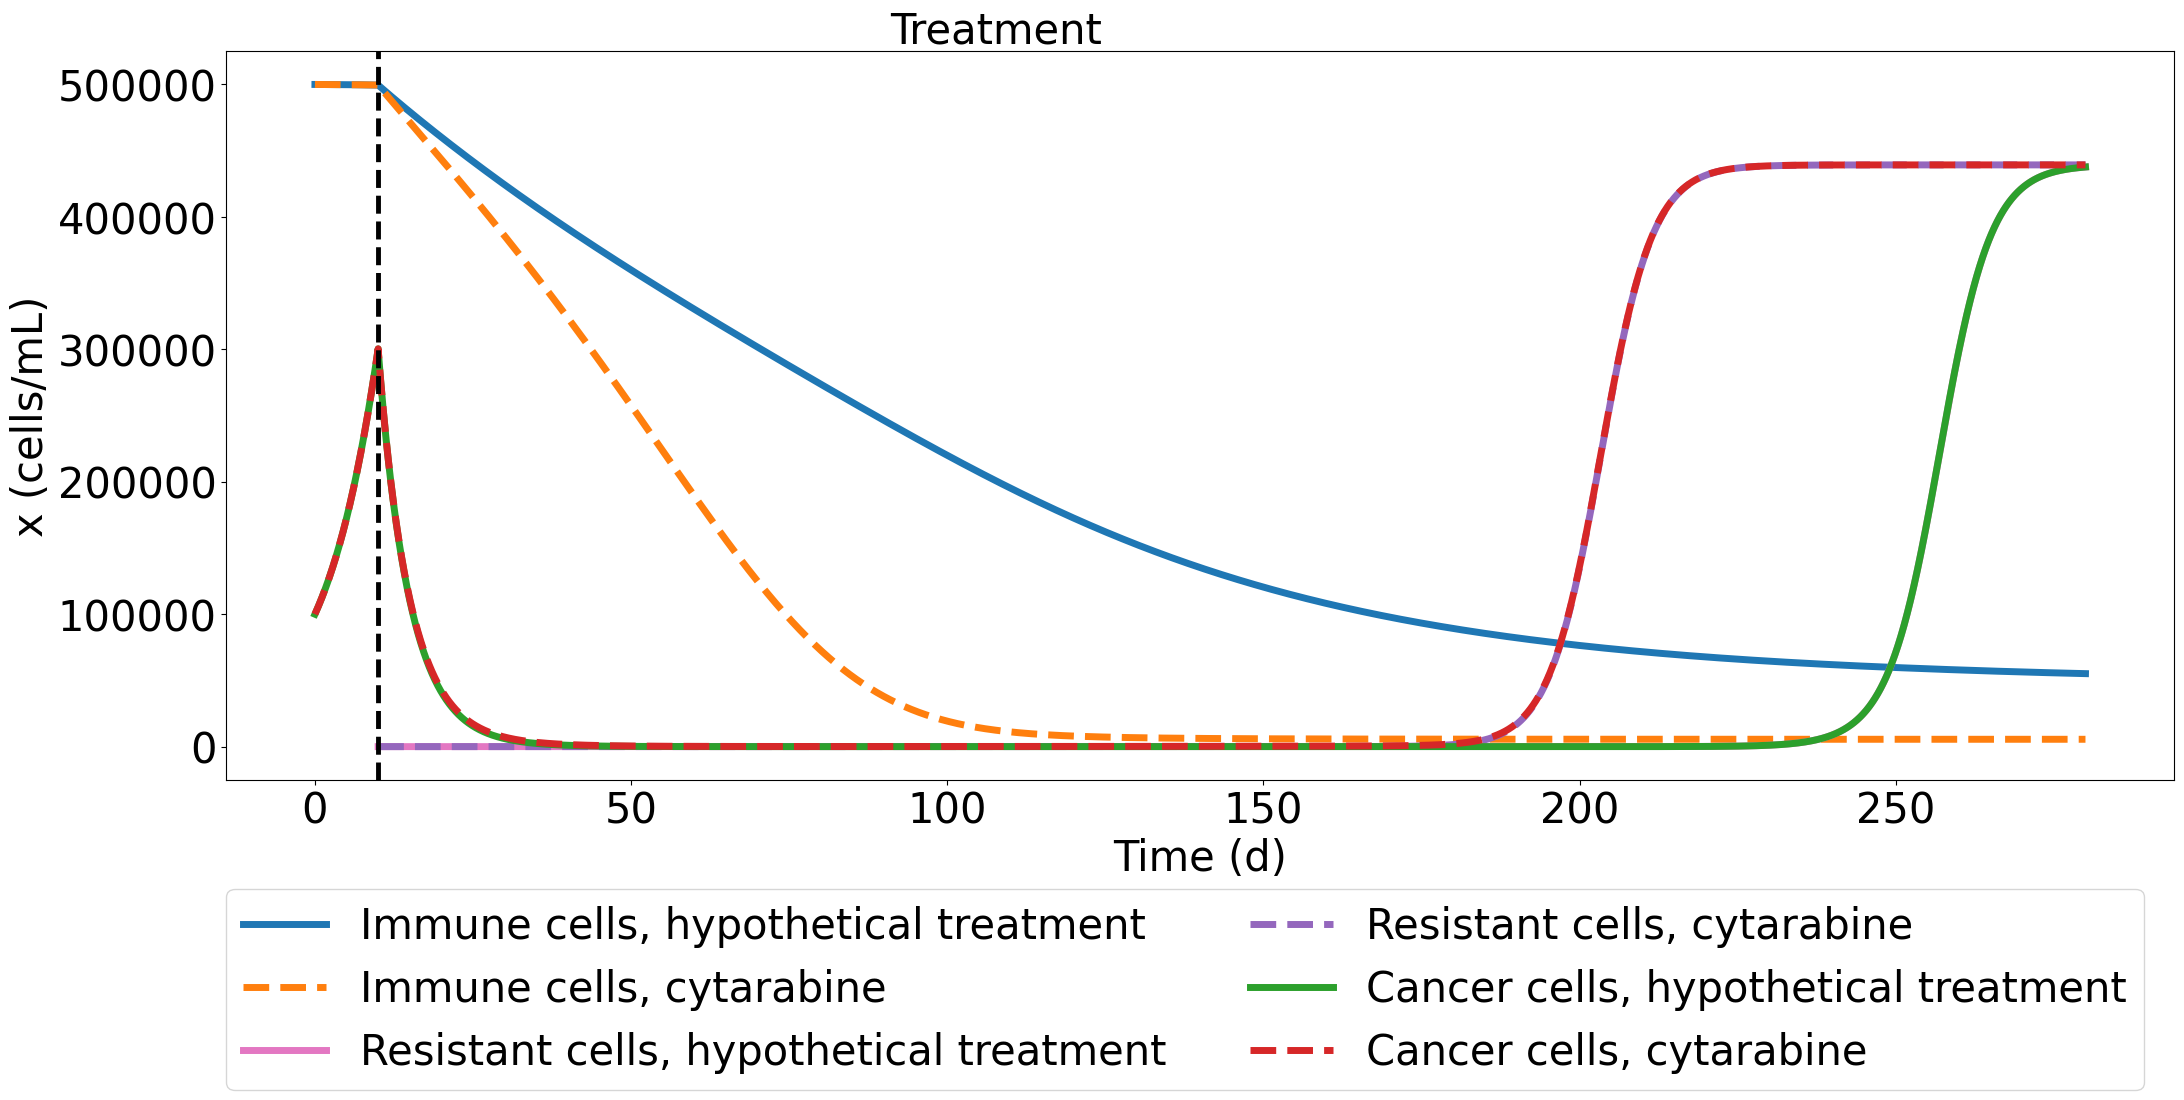

In [80]:
# Define treatment phases of cytarabine treatment with reduced toxicity
# Each tuple contains 
# ('name of drug', duration of drug, death rate of drug, maximal death rate of immune cells due to drug, halflife of drug applied before cell recovery, 
# first letter of drug, whether or not treatment is currently applied (True if no treatment, False if not))
treatment_phases_opt = [
    ('Drug', 270, mu_C, d_max_V, 0, 'C', False),
]
# Define treatment phases of cytarabine treatment with normal toxicity
treatment_phases = [
    ('Drug', 270, mu_C, d_max_C, 0, 'C', False),
]

# Collect list of populations for cytarabine treatment with reduced toxicity
t, t_after_treatment, density, immune, sensitive, resistant_A, resistant_V, resistant_Q, resistant_C, t_values = simulate_treatment(treatment_phases_opt, daysBeforeTreatment, parameters, gI)
# Collect list of populations for cytarabine treatment with normal toxicity
t_real, t_after_real, density_real, immune_real, _, _, _, _, res_C_real, _ = simulate_treatment(treatment_phases, daysBeforeTreatment, parameters, gI)

# Plot results
plt.figure(figsize=(23.5, 12))
plt.plot(t, immune, label='Immune cells, hypothetical treatment', linewidth=5.0)
plt.plot(t_real, immune_real, label='Immune cells, cytarabine', linewidth=5.0, linestyle='dashed')
plt.plot(t_after_treatment, resistant_C, label='Resistant cells, hypothetical treatment', linewidth=5.0, color='tab:pink')
plt.plot(t_after_real, res_C_real, label='Resistant cells, cytarabine', linewidth=5.0, linestyle='dashed', color='tab:purple')
plt.plot(t, density, label='Cancer cells, hypothetical treatment', linewidth=5.0, color='tab:green')
plt.plot(t_real, density_real, label='Cancer cells, cytarabine', linewidth=5.0, linestyle='dashed', color='tab:red')

# Plotting headlines for each treatment phase
# Annotate treatment phases 
phase_labels = ['Treatment']
phase_starts = [daysBeforeTreatment + 80]

# Set y-position slightly above max y-value
y_pos = max(immune) * 1.05

# Add labels just after each phase starts
for label, xpos in zip(phase_labels, phase_starts):
    plt.text(xpos + 1, y_pos, label, ha='left', va='bottom', fontsize=30)

# Plotting vertical line for the start of treatment
plt.axvline(daysBeforeTreatment, color='black', linestyle='dashed', linewidth=3.5)

plt.xlabel('Time (d)')
plt.ylabel('x (cells/mL)')
plt.rcParams.update({'font.size': 30})
plt.legend(loc='upper left', bbox_to_anchor=(0, -0.15), ncol=2, borderaxespad=0, fontsize=30)
plt.tight_layout()
plt.savefig('CytarabineVenetoclax_noRecovery.pdf', format='pdf', bbox_inches='tight')
plt.show()

#### Cyclic dosing of azacitidine with reduced toxicity (Fig 4.3.5a)

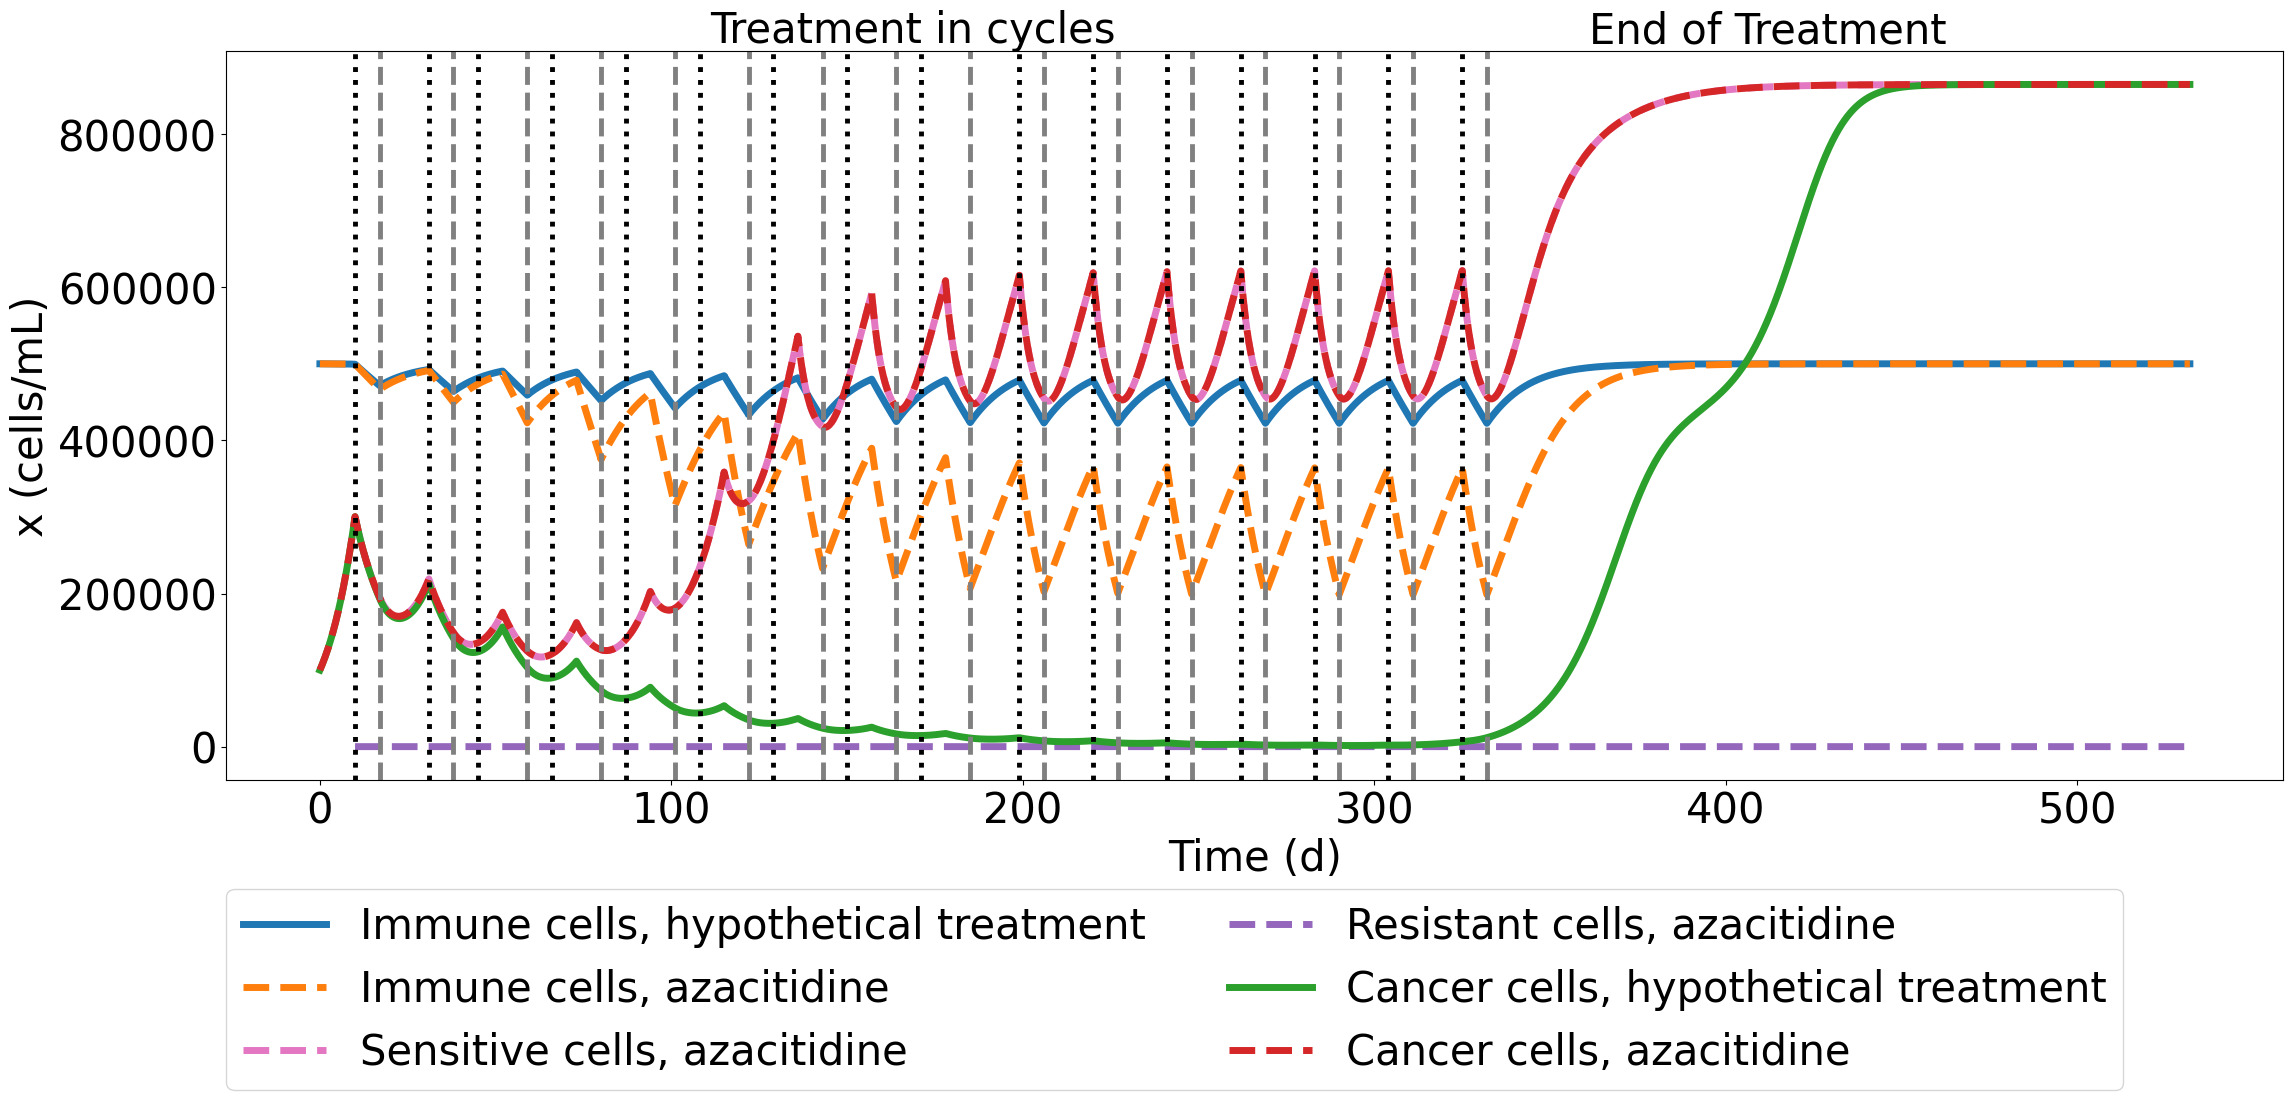

In [81]:
# Define treatment phases of azacitidine treatment with reduced toxicity
# Each tuple contains 
# ('name of drug', duration of drug, death rate of drug, maximal death rate of immune cells due to drug, halflife of drug applied before cell recovery, 
# first letter of drug, whether or not treatment is currently applied (True if no treatment, False if not))
treatment_phases_opt = [
    ('Drug', 7, mu_A, d_max_V, 0, 'A', False),
    ('Cell recovery', 14, mu_A, d, 10, 'A', True),

    ('Drug', 7, mu_A, d_max_V, 0, 'A', False),
    ('Cell recovery', 14, mu_A, d, 10, 'A', True),

    ('Drug', 7, mu_A, d_max_V, 0, 'A', False),
    ('Cell recovery', 14, mu_A, d, 10, 'A', True),

    ('Drug', 7, mu_A, d_max_V, 0, 'A', False),
    ('Cell recovery', 14, mu_A, d, 10, 'A', True),

    ('Drug', 7, mu_A, d_max_V, 0, 'A', False),
    ('Cell recovery', 14, mu_A, d, 10, 'A', True),

    ('Drug', 7, mu_A, d_max_V, 0, 'A', False),
    ('Cell recovery', 14, mu_A, d, 10, 'A', True),

    ('Drug', 7, mu_A, d_max_V, 0, 'A', False),
    ('Cell recovery', 14, mu_A, d, 10, 'A', True),

    ('Drug', 7, mu_A, d_max_V, 0, 'A', False),
    ('Cell recovery', 14, mu_A, d, 10, 'A', True),

    ('Drug', 7, mu_A, d_max_V, 0, 'A', False),
    ('Cell recovery', 14, mu_A, d, 10, 'A', True),

    ('Drug', 7, mu_A, d_max_V, 0, 'A', False),
    ('Cell recovery', 14, mu_A, d, 10, 'A', True),

    ('Drug', 7, mu_A, d_max_V, 0, 'A', False),
    ('Cell recovery', 14, mu_A, d, 10, 'A', True),

    ('Drug', 7, mu_A, d_max_V, 0, 'A', False),
    ('Cell recovery', 14, mu_A, d, 10, 'A', True),

    ('Drug', 7, mu_A, d_max_V, 0, 'A', False),
    ('Cell recovery', 14, mu_A, d, 10, 'A', True),

    ('Drug', 7, mu_A, d_max_V, 0, 'A', False),
    ('Cell recovery', 14, mu_A, d, 10, 'A', True),

    ('Drug', 7, mu_A, d_max_V, 0, 'A', False),
    ('Cell recovery', 14, mu_A, d, 10, 'A', True),

    ('Drug', 7, mu_A, d_max_V, 0, 'A', False),
    ('Cell recovery', 200, mu_A, d, 10, 'A', True),
]

# Define treatment phases of azacitidine treatment with normal toxicity
treatment_phases = [
    ('Drug', 7, mu_A, d_max_A, 0, 'A', False),
    ('Cell recovery', 14, mu_A, d, 10, 'A', True),

    ('Drug', 7, mu_A, d_max_A, 0, 'A', False),
    ('Cell recovery', 14, mu_A, d, 10, 'A', True),

    ('Drug', 7, mu_A, d_max_A, 0, 'A', False),
    ('Cell recovery', 14, mu_A, d, 10, 'A', True),

    ('Drug', 7, mu_A, d_max_A, 0, 'A', False),
    ('Cell recovery', 14, mu_A, d, 10, 'A', True),

    ('Drug', 7, mu_A, d_max_A, 0, 'A', False),
    ('Cell recovery', 14, mu_A, d, 10, 'A', True),

    ('Drug', 7, mu_A, d_max_A, 0, 'A', False),
    ('Cell recovery', 14, mu_A, d, 10, 'A', True),

    ('Drug', 7, mu_A, d_max_A, 0, 'A', False),
    ('Cell recovery', 14, mu_A, d, 10, 'A', True),

    ('Drug', 7, mu_A, d_max_A, 0, 'A', False),
    ('Cell recovery', 14, mu_A, d, 10, 'A', True),

    ('Drug', 7, mu_A, d_max_A, 0, 'A', False),
    ('Cell recovery', 14, mu_A, d, 10, 'A', True),

    ('Drug', 7, mu_A, d_max_A, 0, 'A', False),
    ('Cell recovery', 14, mu_A, d, 10, 'A', True),

    ('Drug', 7, mu_A, d_max_A, 0, 'A', False),
    ('Cell recovery', 14, mu_A, d, 10, 'A', True),

    ('Drug', 7, mu_A, d_max_A, 0, 'A', False),
    ('Cell recovery', 14, mu_A, d, 10, 'A', True),

    ('Drug', 7, mu_A, d_max_A, 0, 'A', False),
    ('Cell recovery', 14, mu_A, d, 10, 'A', True),

    ('Drug', 7, mu_A, d_max_A, 0, 'A', False),
    ('Cell recovery', 14, mu_A, d, 10, 'A', True),

    ('Drug', 7, mu_A, d_max_A, 0, 'A', False),
    ('Cell recovery', 14, mu_A, d, 10, 'A', True),

    ('Drug', 7, mu_A, d_max_A, 0, 'A', False),
    ('Cell recovery', 200, mu_A, d, 10, 'A', True),
]

# Collect list of populations for azacitidine treatment with reduced toxicity
t, t_after_treatment, density, immune, sensitive, resistant_A, resistant_V, resistant_Q, resistant_C, t_values = simulate_treatment(treatment_phases_opt, daysBeforeTreatment, parameters, gI)

# Collect list of populations for azacitidine treatment with normal toxicity
t_real, t_after_real, density_real, immune_real, sensitive_real, resistant_A_real, _, _, _, _ = simulate_treatment(treatment_phases, daysBeforeTreatment, parameters, gI)

# Plot results
plt.figure(figsize=(24, 12))
plt.plot(t, immune, label='Immune cells, hypothetical treatment', linewidth=5.0)
plt.plot(t_real, immune_real, label='Immune cells, azacitidine', linewidth=5.0, linestyle='dashed')
plt.plot(t_after_real, sensitive_real, label='Sensitive cells, azacitidine', linewidth=5.0, linestyle='dashed', color='tab:pink')
plt.plot(t_after_real, resistant_A_real, label='Resistant cells, azacitidine', linewidth=5.0, linestyle='dashed', color='tab:purple')
plt.plot(t, density, label='Cancer cells, hypothetical treatment', linewidth=5.0, color='tab:green')
plt.plot(t_real, density_real, label='Cancer cells, azacitidine', linewidth=5.0, linestyle='dashed', color='tab:red')

# Plotting headlines for each treatment phase
# Annotate treatment phases 
phase_labels = ['Treatment in cycles', 'End of Treatment']
phase_starts = [daysBeforeTreatment + 100,
                daysBeforeTreatment + 350]

# Set y-position slightly above max y-value
y_pos = max(max(density), max(density_real), max(immune)) * 1.05

# Add labels just after each phase starts
for label, xpos in zip(phase_labels, phase_starts):
    plt.text(xpos + 1, y_pos, label, ha='left', va='bottom', fontsize=30)

# Plotting vertical lines at the start end end of a treatment cycle
plt.axvline(daysBeforeTreatment, color = 'black', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 7, color = 'gray', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 21, color = 'black', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 28, color = 'gray', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 35, color = 'black', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 49, color = 'gray', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 56, color = 'black', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 70, color = 'gray', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 77, color = 'black', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 91, color = 'gray', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 98, color = 'black', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 112, color = 'gray', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 119, color = 'black', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 133, color = 'gray', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 140, color = 'black', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 154, color = 'gray', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 161, color = 'black', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 175, color = 'gray', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 189, color = 'black', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 196, color = 'gray', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 210, color = 'black', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 217, color = 'gray', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 231, color = 'black', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 238, color = 'gray', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 252, color = 'black', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 259, color = 'gray', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 273, color = 'black', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 280, color = 'gray', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 294, color = 'black', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 301, color = 'gray', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 315, color = 'black', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 322, color = 'gray', linewidth=3.5, linestyle='dashed')


plt.xlabel('Time (d)')
plt.ylabel('x (cells/mL)')
plt.rcParams.update({'font.size': 30})
plt.legend(loc='upper left', bbox_to_anchor=(0, -0.15), ncol=2, borderaxespad=0, fontsize=30)
plt.tight_layout()
plt.savefig('AzacitidineVenetoclax_recovery.pdf', format='pdf', bbox_inches='tight')
plt.show()

#### Cyclic dosing of cytarabine with reduced toxicity (Fig 4.3.5b)

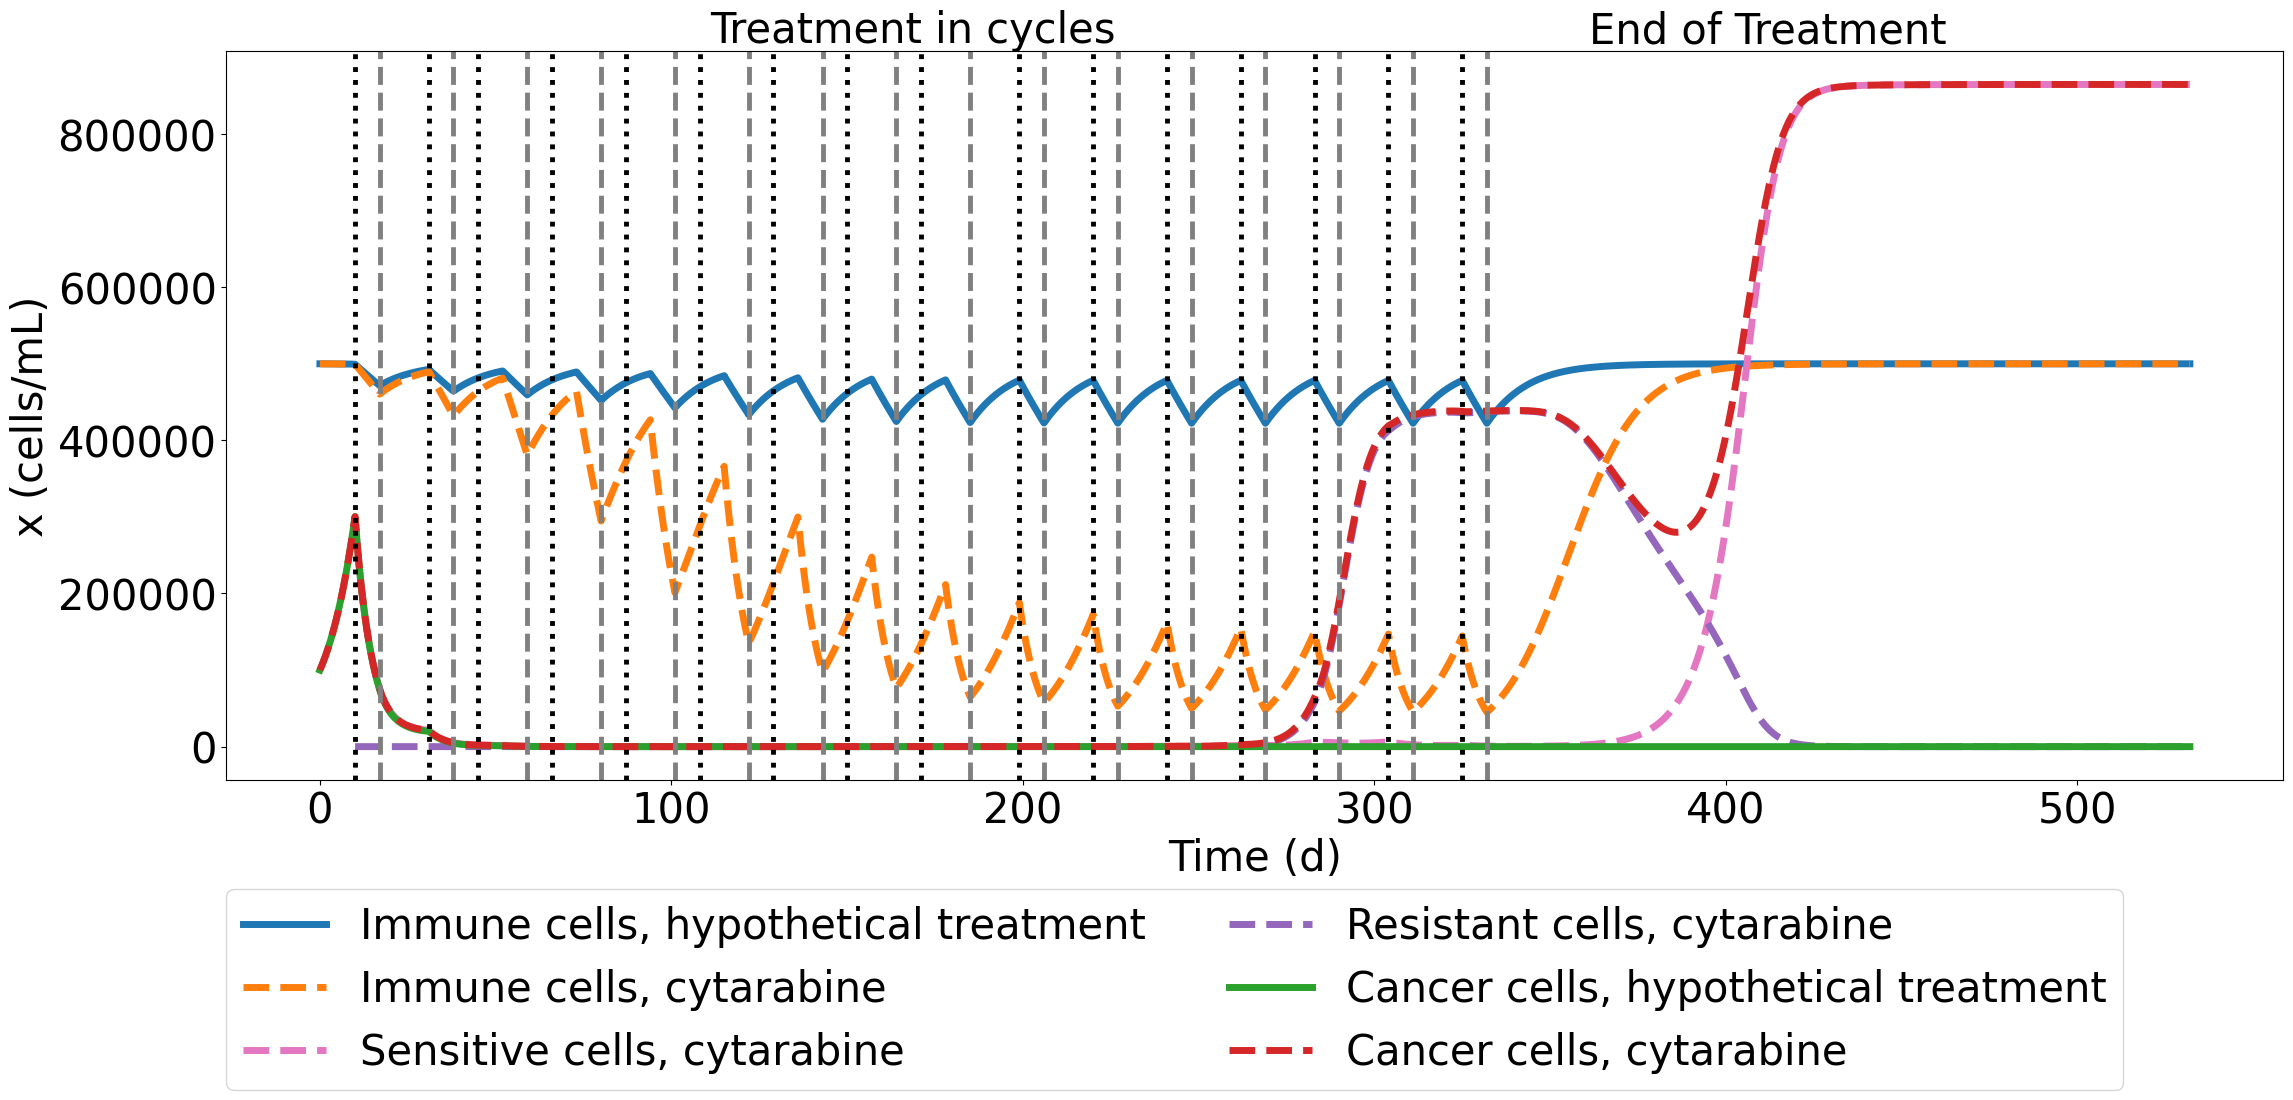

In [82]:
# Define treatment phases of cytarabine treatment with reduced toxicity
# Each tuple contains 
# ('name of drug', duration of drug, death rate of drug, maximal death rate of immune cells due to drug, halflife of drug applied before cell recovery, 
# first letter of drug, whether or not treatment is currently applied (True if no treatment, False if not))
treatment_phases_opt = [
    ('Drug', 7, mu_C, d_max_V, 0, 'C', False),
    ('Cell recovery', 14, mu_C, d, 10, 'C', True),

    ('Drug', 7, mu_C, d_max_V, 0, 'C', False),
    ('Cell recovery', 14, mu_C, d, 10, 'C', True),

    ('Drug', 7, mu_C, d_max_V, 0, 'C', False),
    ('Cell recovery', 14, mu_C, d, 10, 'C', True),

    ('Drug', 7, mu_C, d_max_V, 0, 'C', False),
    ('Cell recovery', 14, mu_C, d, 10, 'C', True),

    ('Drug', 7, mu_C, d_max_V, 0, 'C', False),
    ('Cell recovery', 14, mu_C, d, 10, 'C', True),

    ('Drug', 7, mu_C, d_max_V, 0, 'C', False),
    ('Cell recovery', 14, mu_C, d, 10, 'C', True),

    ('Drug', 7, mu_C, d_max_V, 0, 'C', False),
    ('Cell recovery', 14, mu_C, d, 10, 'C', True),

    ('Drug', 7, mu_C, d_max_V, 0, 'C', False),
    ('Cell recovery', 14, mu_C, d, 10, 'C', True),
    
    ('Drug', 7, mu_C, d_max_V, 0, 'C', False),
    ('Cell recovery', 14, mu_C, d, 10, 'C', True),

    ('Drug', 7, mu_C, d_max_V, 0, 'C', False),
    ('Cell recovery', 14, mu_C, d, 10, 'C', True),
    
    ('Drug', 7, mu_C, d_max_V, 0, 'C', False),
    ('Cell recovery', 14, mu_C, d, 10, 'C', True),

    ('Drug', 7, mu_C, d_max_V, 0, 'C', False),
    ('Cell recovery', 14, mu_C, d, 10, 'C', True),

    ('Drug', 7, mu_C, d_max_V, 0, 'C', False),
    ('Cell recovery', 14, mu_C, d, 10, 'C', True),

    ('Drug', 7, mu_C, d_max_V, 0, 'C', False),
    ('Cell recovery', 14, mu_C, d, 10, 'C', True),

    ('Drug', 7, mu_C, d_max_V, 0, 'C', False),
    ('Cell recovery', 14, mu_C, d, 10, 'C', True),

    ('Drug', 7, mu_C, d_max_V, 0, 'C', False),
    ('Cell recovery', 200, mu_C, d, 10, 'C', True),
]

# Define treatment phases of cytarabine treatment with normal toxicity
treatment_phases = [
    ('Drug', 7, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 14, mu_C, d, 10, 'C', True),

    ('Drug', 7, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 14, mu_C, d, 10, 'C', True),

    ('Drug', 7, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 14, mu_C, d, 10, 'C', True),

    ('Drug', 7, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 14, mu_C, d, 10, 'C', True),

    ('Drug', 7, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 14, mu_C, d, 10, 'C', True),

    ('Drug', 7, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 14, mu_C, d, 10, 'C', True),

    ('Drug', 7, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 14, mu_C, d, 10, 'C', True),

    ('Drug', 7, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 14, mu_C, d, 10, 'C', True),
    
    ('Drug', 7, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 14, mu_C, d, 10, 'C', True),

    ('Drug', 7, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 14, mu_C, d, 10, 'C', True),
    
    ('Drug', 7, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 14, mu_C, d, 10, 'C', True),

    ('Drug', 7, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 14, mu_C, d, 10, 'C', True),

    ('Drug', 7, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 14, mu_C, d, 10, 'C', True),

    ('Drug', 7, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 14, mu_C, d, 10, 'C', True),

    ('Drug', 7, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 14, mu_C, d, 10, 'C', True),

    ('Drug', 7, mu_C, d_max_C, 0, 'C', False),
    ('Cell recovery', 200, mu_C, d, 10, 'C', True),
]

# Collect list of populations for cytarabine treatment with reduced toxicity
t, t_after_treatment, density, immune, sensitive, resistant_A, resistant_V, resistant_Q, resistant_C, t_values = simulate_treatment(treatment_phases_opt, daysBeforeTreatment, parameters, gI)
# Collect list of populations for cytarabine treatment with normal toxicity
t_real, t_after_real, density_real, immune_real, sensitive, _, _, _, resistant_C_real, _ = simulate_treatment(treatment_phases, daysBeforeTreatment, parameters, gI)

# Plot results
plt.figure(figsize=(24, 12))
plt.plot(t, immune, label='Immune cells, hypothetical treatment', linewidth=5.0)
plt.plot(t_real, immune_real, label='Immune cells, cytarabine', linewidth=5.0, linestyle='dashed')
plt.plot(t_after_real, sensitive, label='Sensitive cells, cytarabine', linewidth=5.0, linestyle='dashed', color='tab:pink')
plt.plot(t_after_real, resistant_C_real, label='Resistant cells, cytarabine', linewidth=5.0, linestyle='dashed', color='tab:purple')
plt.plot(t, density, label='Cancer cells, hypothetical treatment', linewidth=5.0, color='tab:green')
plt.plot(t_real, density_real, label='Cancer cells, cytarabine', linewidth=5.0, linestyle='dashed', color='tab:red')

# Plotting headlines for each treatment phase
# Annotate treatment phases 
phase_labels = ['Treatment in cycles', 'End of Treatment']
phase_starts = [daysBeforeTreatment + 100,
                daysBeforeTreatment + 350]

# Set y-position slightly above max y-value
y_pos = max(max(density), max(density_real), max(immune)) * 1.05

# Add labels just after each phase starts
for label, xpos in zip(phase_labels, phase_starts):
    plt.text(xpos + 1, y_pos, label, ha='left', va='bottom', fontsize=30)

# Plotting vertical lines at the start and end of every treatment cycle
plt.axvline(daysBeforeTreatment, color = 'black', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 7, color = 'gray',  linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 21, color = 'black', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 28, color = 'gray', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 35, color = 'black', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 49, color = 'gray', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 56, color = 'black', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 70, color = 'gray', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 77, color = 'black', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 91, color = 'gray', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 98, color = 'black', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 112, color = 'gray', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 119, color = 'black', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 133, color = 'gray', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 140, color = 'black', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 154, color = 'gray', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 161, color = 'black', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 175, color = 'gray', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 189, color = 'black', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 196, color = 'gray', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 210, color = 'black', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 217, color = 'gray', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 231, color = 'black', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 238, color = 'gray', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 252, color = 'black', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 259, color = 'gray', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 273, color = 'black', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 280, color = 'gray', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 294, color = 'black', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 301, color = 'gray', linewidth=3.5, linestyle='dashed')
plt.axvline(daysBeforeTreatment + 315, color = 'black', linewidth=3.5, linestyle='dotted')
plt.axvline(daysBeforeTreatment + 322, color = 'gray', linewidth=3.5, linestyle='dashed')


plt.xlabel('Time (d)')
plt.ylabel('x (cells/mL)')
plt.rcParams.update({'font.size': 30})
plt.legend(loc='upper left', bbox_to_anchor=(0, -0.15), ncol=2, borderaxespad=0, fontsize=30)
plt.tight_layout()
plt.savefig('CytarabineVenetoclax_recovery.pdf', format='pdf', bbox_inches='tight')
plt.show()